## COL Phyloseq analysis

*see DR_phyloseq.ipnyb for information on conda and package installation*

starting with ASV table from steps: 1. Kraken2 (Pracken DB) 2. filtering out metazoan/human reads 3. Kraken2 (PlusPF DB), 4. Bracken filtering, 5. normalized by number of sequences

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken")

In [4]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,28213,Sphingomonas parapaucimobilis,S
2,562,Escherichia coli,S
3,2961995,Marinobacter metalliresistant,S
4,2721244,Streptomyces sp. RPA4-2,S
5,588596,Rhizophagus irregularis,S
6,2057741,Bradyrhizobium sp. SK17,S


In [5]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [6]:
head(taxa)

,otuid,species
,<int>,<chr>
1,28213,Sphingomonas parapaucimobilis
2,562,Escherichia coli
3,2961995,Marinobacter metalliresistant
4,2721244,Streptomyces sp. RPA4-2
5,588596,Rhizophagus irregularis
6,2057741,Bradyrhizobium sp. SK17


In [7]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
28213,Sphingomonas parapaucimobilis
562,Escherichia coli
2961995,Marinobacter metalliresistant
2721244,Streptomyces sp. RPA4-2
588596,Rhizophagus irregularis
2057741,Bradyrhizobium sp. SK17


In [8]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:12742, 1] "Sphingomonas parapaucimobilis" "Escherichia coli" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:12742] "28213" "562" "2961995" "2721244" ...
  ..$ : chr "species"


In [9]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,28213,27684.131,253.7459,695.4080,699.1606,21794.327,338.4881,37901.076,5597.277,64.01775,⋯,0.0000,0.000,0.000,0.000,176.5195,0.0000,7834.3179,0.000,0.000,554638.4
2,562,23955.896,6464.1774,36273.2723,85450.5398,21661.532,4122.8633,7458.667,7847.640,4316.62572,⋯,6516.7024,6373.220,6958.244,6016.967,16490.5733,3804.4696,5057.2861,26838.800,25797.107,730056.1
3,2961995,14767.514,0.0000,181.2675,0.0000,3527.037,0.0000,0.000,0.000,0.00000,⋯,0.0000,0.000,0.000,0.000,0.0000,0.0000,0.0000,25540.823,17564.768,171601.4
4,2721244,12619.151,2657.9886,425.1547,1496.6408,16493.148,533.3155,2693.407,1079.373,692.00144,⋯,933.7249,2594.469,2350.849,1566.837,359.1259,654.2718,832.4382,18199.581,18151.482,235618.7
5,588596,7912.585,3977.4674,1502.8723,2010.0868,7335.600,2578.0195,10870.316,1212.505,8127.20633,⋯,5462.8718,8296.824,8945.351,4903.946,3344.1315,4083.1410,7042.1590,7676.204,9497.442,398520.9
6,2057741,6517.802,583.6156,2099.4071,542.5778,5359.609,1538.9399,8895.150,2104.347,216.44098,⋯,50448.2654,7516.429,5705.356,40049.216,22055.1983,106517.0727,6800.4834,7690.161,9350.764,680888.3


In [10]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,28213,27684.131,253.7459,695.4080,699.1606,21794.327,338.4881,37901.076,5597.277,64.01775,⋯,0.0000,0.000,0.000,0.000,176.5195,0.0000,7834.3179,0.000,0.000,554638.4
2,562,23955.896,6464.1774,36273.2723,85450.5398,21661.532,4122.8633,7458.667,7847.640,4316.62572,⋯,6516.7024,6373.220,6958.244,6016.967,16490.5733,3804.4696,5057.2861,26838.800,25797.107,730056.1
3,2961995,14767.514,0.0000,181.2675,0.0000,3527.037,0.0000,0.000,0.000,0.00000,⋯,0.0000,0.000,0.000,0.000,0.0000,0.0000,0.0000,25540.823,17564.768,171601.4
4,2721244,12619.151,2657.9886,425.1547,1496.6408,16493.148,533.3155,2693.407,1079.373,692.00144,⋯,933.7249,2594.469,2350.849,1566.837,359.1259,654.2718,832.4382,18199.581,18151.482,235618.7
5,588596,7912.585,3977.4674,1502.8723,2010.0868,7335.600,2578.0195,10870.316,1212.505,8127.20633,⋯,5462.8718,8296.824,8945.351,4903.946,3344.1315,4083.1410,7042.1590,7676.204,9497.442,398520.9
6,2057741,6517.802,583.6156,2099.4071,542.5778,5359.609,1538.9399,8895.150,2104.347,216.44098,⋯,50448.2654,7516.429,5705.356,40049.216,22055.1983,106517.0727,6800.4834,7690.161,9350.764,680888.3


[1] 12743    58

In [67]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,28213,27684.131,253.7459,695.4080,699.1606,21794.327,338.4881,37901.076,5597.277,64.01775,⋯,0.0000,0.000,0.000,0.000,176.5195,0.0000,7834.3179,0.000,0.000,554638.4
2,562,23955.896,6464.1774,36273.2723,85450.5398,21661.532,4122.8633,7458.667,7847.640,4316.62572,⋯,6516.7024,6373.220,6958.244,6016.967,16490.5733,3804.4696,5057.2861,26838.800,25797.107,730056.1
3,2961995,14767.514,0.0000,181.2675,0.0000,3527.037,0.0000,0.000,0.000,0.00000,⋯,0.0000,0.000,0.000,0.000,0.0000,0.0000,0.0000,25540.823,17564.768,171601.4
4,2721244,12619.151,2657.9886,425.1547,1496.6408,16493.148,533.3155,2693.407,1079.373,692.00144,⋯,933.7249,2594.469,2350.849,1566.837,359.1259,654.2718,832.4382,18199.581,18151.482,235618.7
5,588596,7912.585,3977.4674,1502.8723,2010.0868,7335.600,2578.0195,10870.316,1212.505,8127.20633,⋯,5462.8718,8296.824,8945.351,4903.946,3344.1315,4083.1410,7042.1590,7676.204,9497.442,398520.9
6,2057741,6517.802,583.6156,2099.4071,542.5778,5359.609,1538.9399,8895.150,2104.347,216.44098,⋯,50448.2654,7516.429,5705.356,40049.216,22055.1983,106517.0727,6800.4834,7690.161,9350.764,680888.3


In [68]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,otu,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,28213,27684.131,253.7459,695.4080,699.1606,21794.327,338.4881,37901.076,5597.277,64.01775,⋯,87.38242,0.0000,0.000,0.000,0.000,176.5195,0.0000,7834.3179,0.000,0.000
2,562,23955.896,6464.1774,36273.2723,85450.5398,21661.532,4122.8633,7458.667,7847.640,4316.62572,⋯,6549.31208,6516.7024,6373.220,6958.244,6016.967,16490.5733,3804.4696,5057.2861,26838.800,25797.107
3,2961995,14767.514,0.0000,181.2675,0.0000,3527.037,0.0000,0.000,0.000,0.00000,⋯,0.00000,0.0000,0.000,0.000,0.000,0.0000,0.0000,0.0000,25540.823,17564.768
4,2721244,12619.151,2657.9886,425.1547,1496.6408,16493.148,533.3155,2693.407,1079.373,692.00144,⋯,1052.95811,933.7249,2594.469,2350.849,1566.837,359.1259,654.2718,832.4382,18199.581,18151.482
5,588596,7912.585,3977.4674,1502.8723,2010.0868,7335.600,2578.0195,10870.316,1212.505,8127.20633,⋯,2957.89478,5462.8718,8296.824,8945.351,4903.946,3344.1315,4083.1410,7042.1590,7676.204,9497.442
6,2057741,6517.802,583.6156,2099.4071,542.5778,5359.609,1538.9399,8895.150,2104.347,216.44098,⋯,5732.28649,50448.2654,7516.429,5705.356,40049.216,22055.1983,106517.0727,6800.4834,7690.161,9350.764


In [69]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
column_list <- readLines("COL_column_order.txt")
otu_table <- otu_table[, column_list]
head(otu_table)

,otu,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,28213,0.000,31642.275,0.000,0.000,0.000,27684.131,21794.327,37553.824,40029.802,⋯,7834.3179,0.0000,0.0000,338.4881,64.01775,142.6349,152.6280,9617.5706,29.46428,17499.437
2,562,31730.325,19373.373,41569.573,26838.800,25797.107,23955.896,21661.532,31075.125,18090.203,⋯,5057.2861,6516.7024,3804.4696,4122.8633,4316.62572,4365.2913,4266.0476,7695.2076,5096.14195,4793.805
3,2961995,27552.389,18332.376,4955.136,25540.823,17564.768,14767.514,3527.037,2987.558,19390.763,⋯,0.0000,0.0000,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.00000,0.000
4,2721244,26277.019,13519.451,20758.002,18199.581,18151.482,12619.151,16493.148,12708.436,15332.231,⋯,832.4382,933.7249,654.2718,533.3155,692.00144,1034.9323,205.3883,857.5811,1601.67829,1393.072
5,588596,9741.188,8057.593,8758.538,7676.204,9497.442,7912.585,7335.600,6388.167,7600.761,⋯,7042.1590,5462.8718,4083.1410,2578.0195,8127.20633,7247.8431,5528.5264,8800.2786,5506.28473,8661.627
6,2057741,9411.351,24429.648,14061.872,7690.161,9350.764,6517.802,5359.609,12538.688,16266.804,⋯,6800.4834,50448.2654,106517.0727,1538.9399,216.44098,408.0021,510.6444,2431.7317,172.07140,11210.128


In [70]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28213,0.000,31642.275,0.000,0.000,0.000,27684.131,21794.327,37553.824,40029.802,25174.825,⋯,7834.3179,0.0000,0.0000,338.4881,64.01775,142.6349,152.6280,9617.5706,29.46428,17499.437
562,31730.325,19373.373,41569.573,26838.800,25797.107,23955.896,21661.532,31075.125,18090.203,21420.685,⋯,5057.2861,6516.7024,3804.4696,4122.8633,4316.62572,4365.2913,4266.0476,7695.2076,5096.14195,4793.805
2961995,27552.389,18332.376,4955.136,25540.823,17564.768,14767.514,3527.037,2987.558,19390.763,13698.933,⋯,0.0000,0.0000,0.0000,0.0000,0.00000,0.0000,0.0000,0.0000,0.00000,0.000
2721244,26277.019,13519.451,20758.002,18199.581,18151.482,12619.151,16493.148,12708.436,15332.231,13316.158,⋯,832.4382,933.7249,654.2718,533.3155,692.00144,1034.9323,205.3883,857.5811,1601.67829,1393.072
588596,9741.188,8057.593,8758.538,7676.204,9497.442,7912.585,7335.600,6388.167,7600.761,8192.860,⋯,7042.1590,5462.8718,4083.1410,2578.0195,8127.20633,7247.8431,5528.5264,8800.2786,5506.28473,8661.627
2057741,9411.351,24429.648,14061.872,7690.161,9350.764,6517.802,5359.609,12538.688,16266.804,5999.264,⋯,6800.4834,50448.2654,106517.0727,1538.9399,216.44098,408.0021,510.6444,2431.7317,172.07140,11210.128


In [71]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,45477.000,147935.00000,37335.00,71650.0000,54541.000,151278.000,188260.00000,176733.0000,153011.00,135850.0000,⋯,446880.0000,258106.000,495207.00000,508142.0000,328034.00000,301469.0000,530702.0000,347489.000,848485.00000,244065.000
562,31730.325,19373.37344,41569.57,26838.7997,25797.107,23955.896,21661.53192,31075.1246,18090.20,21420.6846,⋯,5057.2861,6516.702,3804.46965,4122.8633,4316.62572,4365.2913,4266.0476,7695.208,5096.14195,4793.805
2057741,9411.351,24429.64816,14061.87,7690.1605,9350.764,6517.802,5359.60905,12538.6883,16266.80,5999.2639,⋯,6800.4834,50448.265,106517.07266,1538.9399,216.44098,408.0021,510.6444,2431.732,172.07140,11210.128
28213,0.000,31642.27532,0.00,0.0000,0.000,27684.131,21794.32699,37553.8241,40029.80,25174.8252,⋯,7834.3179,0.000,0.00000,338.4881,64.01775,142.6349,152.6280,9617.571,29.46428,17499.437
2653203,0.000,162.23341,0.00,0.0000,0.000,2359.894,3410.17741,2172.7691,1849.54,1987.4862,⋯,138.7397,0.000,26.25165,56480.2752,10715.35268,19866.0559,3640.4611,3154.057,865.07127,2962.326
1173583,0.000,74.35698,0.00,139.5673,0.000,0.000,69.05344,96.1903,0.00,110.4159,⋯,75586.2871,7586.031,6389.24732,4949.4039,76973.72833,36809.7549,5439.9644,64934.430,6128.57033,31122.857


In [72]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,31730.325,19373.37344,41569.573,26838.7997,25797.107,23955.896,21661.53192,31075.1246,18090.203,21420.6846,⋯,5057.2861,6516.702,3804.46965,4122.8633,4316.62572,4365.2913,4266.0476,7695.208,5096.14195,4793.805
2057741,9411.351,24429.64816,14061.872,7690.1605,9350.764,6517.802,5359.60905,12538.6883,16266.804,5999.2639,⋯,6800.4834,50448.265,106517.07266,1538.9399,216.44098,408.0021,510.6444,2431.732,172.07140,11210.128
28213,0.000,31642.27532,0.000,0.0000,0.000,27684.131,21794.32699,37553.8241,40029.802,25174.8252,⋯,7834.3179,0.000,0.00000,338.4881,64.01775,142.6349,152.6280,9617.571,29.46428,17499.437
2653203,0.000,162.23341,0.000,0.0000,0.000,2359.894,3410.17741,2172.7691,1849.540,1987.4862,⋯,138.7397,0.000,26.25165,56480.2752,10715.35268,19866.0559,3640.4611,3154.057,865.07127,2962.326
1173583,0.000,74.35698,0.000,139.5673,0.000,0.000,69.05344,96.1903,0.000,110.4159,⋯,75586.2871,7586.031,6389.24732,4949.4039,76973.72833,36809.7549,5439.9644,64934.430,6128.57033,31122.857
588596,9741.188,8057.59286,8758.538,7676.2038,9497.442,7912.585,7335.59970,6388.1675,7600.761,8192.8598,⋯,7042.1590,5462.872,4083.14099,2578.0195,8127.20633,7247.8431,5528.5264,8800.279,5506.28473,8661.627


[1] 12742    56

In [73]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
562,31730.325,19373.37344,41569.573,26838.7997,25797.107,23955.896,21661.53192,31075.1246,18090.203,21420.6846,⋯,5057.2861,6516.702,3804.46965,4122.8633,4316.62572,4365.2913,4266.0476,7695.208,5096.14195,4793.805
2057741,9411.351,24429.64816,14061.872,7690.1605,9350.764,6517.802,5359.60905,12538.6883,16266.804,5999.2639,⋯,6800.4834,50448.265,106517.07266,1538.9399,216.44098,408.0021,510.6444,2431.732,172.07140,11210.128
28213,0.000,31642.27532,0.000,0.0000,0.000,27684.131,21794.32699,37553.8241,40029.802,25174.8252,⋯,7834.3179,0.000,0.00000,338.4881,64.01775,142.6349,152.6280,9617.571,29.46428,17499.437
2653203,0.000,162.23341,0.000,0.0000,0.000,2359.894,3410.17741,2172.7691,1849.540,1987.4862,⋯,138.7397,0.000,26.25165,56480.2752,10715.35268,19866.0559,3640.4611,3154.057,865.07127,2962.326
1173583,0.000,74.35698,0.000,139.5673,0.000,0.000,69.05344,96.1903,0.000,110.4159,⋯,75586.2871,7586.031,6389.24732,4949.4039,76973.72833,36809.7549,5439.9644,64934.430,6128.57033,31122.857
588596,9741.188,8057.59286,8758.538,7676.2038,9497.442,7912.585,7335.59970,6388.1675,7600.761,8192.8598,⋯,7042.1590,5462.872,4083.14099,2578.0195,8127.20633,7247.8431,5528.5264,8800.279,5506.28473,8661.627


In [100]:
write.csv(otus, file= "otu_table_ready.csv")

metadata!

In [74]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
head(metadata)

,SampleID,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
2,032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
3,032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
4,032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
5,032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
6,012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [75]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
metadata

,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,
012025_COL_SAN_T5_572_OFAV_S5,ELARBOL,1/17/25,Jan_2025,28,OFAV,Healthy,Healthy,Y-2025,Y-2026,Healthy_Treatment
012025_COL_SAN_T5_580_OFAV_S13,ELARBOL,1/17/25,Jan_2025,23,OFAV,Healthy,Healthy,,Y-2026,Healthy_Control
012025_COL_SAN_T5_584_OFAV_S17,ELARBOL,1/17/25,Jan_2025,22,OFAV,Healthy,Healthy,,Y-2026,Healthy_Control


In [76]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [77]:
TAX=tax_table(taxonomy)

In [78]:
SAMP=sample_data(metadata)

In [79]:
# Create phyloseq object
COL_all = phyloseq(OTU, SAMP, TAX)
COL_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12742 taxa and 56 samples ]
sample_data() Sample Data:       [ 56 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 12742 taxa by 1 taxonomic ranks ]

In [80]:
COL_all.ord <- ordinate(COL_all, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.08444369 
Run 1 stress 0.09424666 
Run 2 stress 0.09607475 
Run 3 stress 0.08444272 
... New best solution
... Procrustes: rmse 0.0003622946  max resid 0.001979904 
... Similar to previous best
Run 4 stress 0.09586321 
Run 5 stress 0.09685342 
Run 6 stress 0.09423876 
Run 7 stress 0.09279466 
Run 8 stress 0.0927586 
Run 9 stress 0.1015596 
Run 10 stress 0.09279458 
Run 11 stress 0.09734593 
Run 12 stress 0.09659144 
Run 13 stress 0.09582273 
Run 14 stress 0.08444309 
... Procrustes: rmse 0.0002049194  max resid 0.001153288 
... Similar to previous best
Run 15 stress 0.0940008 
Run 16 stress 0.08444319 
... Procrustes: rmse 0.0002335705  max resid 0.001306587 
... Similar to previous best
Run 17 stress 0.09607465 
Run 18 stress 0.09607514 
Run 19 stress 0.09659143 
Run 20 stress 0.09657123 
*** Best solution repeated 3 times


In [24]:
options(repr.plot.width=15, repr.plot.height=15)

In [25]:
library(RColorBrewer)
library(ggrepel)

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


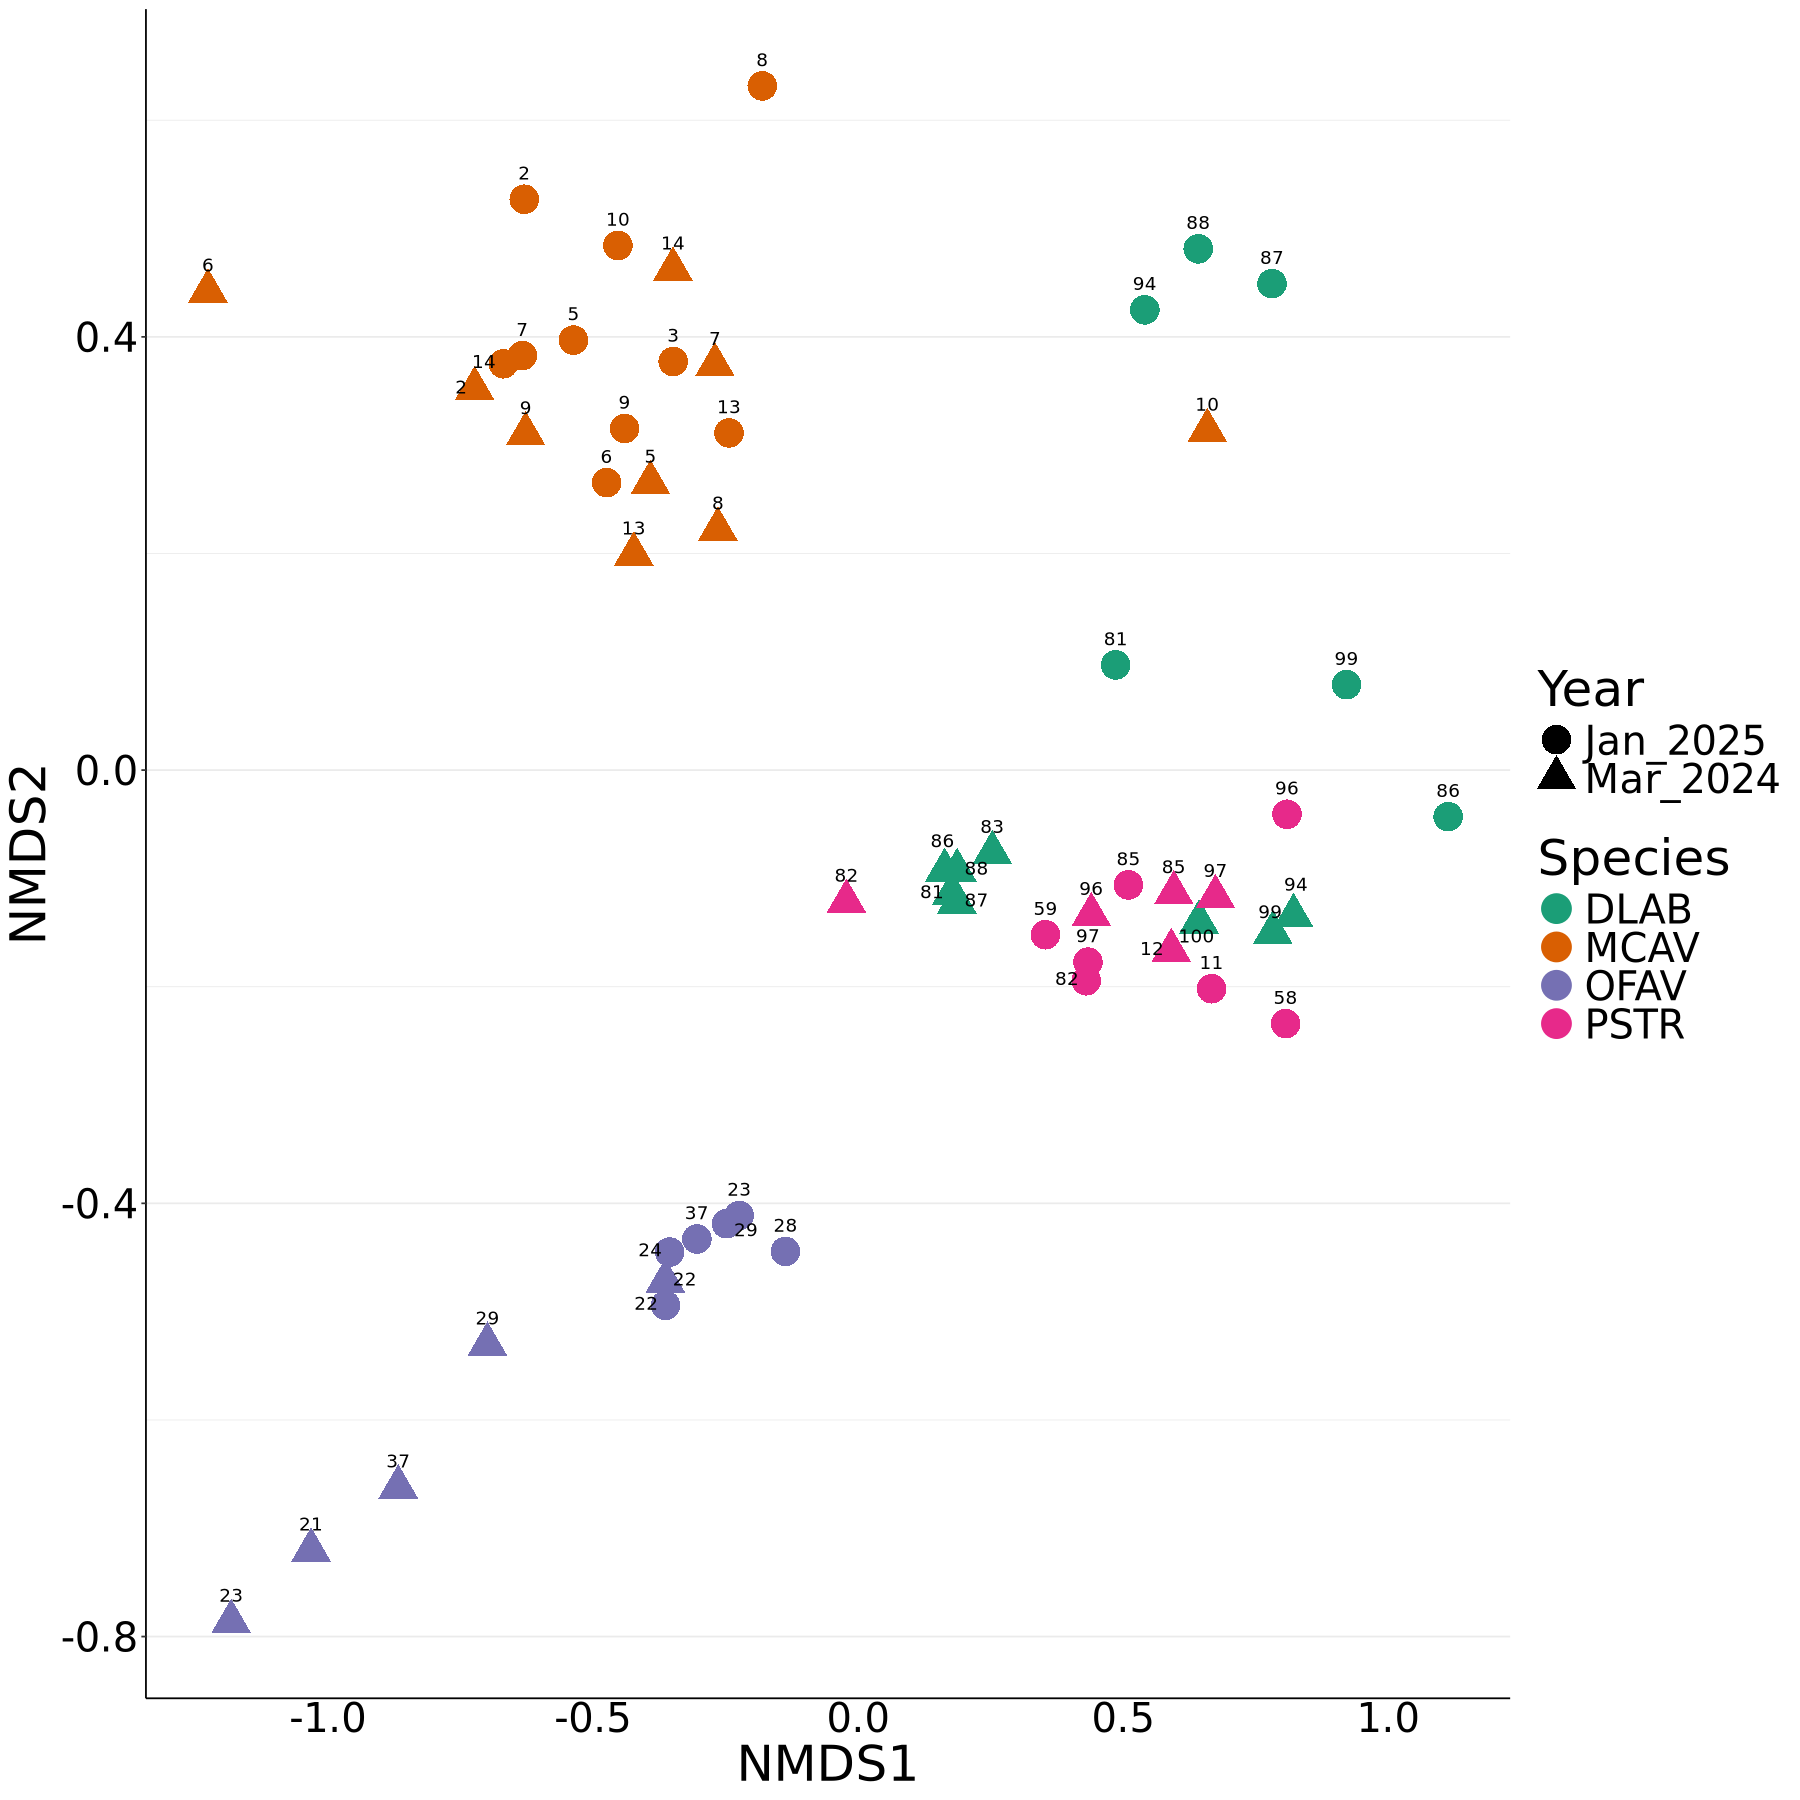

In [81]:
# visualize ordination plot
COL_all_plot <- plot_ordination(COL_all, COL_all.ord, type="Samples", color="Species", shape="Year")+
geom_point(size=8) + scale_color_brewer(palette = "Dark2")+
#geom_label(aes(label = SAMP$Tag_num), vjust = -1, color = "black") +
geom_text_repel(aes(label = SAMP$Tag_num), vjust = -1.5, color = "black", segment.color= "NA") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
COL_all_plot

In [82]:
ggsave(filename = "taxonomy_species_nmds.png", plot = COL_all_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


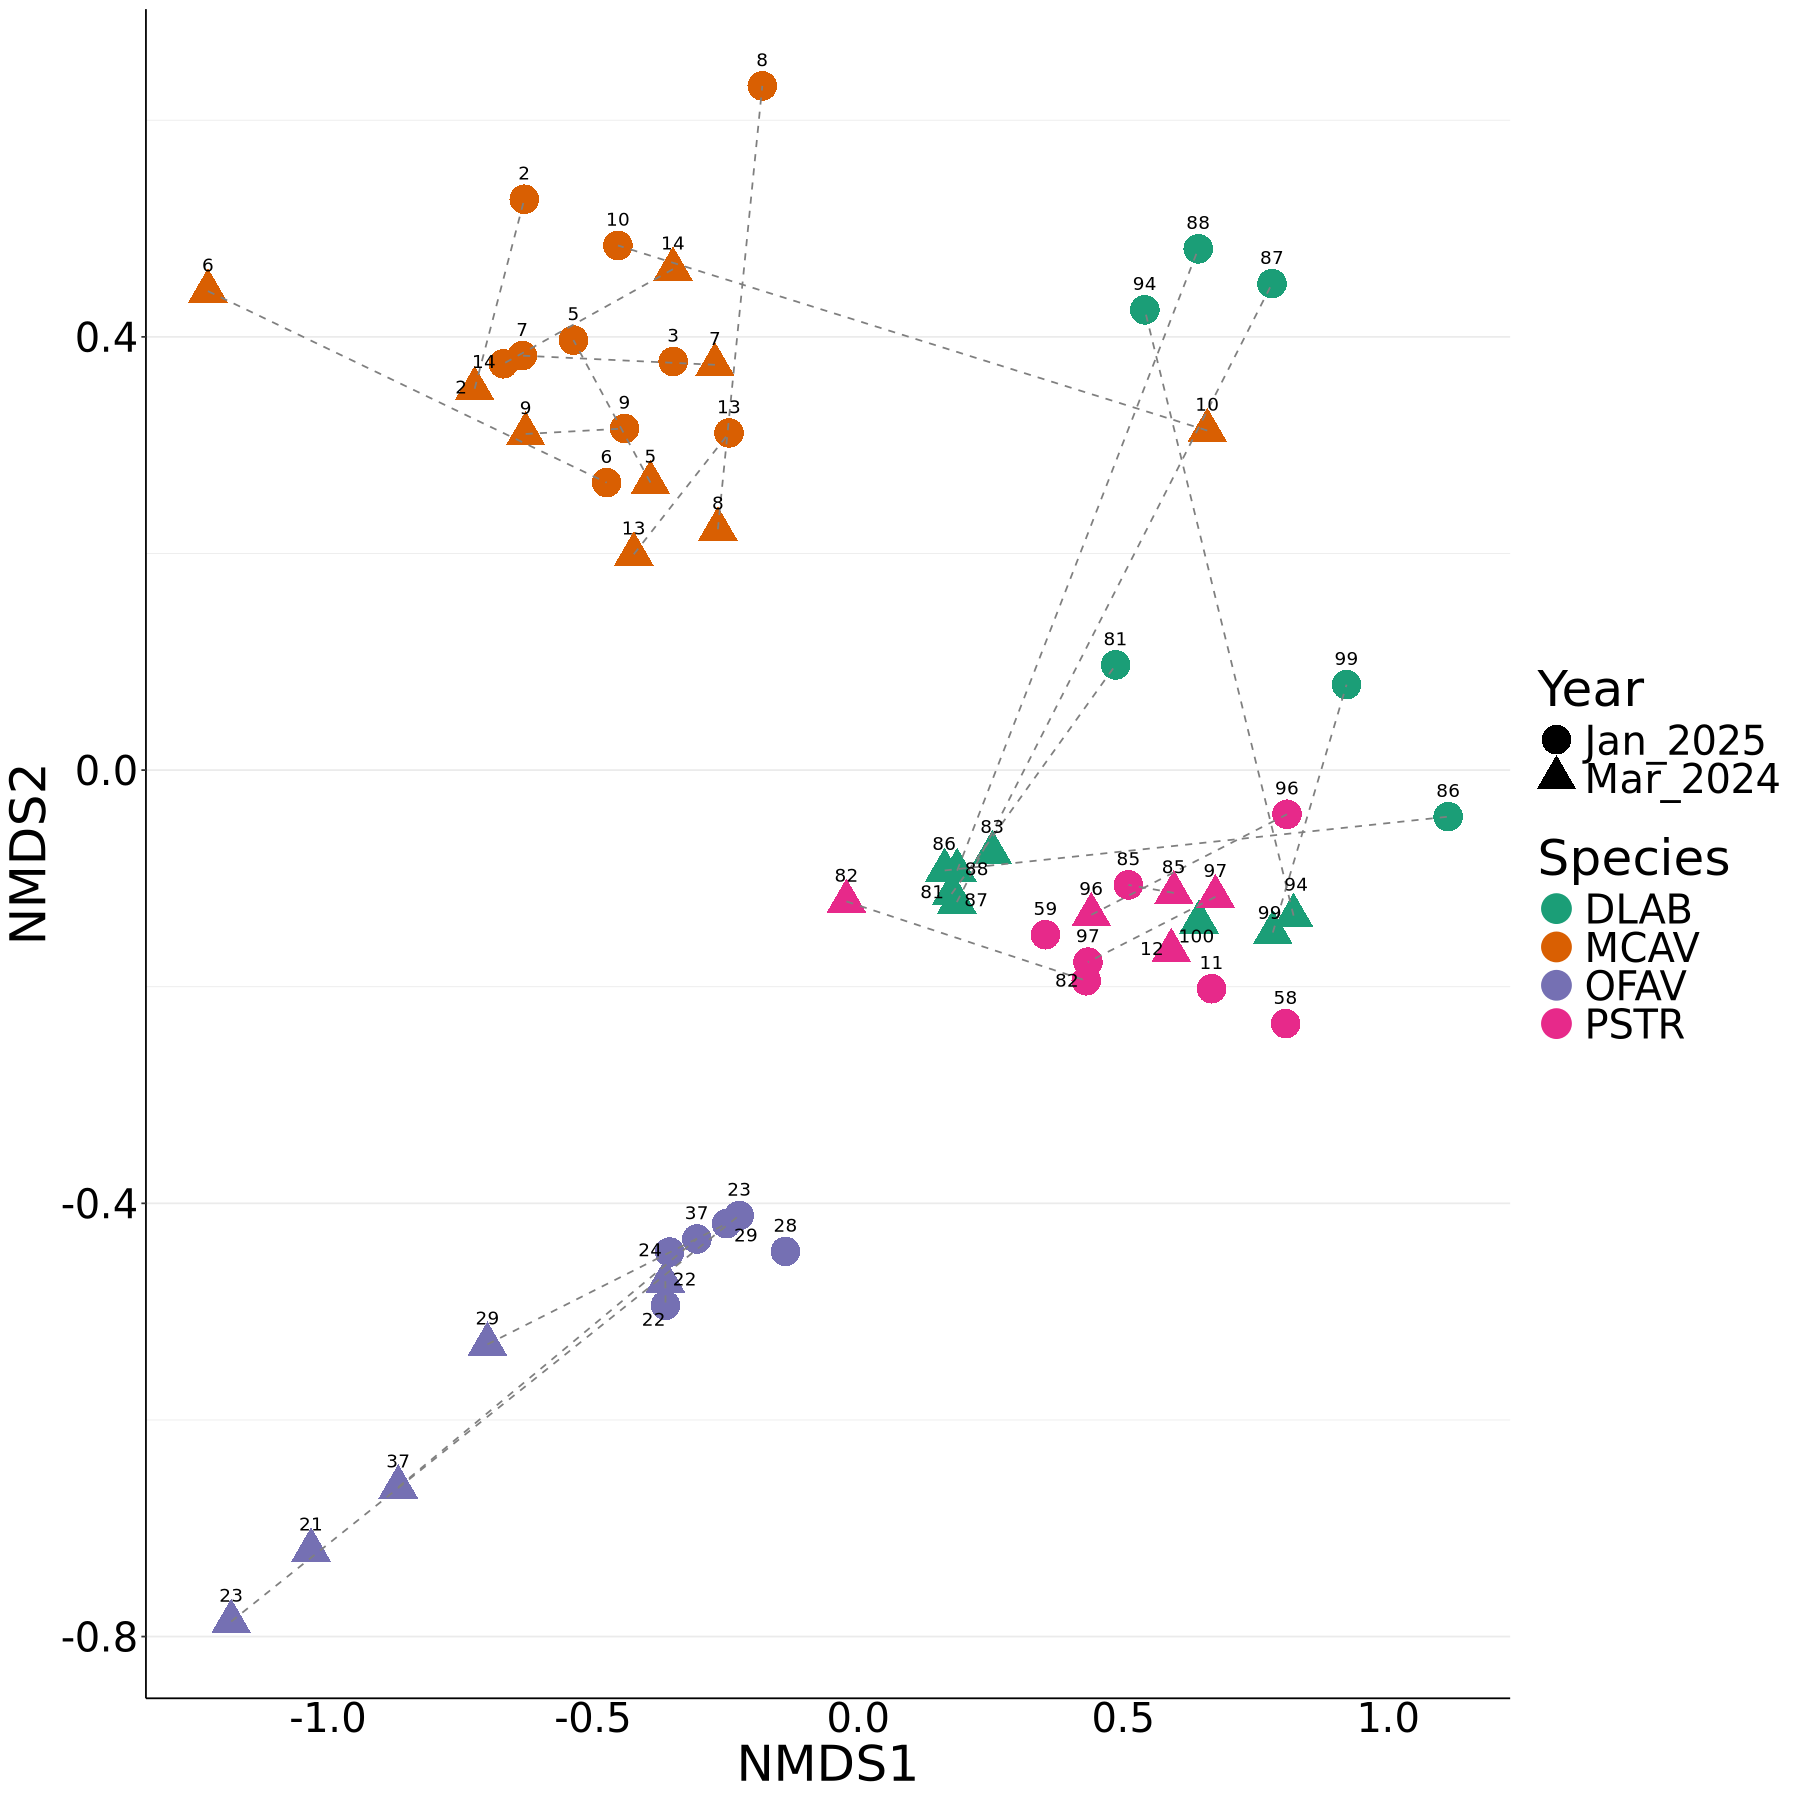

In [83]:
# visualize ordination plot with paths between years
COL_all_plot_2 <- plot_ordination(COL_all, COL_all.ord, type="Samples", color="Species", shape="Year")+
geom_point(size=8) + scale_color_brewer(palette = "Dark2")+
#geom_label(aes(label = SAMP$Tag), vjust = -1, color = "black") +
geom_path(aes(group = SAMP$Tag), color = "gray50", linetype = "dashed") +
geom_text_repel(aes(label = SAMP$Tag), vjust = -1.5, color = "black", segment.color= "NA") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
COL_all_plot_2

In [84]:
ggsave(filename = "taxonomy_nmds_w_paths.png", plot = COL_all_plot_2, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


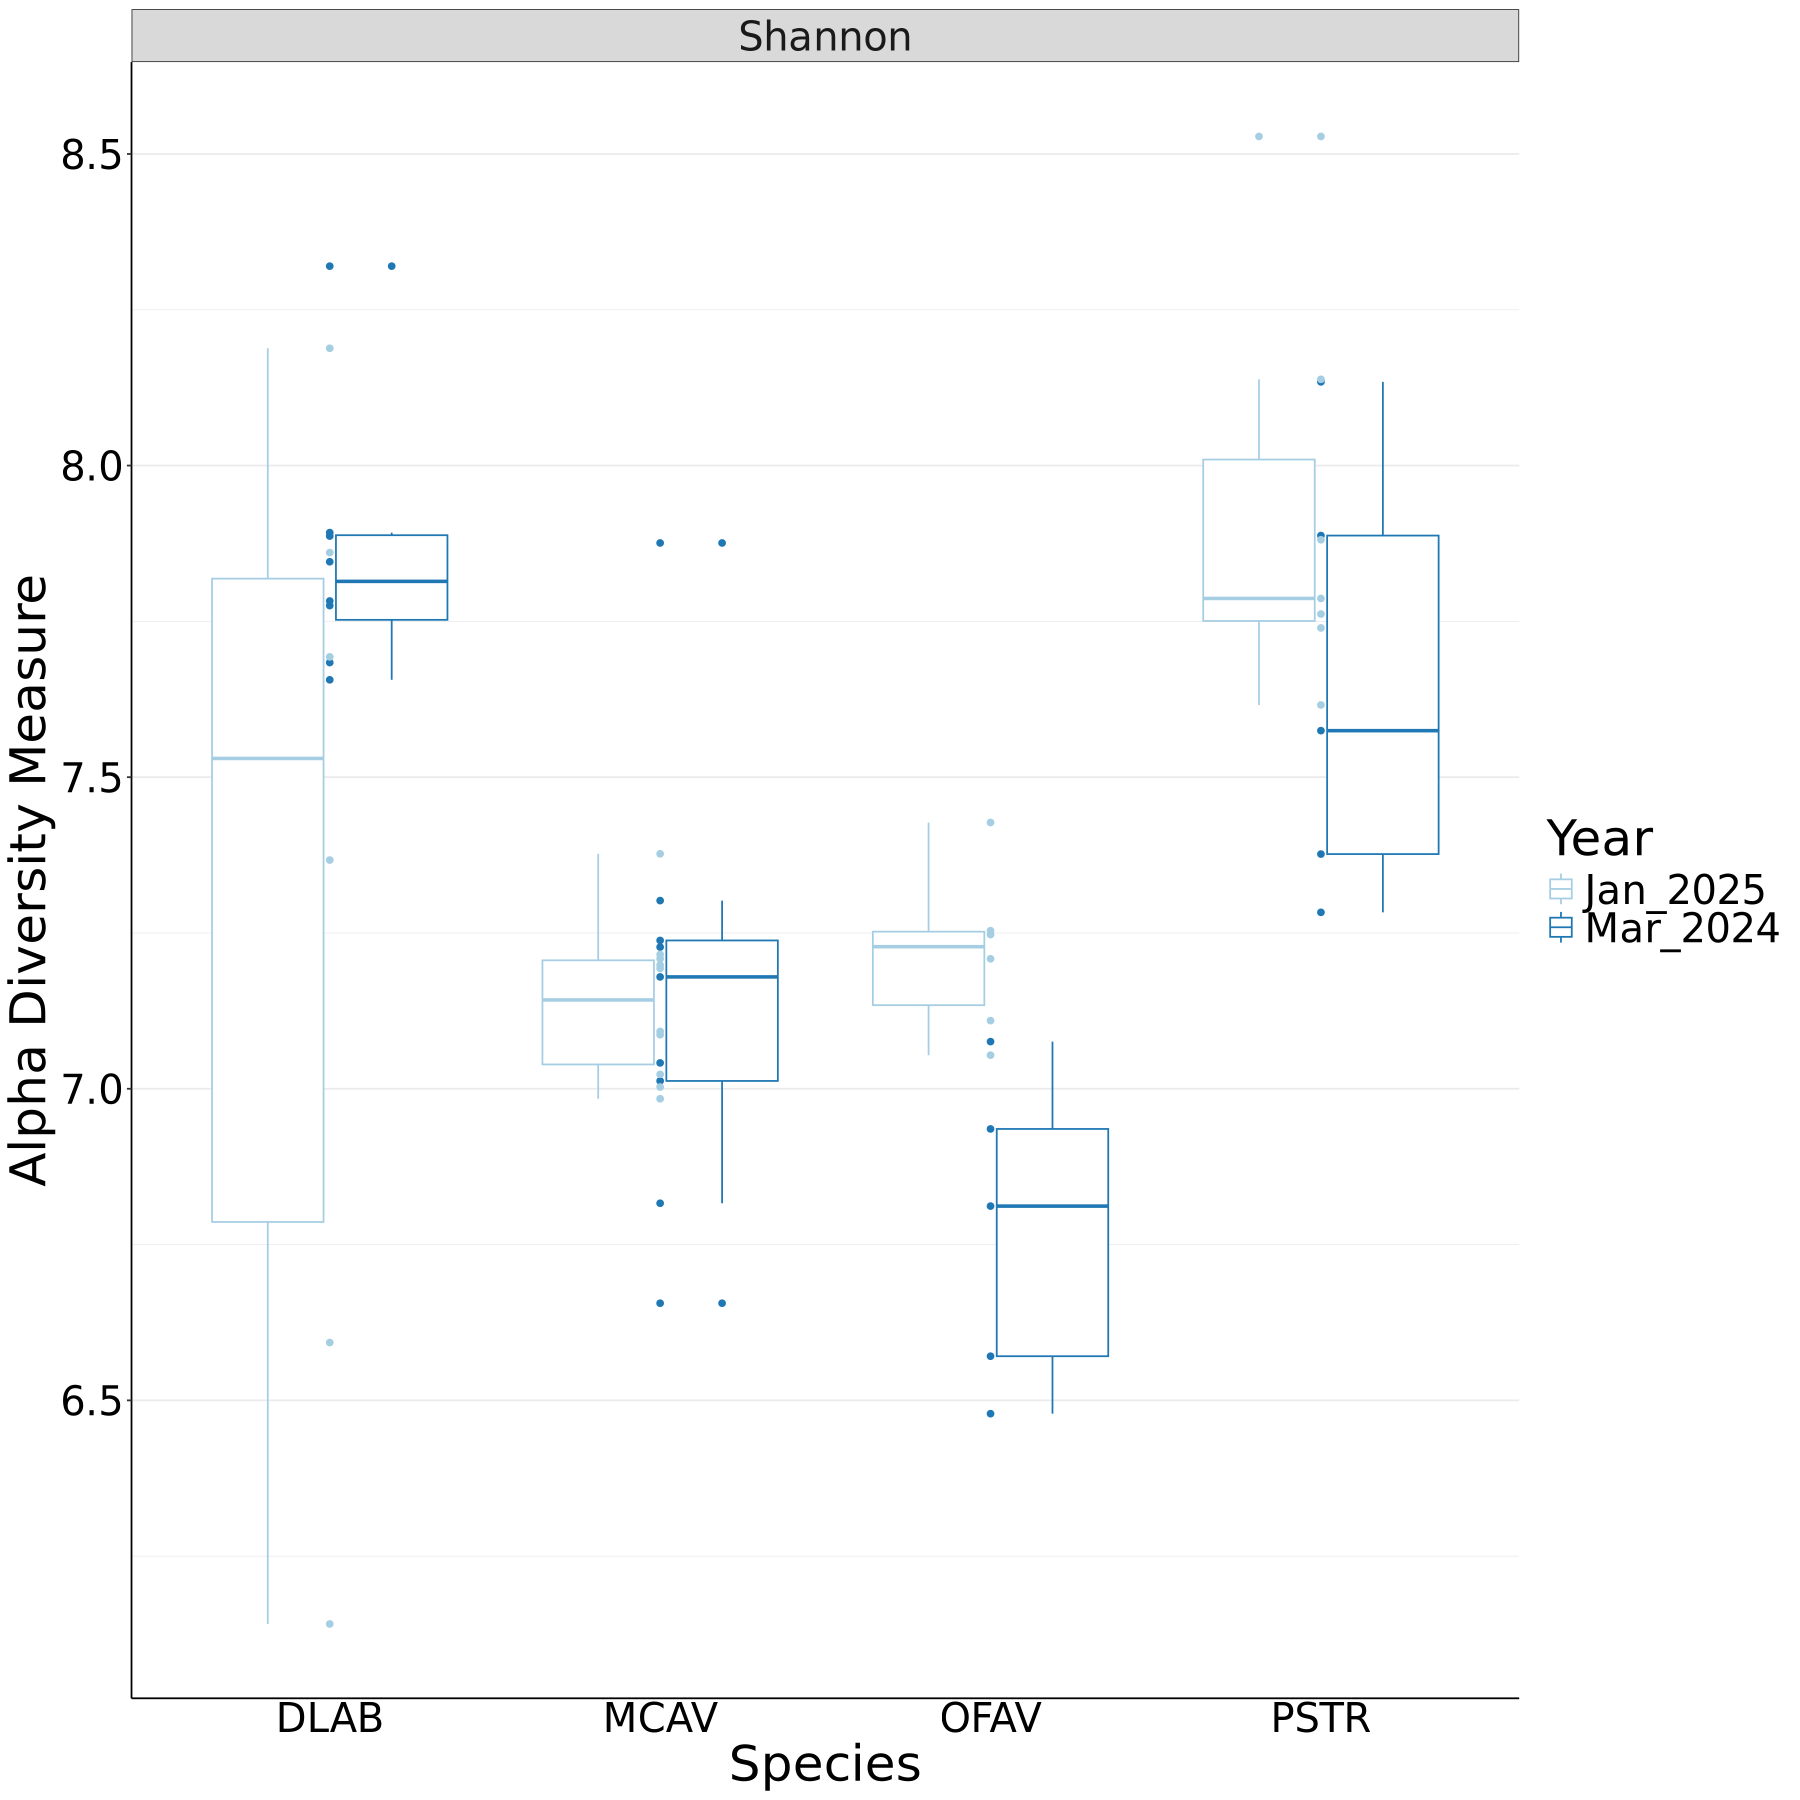

In [85]:
rich_plot <- plot_richness(COL_all, x="Species", color="Year", measures=c("Shannon")) +
geom_boxplot() +
scale_color_brewer(palette = "Paired") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
rich_plot

In [65]:
#re-ordering data to have Mar-2024 first
#year_order <- c("Mar_2024", "Jan_2025")
#SAMP$Year <- as.character(SAMP$Year)
#SAMP$Year <- factor(SAMP$Year, levels= c("Mar-24", "Jan-25"))

In [66]:
#rich_plot$COL_all$Year <- as.character(rich_plot$COL_all$Year)
#rich_plot$COL_all$Year <- factor(rich_plot$COL_all$Year, levels=year_order)
#print(rich_plot)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


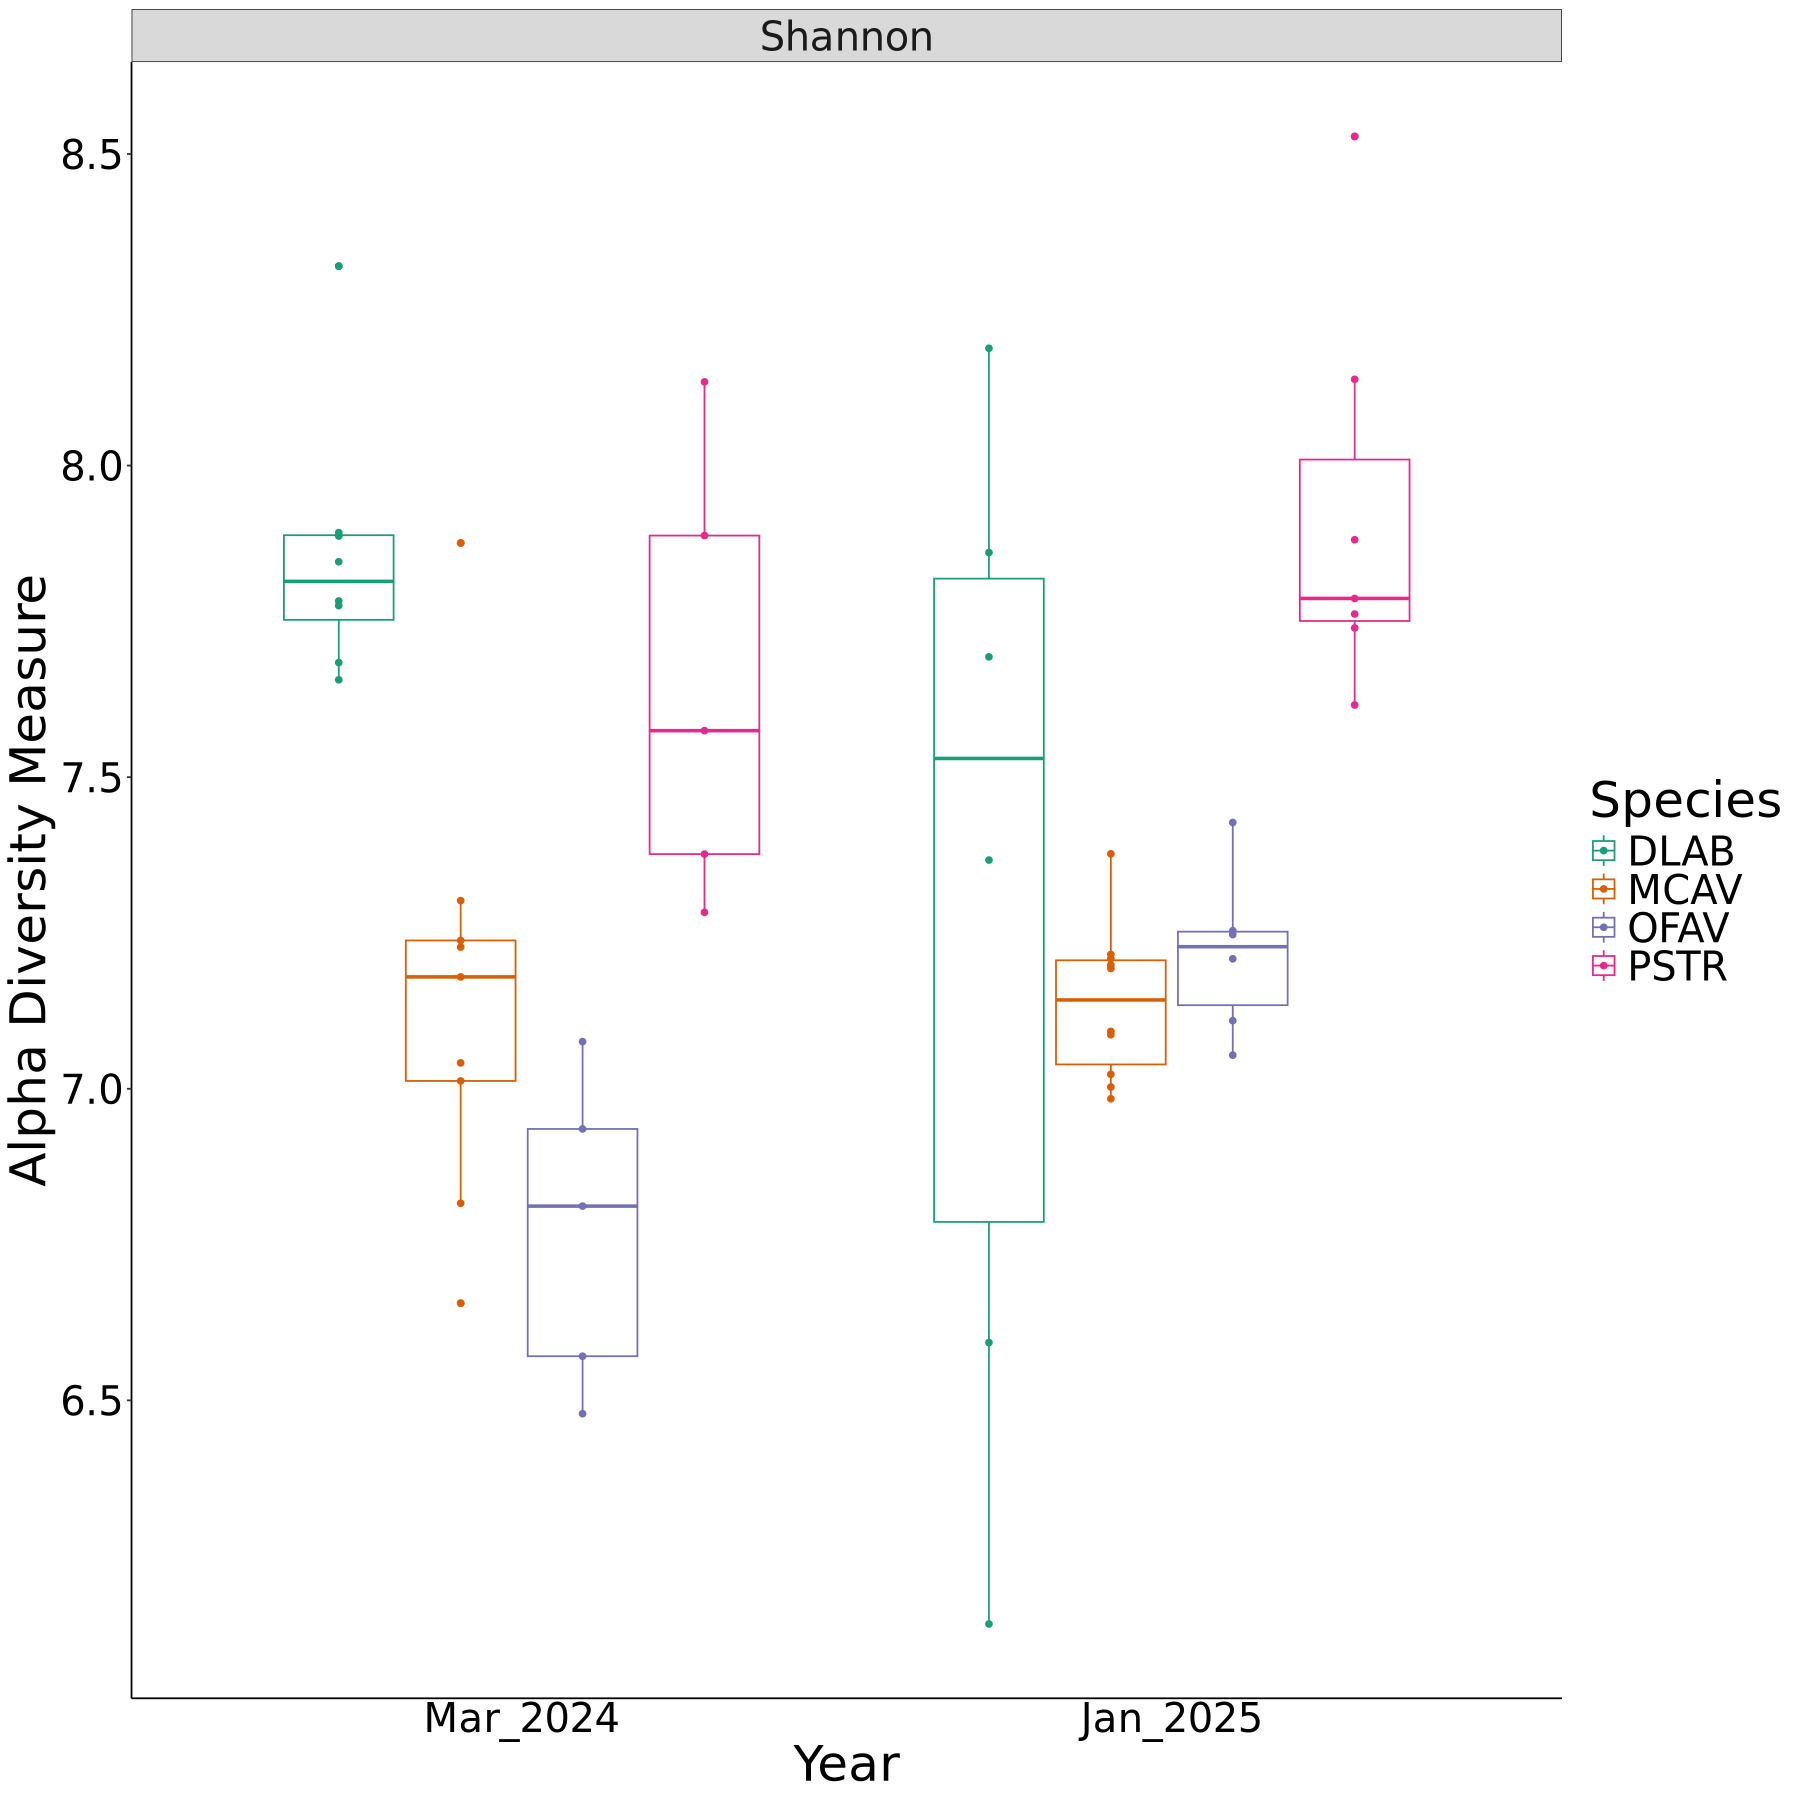

In [86]:
rich_plot_2 <- plot_richness(COL_all, x="Year", color="Species", measures=c("Shannon")) + 
geom_boxplot() +
scale_color_brewer(palette = "Dark2") +
scale_x_discrete(limits = c("Mar_2024", "Jan_2025")) +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
rich_plot_2$layers <- rich_plot_2$layers[-1]
rich_plot_2 + geom_point(position = position_dodge(width = 0.75))

In [87]:
ggsave(filename = "shannon_richness.png", plot = rich_plot_2, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [99]:
#install.packages('devtools')
#library(devtools)
#need to do: conda install conda-forge::r-devtools

In [88]:
#calculating permanova - create distance matrix
bray_dist <- phyloseq::distance(COL_all, method = "bray")

In [89]:
metadata <- as(phyloseq::sample_data(COL_all), "data.frame")

In [90]:
permanova <- vegan::adonis2(bray_dist ~ Species + Year, data = metadata, permutations = 999)
print(permanova)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Species + Year, data = metadata, permutations = 999)
         Df SumOfSqs     R2      F Pr(>F)    
Model     4   4.5154 0.4481 10.352  0.001 ***
Residual 51   5.5615 0.5519                  
Total    55  10.0769 1.0000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [93]:
permanova_b <- vegan::adonis2(bray_dist ~ Species* Year, data = metadata, permutations = 999)
print(permanova_b)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Species * Year, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)    
Model     7   5.2668 0.52266 7.5082  0.001 ***
Residual 48   4.8101 0.47734                  
Total    55  10.0769 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [92]:
permanova_yr <- vegan::adonis2(bray_dist ~ Year, data = metadata, permutations = 999)
print(permanova_yr)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Year, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)  
Model     1    0.459 0.04555 2.5768  0.013 *
Residual 54    9.618 0.95445                
Total    55   10.077 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [41]:
permanova_sp <- vegan::adonis2(bray_dist ~ Species, data = metadata, permutations = 999)
print(permanova_sp)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Species, data = metadata, permutations = 999)
         Df SumOfSqs      R2     F Pr(>F)    
Model     3   4.0806 0.47432 15.64  0.001 ***
Residual 52   4.5225 0.52568                 
Total    55   8.6031 1.00000                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [96]:
#once devtools is installed....
pairwise.adonis(bray_dist, phyloseq::sample_data(COL_all)$Year)

ERROR: Error in UseMethod("TukeyHSD"): no applicable method for 'TukeyHSD' applied to an object of class "c('anova.cca', 'anova', 'data.frame')"


In [ ]:
#groups <- metadata[["Jan_2025 Mar_2024"]]
#mod <- betadisper(bray_dist, groups)
#permutest(mod)
##if the dispersion is different between groups, then examine
#plot(mod)
#boxplot(mod)
#mod.HSD <- TukeyHSD(mod)
#mod.HSD
#plot(mod.HSD)

### OFAV 

looking for most abundant taxa across both time points

In [104]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_ofav = read.csv('ofav_otu_table_ready.csv')
head(otu_ofav)

,X,X032024_COL_SAN_T5_139_OFAV_S17,X032024_COL_SAN_T5_140_OFAV_S18c,X032024_COL_SAN_T5_141_OFAV_S19,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_580_OFAV_S13,X012025_COL_SAN_T5_584_OFAV_S17,X012025_COL_SAN_T5_585_OFAV_S18,X012025_COL_SAN_T5_596_OFAV_S29
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,31730.325,19373.37344,41569.573,26838.7997,25797.107,23955.896,21661.53192,31075.1246,18090.203,21420.6846,22519.897
2,2057741,9411.351,24429.64816,14061.872,7690.1605,9350.764,6517.802,5359.60905,12538.6883,16266.804,5999.2639,20906.073
3,28213,0.000,31642.27532,0.000,0.0000,0.000,27684.131,21794.32699,37553.8241,40029.802,25174.8252,37032.037
4,2653203,0.000,162.23341,0.000,0.0000,0.000,2359.894,3410.17741,2172.7691,1849.540,1987.4862,2141.538
5,1173583,0.000,74.35698,0.000,139.5673,0.000,0.000,69.05344,96.1903,0.000,110.4159,0.000
6,588596,9741.188,8057.59286,8758.538,7676.2038,9497.442,7912.585,7335.59970,6388.1675,7600.761,8192.8598,6725.288


In [105]:
# rename first col as otu
names(otu_ofav)[1] <- "otu"

#remove X's from headers
names(otu_ofav) <- sub("^X", "", names(otu_ofav))
otu_table_ofav=as.data.frame(otu_ofav)

# make the index the otus
row.names(otu_table_ofav) <- otu_table_ofav$otu
otu_table_ofav$otu <- NULL
head(otu_table_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,31730.325,19373.37344,41569.573,26838.7997,25797.107,23955.896,21661.53192,31075.1246,18090.203,21420.6846,22519.897
2057741,9411.351,24429.64816,14061.872,7690.1605,9350.764,6517.802,5359.60905,12538.6883,16266.804,5999.2639,20906.073
28213,0.000,31642.27532,0.000,0.0000,0.000,27684.131,21794.32699,37553.8241,40029.802,25174.8252,37032.037
2653203,0.000,162.23341,0.000,0.0000,0.000,2359.894,3410.17741,2172.7691,1849.540,1987.4862,2141.538
1173583,0.000,74.35698,0.000,139.5673,0.000,0.000,69.05344,96.1903,0.000,110.4159,0.000
588596,9741.188,8057.59286,8758.538,7676.2038,9497.442,7912.585,7335.59970,6388.1675,7600.761,8192.8598,6725.288


In [106]:
# sort by most abundant OTUs
otus_sorted_ofav <- otu_table_ofav[order(rowSums(otu_table_ofav), decreasing = TRUE), ]
head(otus_sorted_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,31730.325,19373.373,41569.573,26838.800,25797.107,23955.896,21661.532,31075.125,18090.20,21420.685,22519.897
28213,0.000,31642.275,0.000,0.000,0.000,27684.131,21794.327,37553.824,40029.80,25174.825,37032.037
2721244,26277.019,13519.451,20758.002,18199.581,18151.482,12619.151,16493.148,12708.436,15332.23,13316.158,14524.413
2961995,27552.389,18332.376,4955.136,25540.823,17564.768,14767.514,3527.037,2987.558,19390.76,13698.933,23102.837
2057741,9411.351,24429.648,14061.872,7690.161,9350.764,6517.802,5359.609,12538.688,16266.80,5999.264,20906.073
573,10708.710,9875.959,9856.703,13635.729,9075.741,6445.088,4084.776,3626.940,13881.35,9753.404,6694.607


In [107]:
# Convert to matrix
otus_ofav=as.matrix(otus_sorted_ofav)
head(otus_ofav)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
562,31730.325,19373.373,41569.573,26838.800,25797.107,23955.896,21661.532,31075.125,18090.20,21420.685,22519.897
28213,0.000,31642.275,0.000,0.000,0.000,27684.131,21794.327,37553.824,40029.80,25174.825,37032.037
2721244,26277.019,13519.451,20758.002,18199.581,18151.482,12619.151,16493.148,12708.436,15332.23,13316.158,14524.413
2961995,27552.389,18332.376,4955.136,25540.823,17564.768,14767.514,3527.037,2987.558,19390.76,13698.933,23102.837
2057741,9411.351,24429.648,14061.872,7690.161,9350.764,6517.802,5359.609,12538.688,16266.80,5999.264,20906.073
573,10708.710,9875.959,9856.703,13635.729,9075.741,6445.088,4084.776,3626.940,13881.35,9753.404,6694.607


In [108]:
#filter metadata for ofavs only
metadata_ofav <- metadata[metadata$Species=="OFAV",]
head(metadata_ofav)
dim(metadata_ofav)

,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


[1] 11 10

In [109]:
# classify phyloseq objects 
OTU_O=otu_table((otus_ofav), taxa_are_rows = TRUE)
TAX_O=tax_table(taxonomy)
SAMP_O=sample_data(metadata_ofav)

In [110]:
# Create phyloseq object
COL_ofav = phyloseq(OTU_O, SAMP_O, TAX_O)
COL_ofav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12742 taxa and 11 samples ]
sample_data() Sample Data:       [ 11 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 12742 taxa by 1 taxonomic ranks ]

In [111]:
COL_ofav_10 = prune_taxa(names(sort(taxa_sums(COL_ofav),TRUE)[1:10]), COL_ofav)
#if I want to make it normalized to 100, can do that but for right now just looking a absolute (following normalization)

In [112]:
#order of facets
sample_data(COL_ofav_10)$Year_o <- factor(sample_data(COL_ofav_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

In [25]:
options(repr.plot.width=15, repr.plot.height=15)

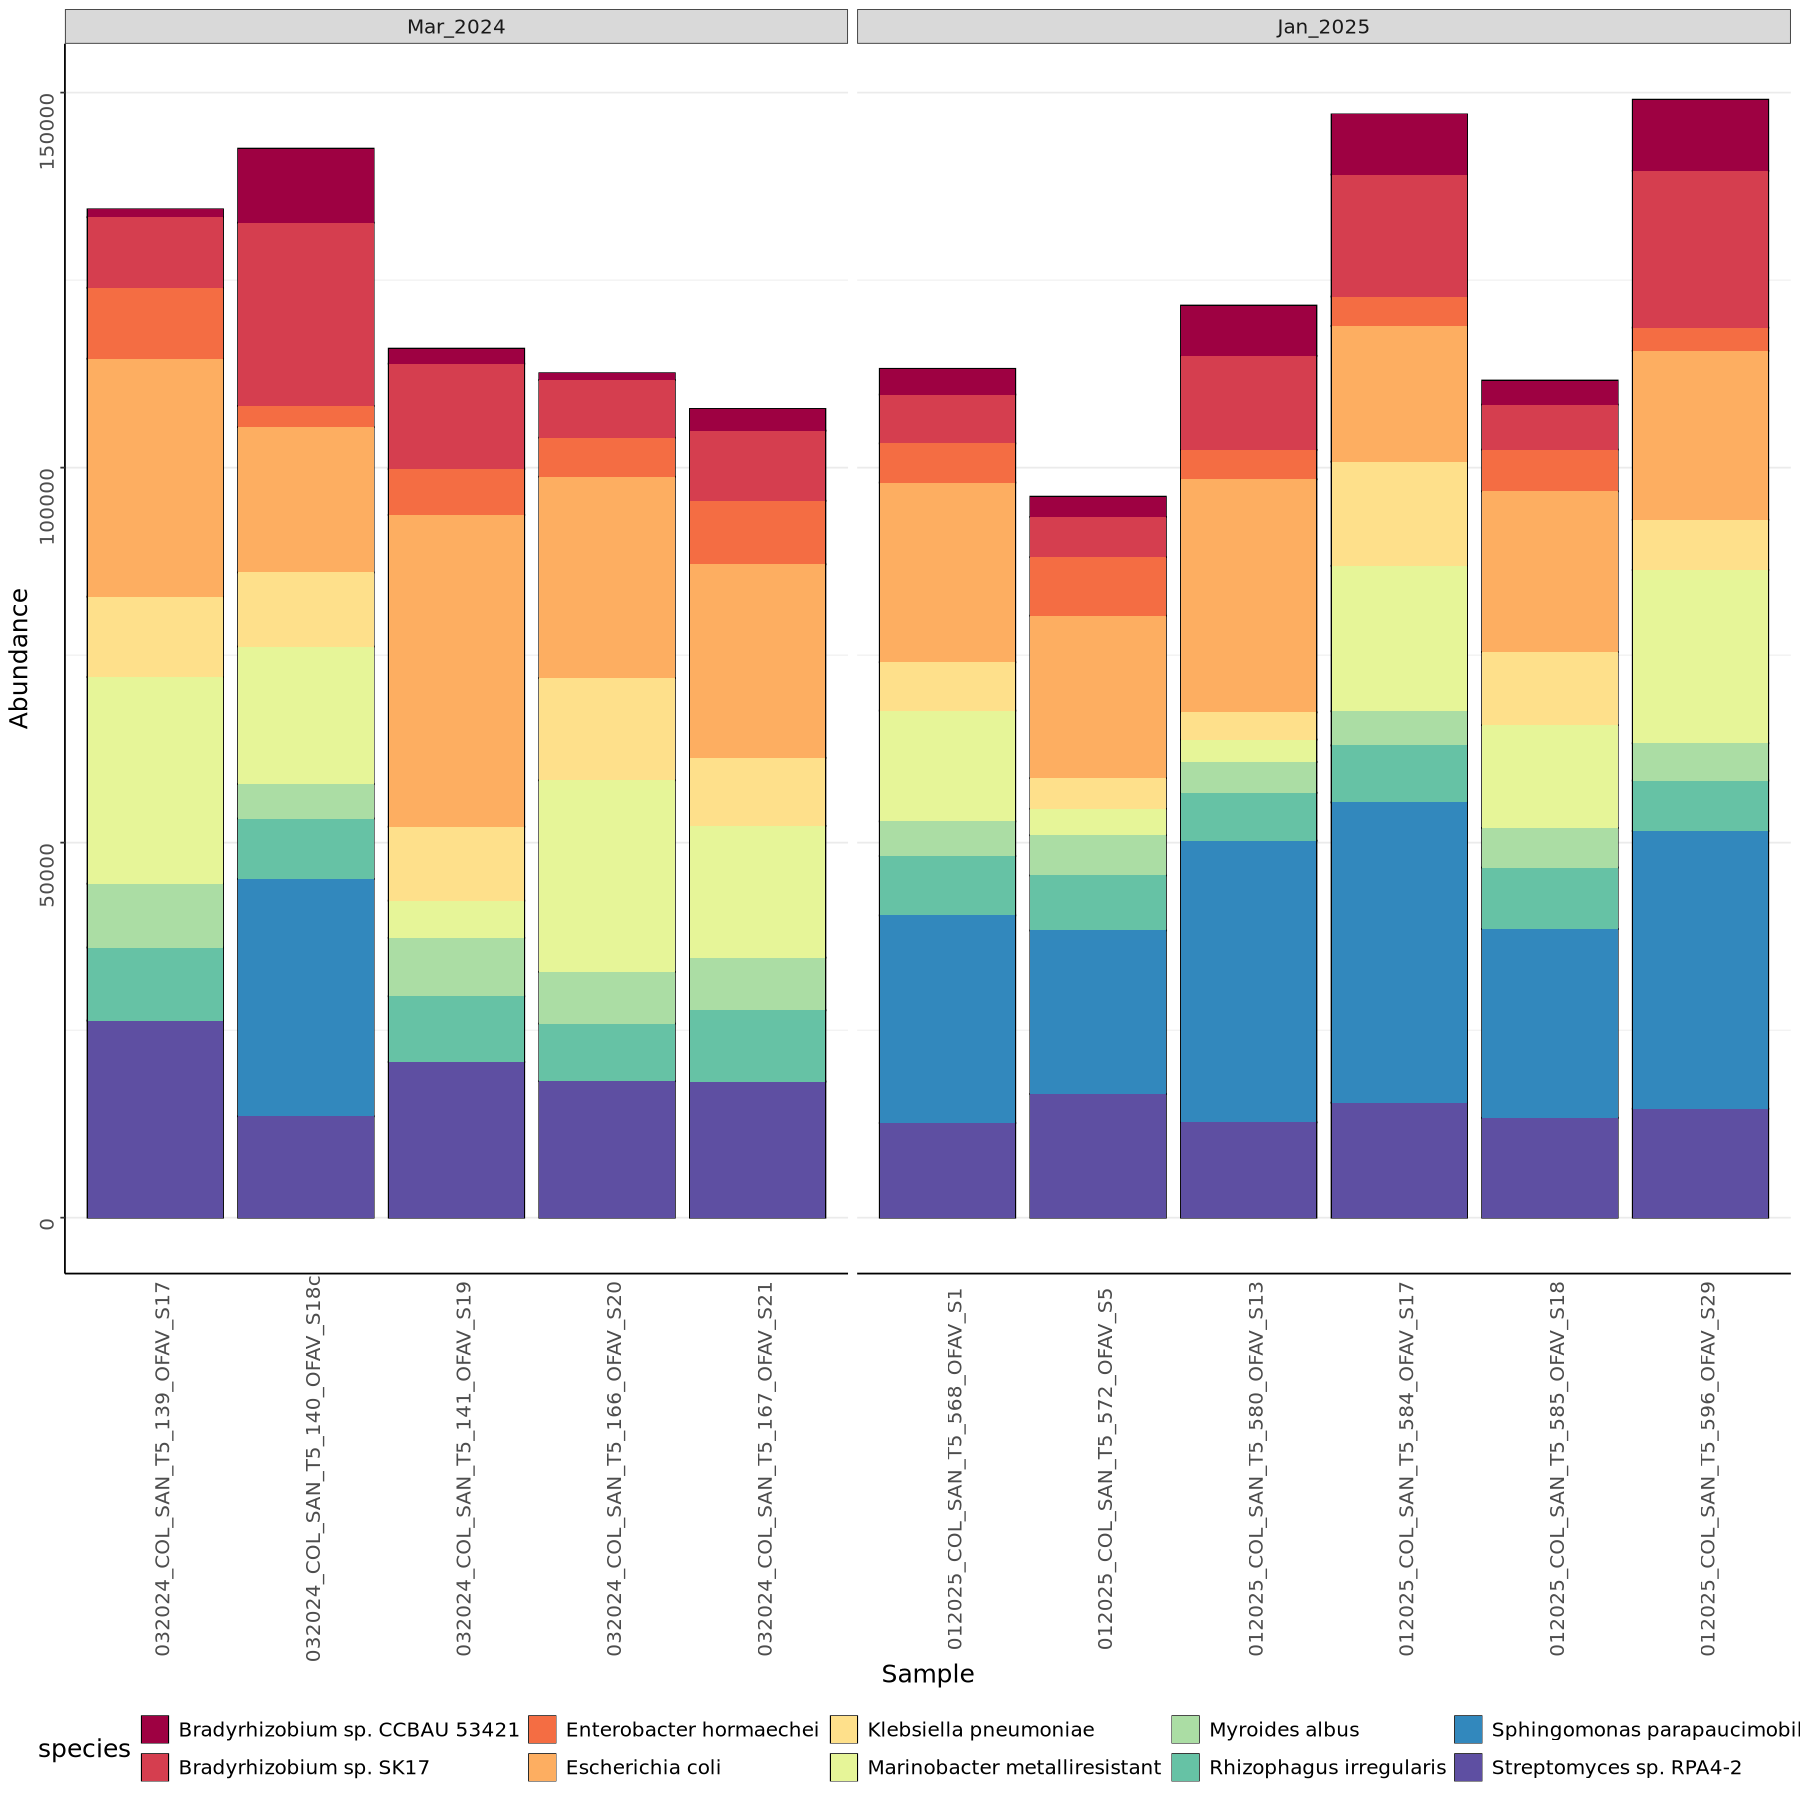

In [113]:
# bar plot of top 10 abundant taxa in OFAV samples
ofav_10_bar<-plot_bar(COL_ofav_10,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_10_bar

Relative abundance plot

In [114]:
ggsave(filename = "ofav_top_10_species_bar.png", plot = ofav_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [115]:
COL_ofav_10_rel <- transform_sample_counts(COL_ofav_10, function(x) x / sum(x))

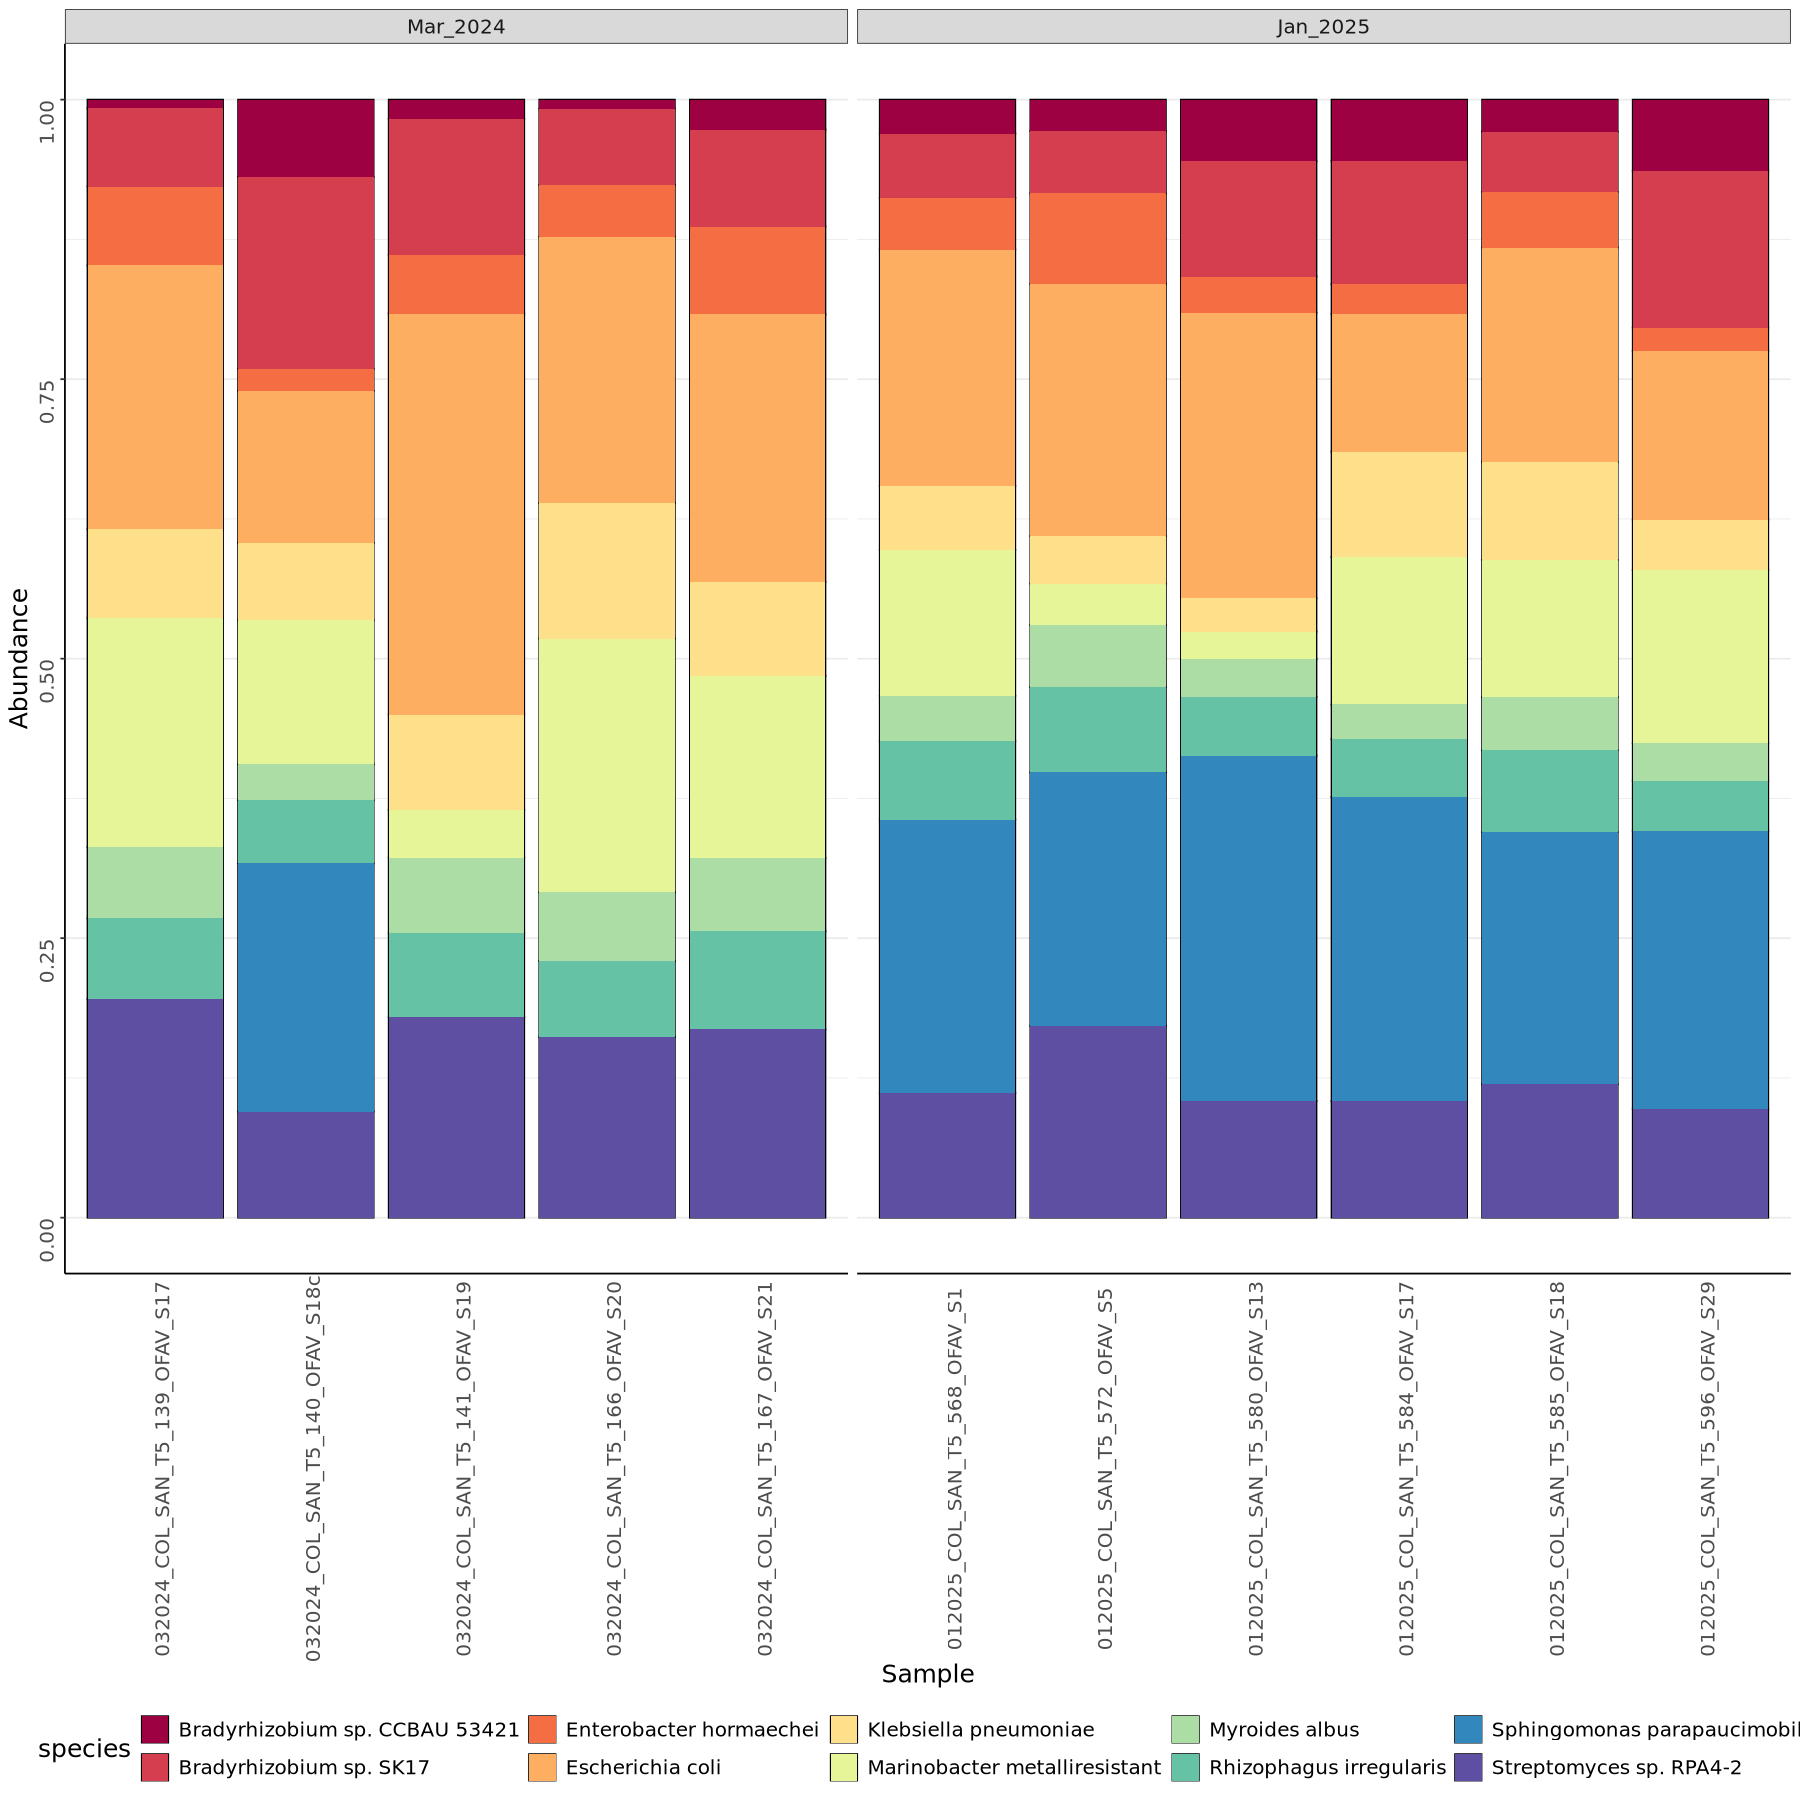

In [116]:
# bar plot of top 10 abundant taxa in OFAV samples
ofav_10_rel_bar<-plot_bar(COL_ofav_10_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_10_rel_bar

Top 50 taxa

In [117]:
ggsave(filename = "ofav_top_10_species_rel_bar.png", plot = ofav_10_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [118]:
#now do top 50
COL_ofav_50 = prune_taxa(names(sort(taxa_sums(COL_ofav),TRUE)[1:50]), COL_ofav)

In [119]:
sample_data(COL_ofav_50)$Year_o <- factor(sample_data(COL_ofav_50)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

In [120]:
#from rampgenerator.com 
colors_50 <- c("#A6CEE3",
  "#88BBD8",
  "#69A7CE",
  "#4B94C3",
  "#2D81B9",
  "#3185AF",
  "#529CA5",
  "#73B39C",
  "#94CA93",
  "#AFDE88",
  "#93D073",
  "#76C15E",
  "#5AB349",
  "#3DA534",
  "#509F3C",
  "#7C9E54",
  "#A99C6D",
  "#D69B85",
  "#FA9594",
  "#F57878",
  "#EF5B5C",
  "#EA3F40",
  "#E42224",
  "#E7352A",
  "#ED5A3C",
  "#F37F4F",
  "#F9A461",
  "#FDBB68",
  "#FEAD4F",
  "#FE9E36",
  "#FE901D",
  "#FF8205",
  "#F58827",
  "#E99457",
  "#DD9F87",
  "#D2ABB7",
  "#C2A8D1",
  "#AD8EC4",
  "#9774B6",
  "#825AA9",
  "#6C3F9B",
  "#88659A",
  "#AA909A",
  "#CBBC99",
  "#EDE799",
  "#F7EE8D",
  "#E6C974",
  "#D4A45B",
  "#C37E41",
  "#B15928")

In [121]:
options(repr.plot.width=20, repr.plot.height=15)

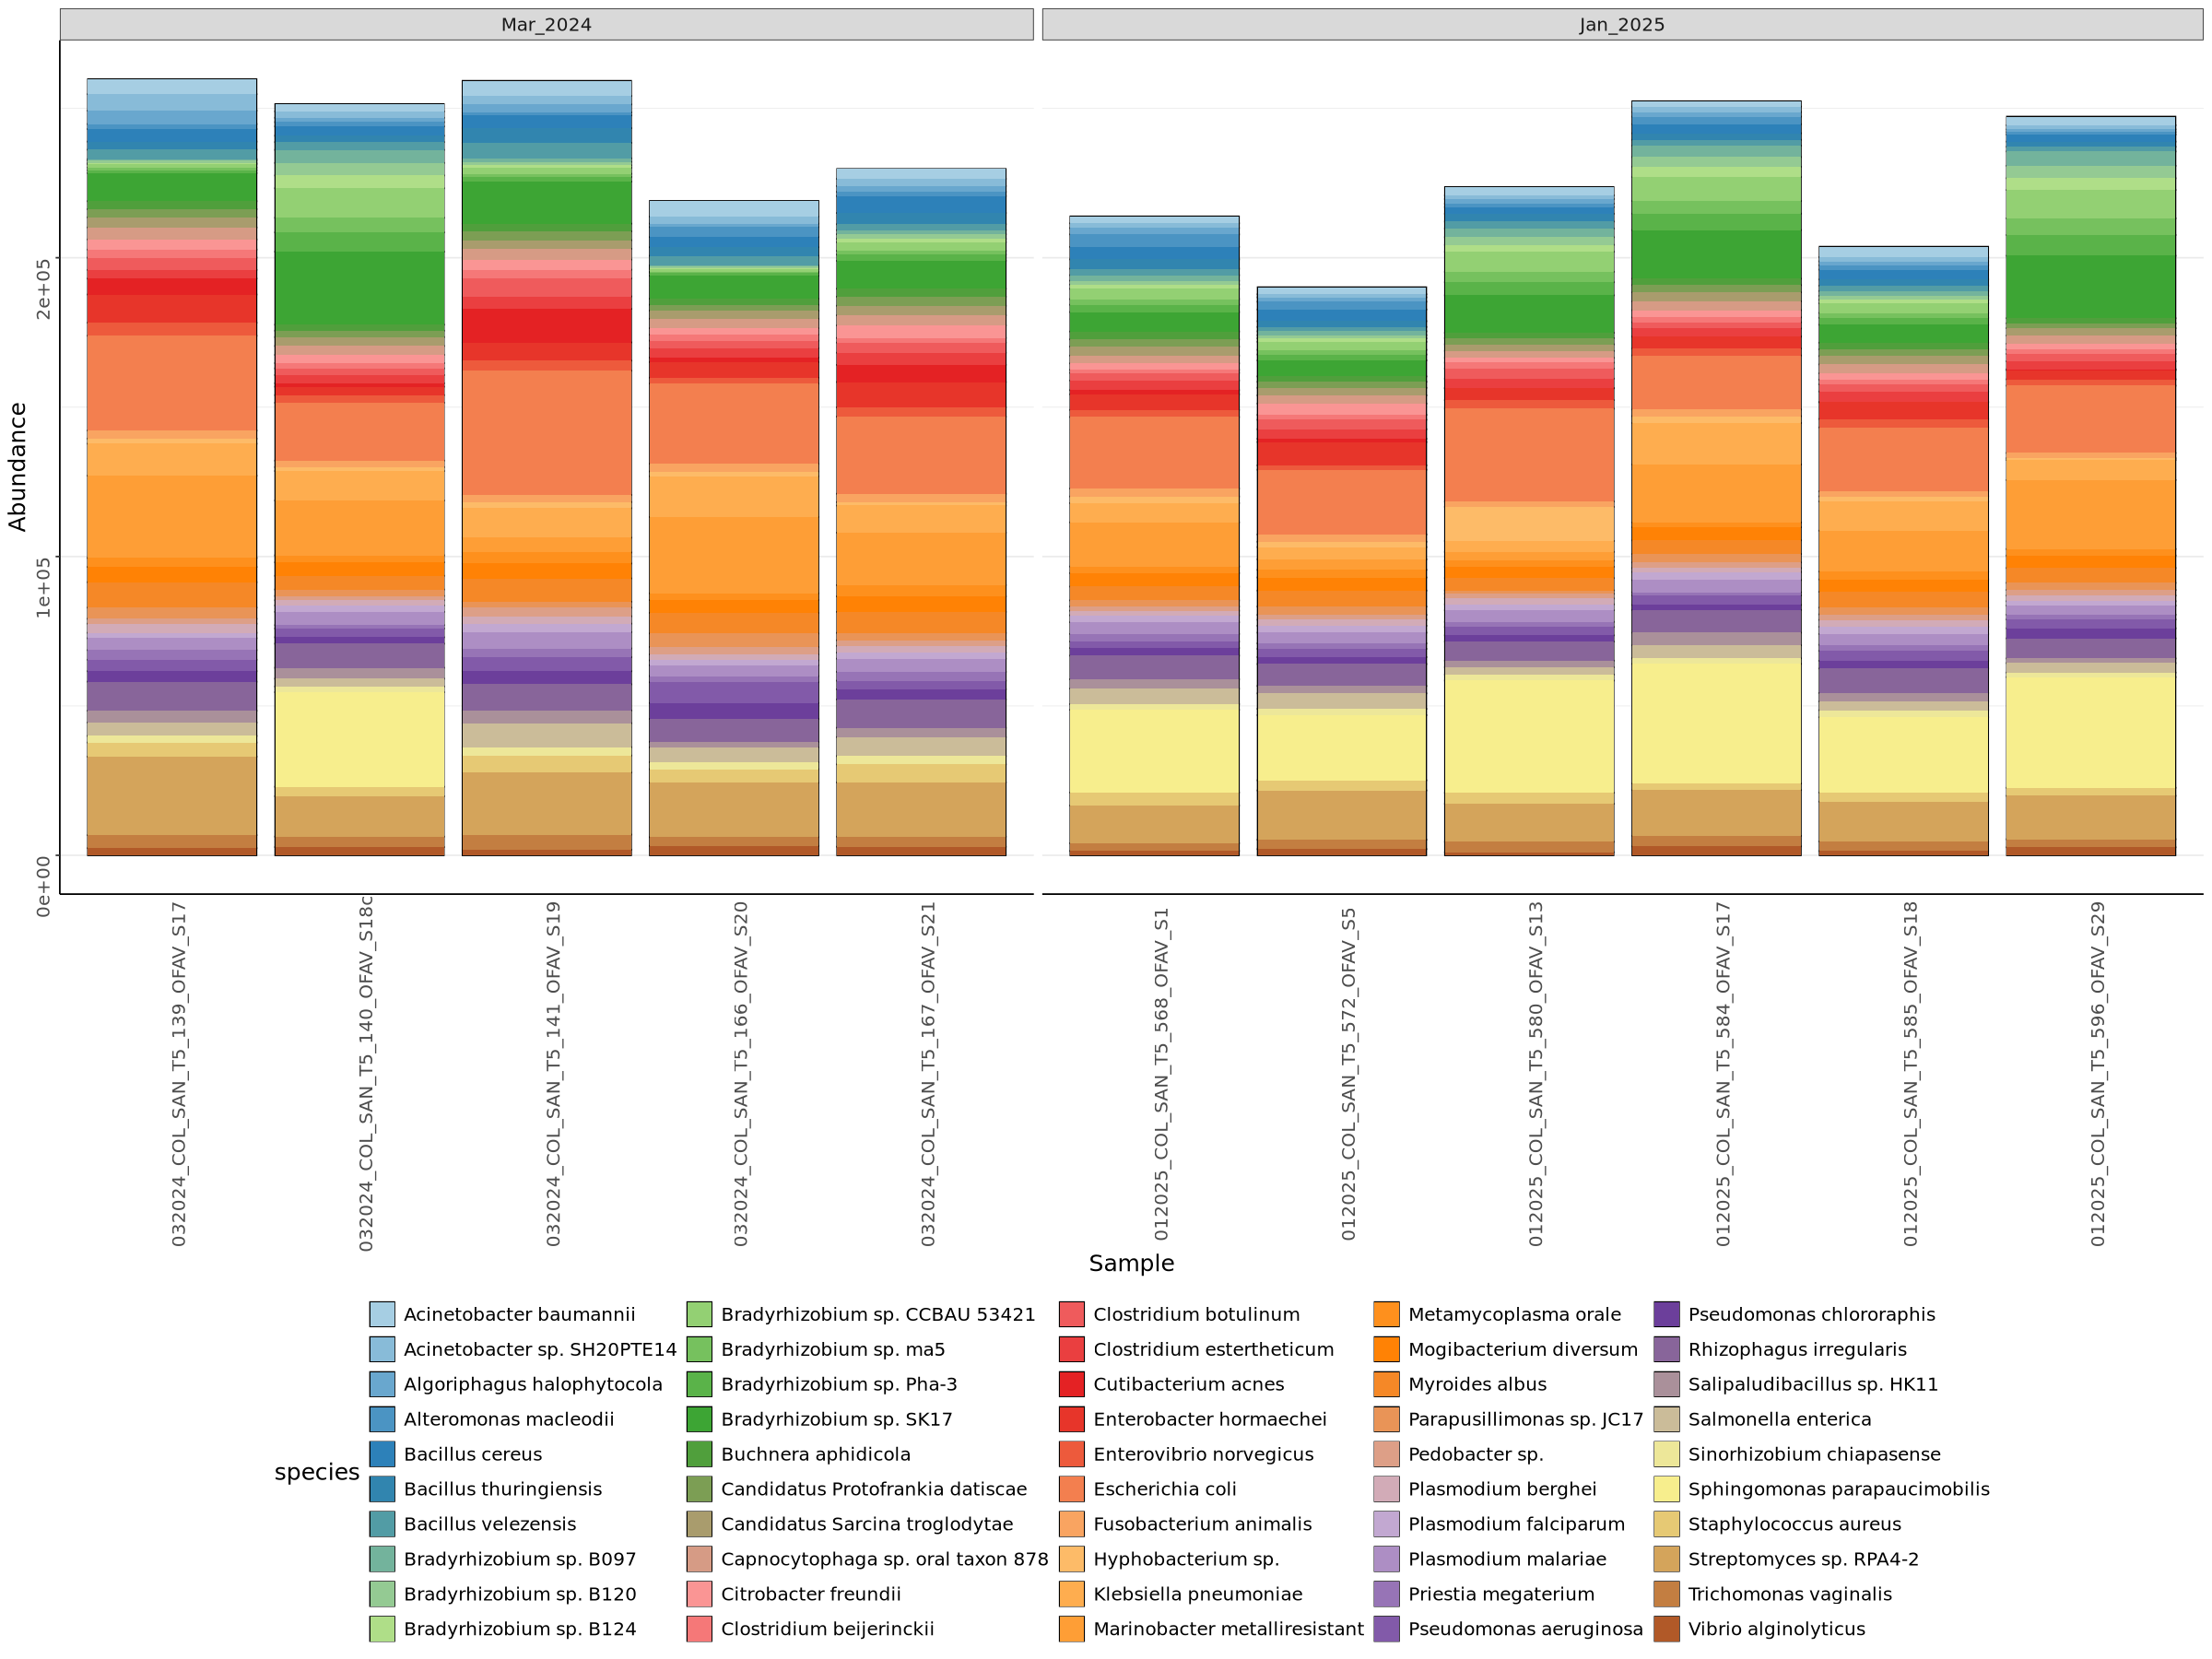

In [122]:
# bar plot of top 50 abundant taxa in OFAV samples
ofav_50_bar<-plot_bar(COL_ofav_50,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_50_bar

In [123]:
ggsave(filename = "ofav_top_50_species_bar.png", plot = ofav_50_bar, 
      width = 20,
      height = 15,
      units = "in",
      dpi = 100)

In [124]:
COL_ofav_50_rel <- transform_sample_counts(COL_ofav_50, function(x) x / sum(x))

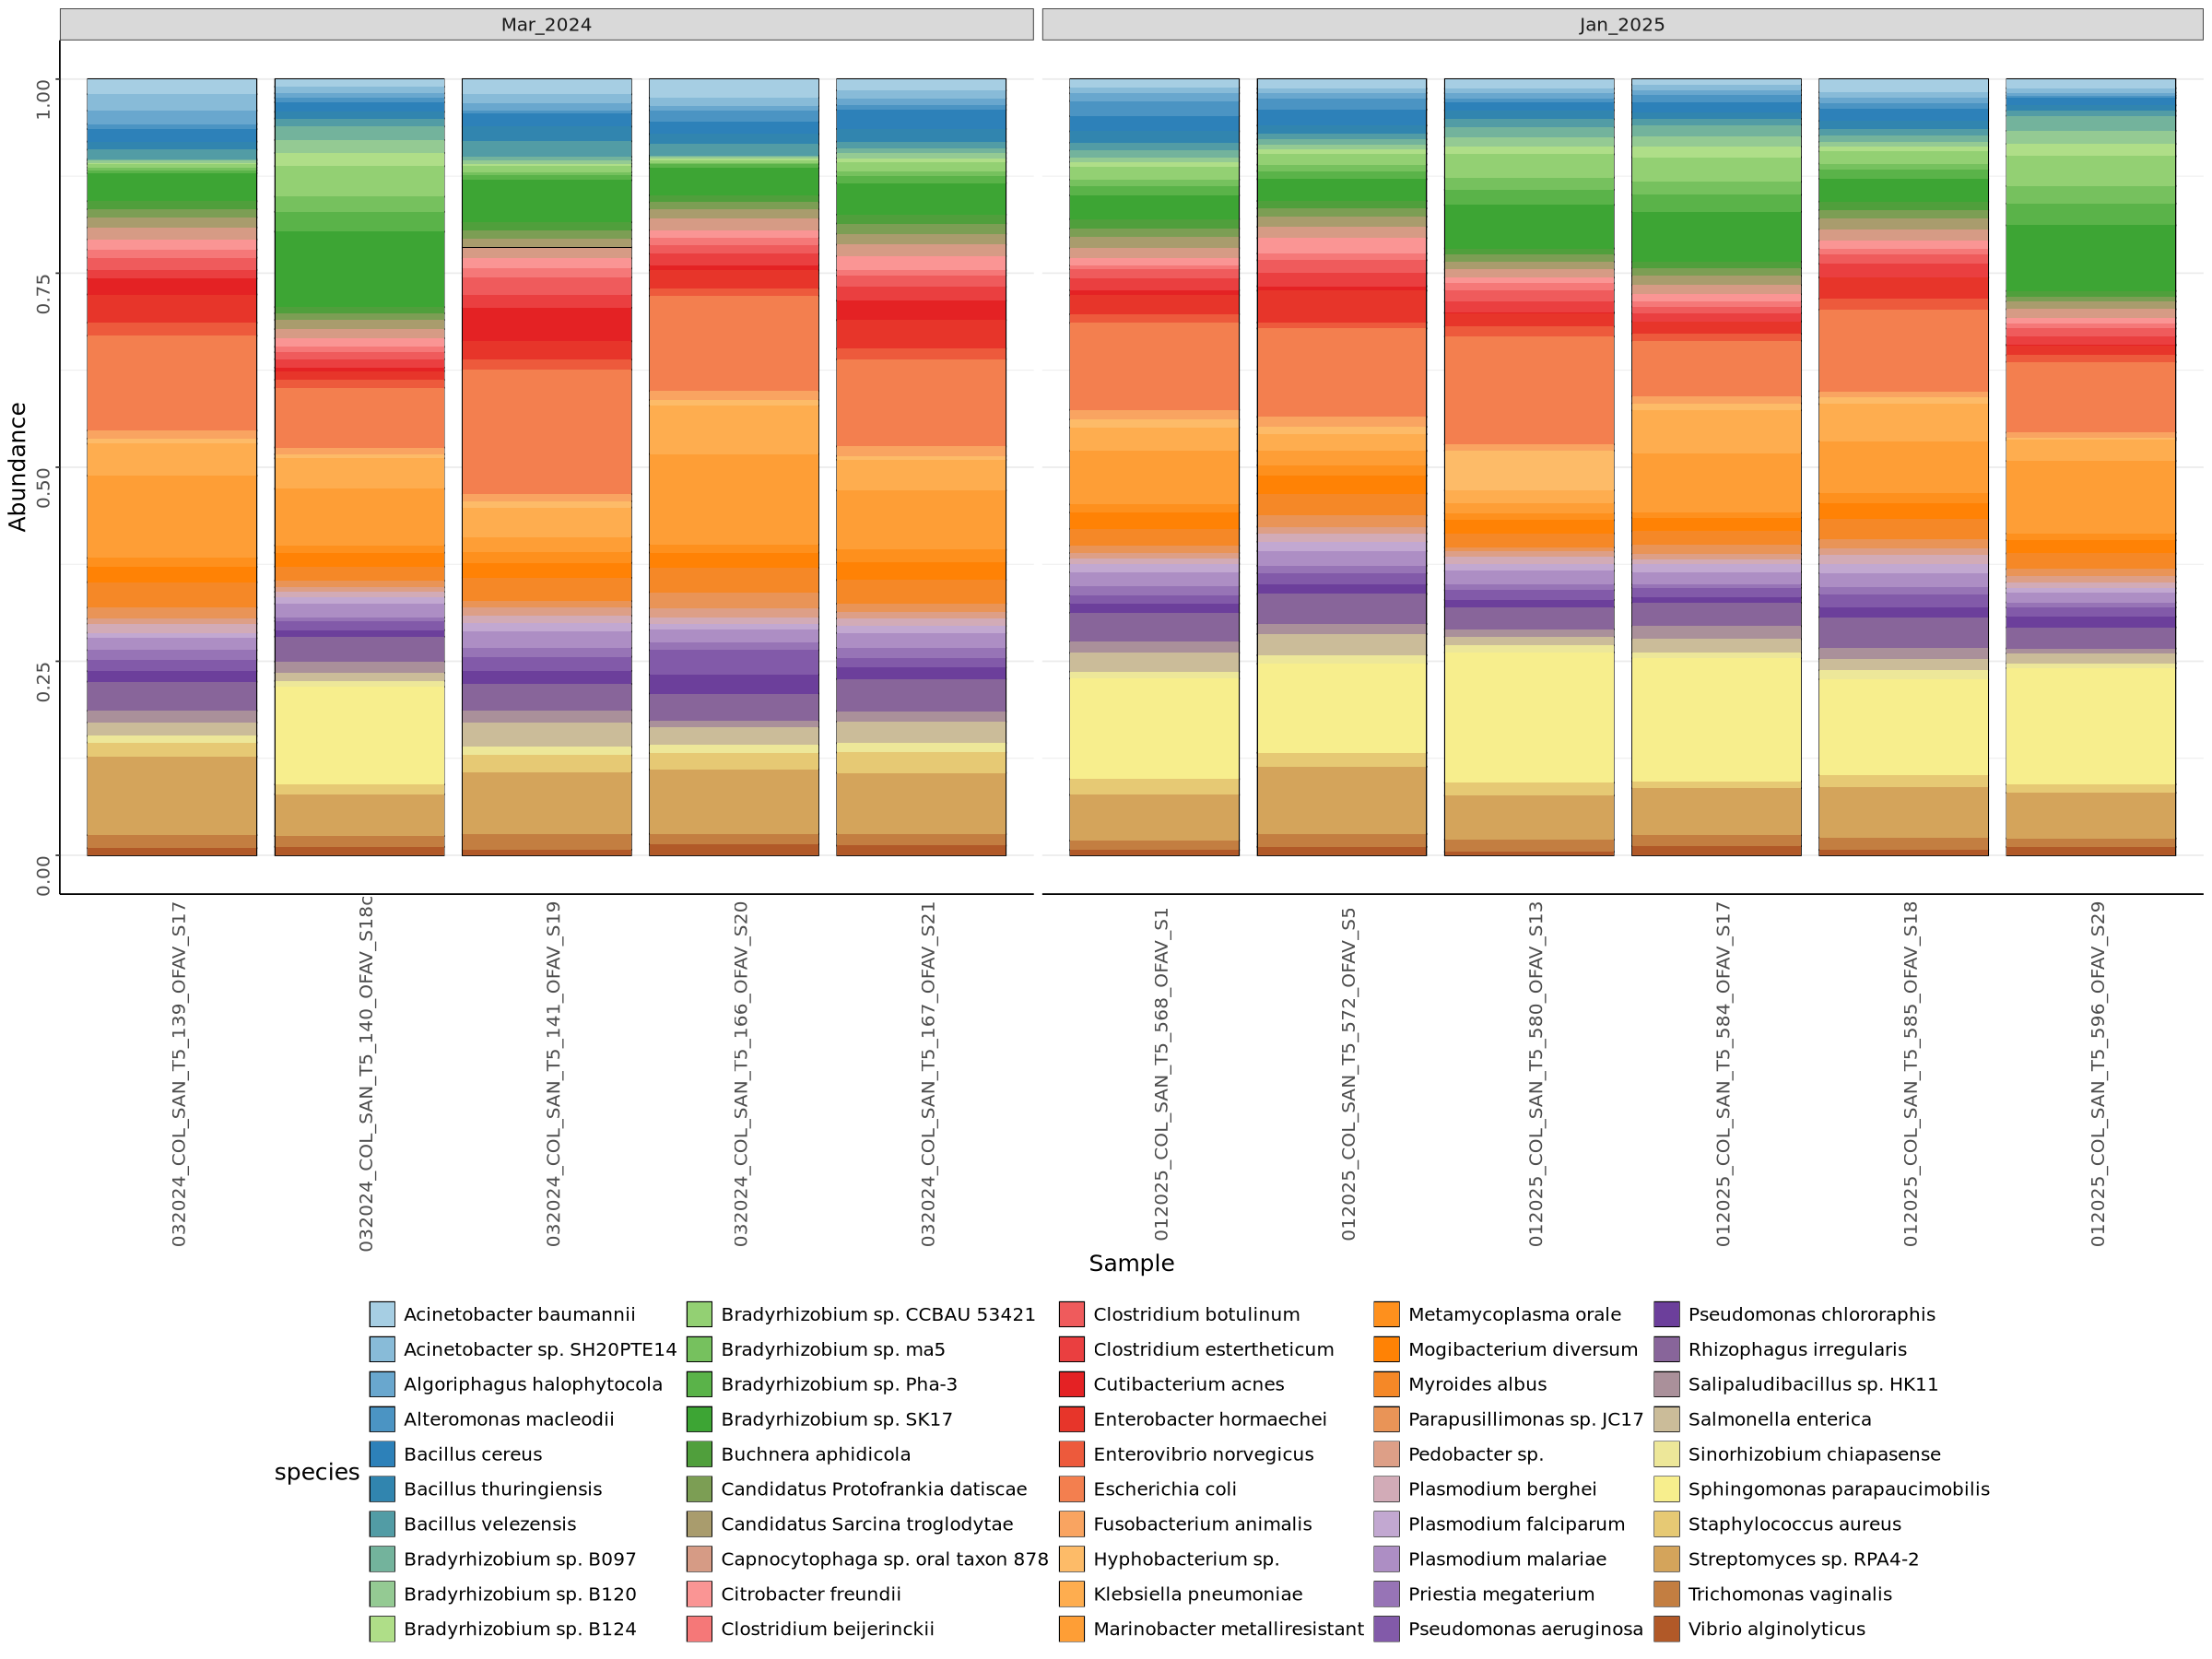

In [125]:
# bar plot of top 50 abundant taxa in OFAV samples
ofav_50_rel_bar<-plot_bar(COL_ofav_50_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_50_rel_bar

In [126]:
ggsave(filename = "ofav_top_50_species_rel_bar.png", plot = ofav_50_rel_bar, 
      width = 20,
      height = 15,
      units = "in",
      dpi = 100)

not a whole lot of variability between OFAV samples, is this weird? Going to look at MCAV samples

### MCAV

In [128]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken"

In [127]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_mcav = read.csv('mcav_otu_table_ready.csv')
head(otu_mcav)

,X,X032024_COL_SAN_T5_128_MCAV_S1,X032024_COL_SAN_T5_129_MCAV_S2,X032024_COL_SAN_T5_130_MCAV_S37,X032024_COL_SAN_T5_131_MCAV_S3,X032024_COL_SAN_T5_132_MCAV_S4,X032024_COL_SAN_T5_133_MCAV_S5,X032024_COL_SAN_T5_134_MCAV_S6,X032024_COL_SAN_T5_136_MCAV_S7,X032024_COL_SAN_T5_150_MCAV_S8,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_578_MCAV_S11,X012025_COL_SAN_T5_581_MCAV_S14,X012025_COL_SAN_T5_583_MCAV_S16,X012025_COL_SAN_T5_588_MCAV_S21,X012025_COL_SAN_T5_589_MCAV_S22,X012025_COL_SAN_T5_591_MCAV_S24,X012025_COL_SAN_T5_593_MCAV_S26,X012025_COL_SAN_T5_594_MCAV_S27,X012025_COL_SAN_T5_595_MCAV_S28
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,5398.495,7619.0667,9021.943,12233.95,7828.8238,5109.15308,11318.93,12210.833,6549.31208,7458.667,6548.6785,7750.6424,8132.718,12734.6423,4516.6675,10658.7260,5237.101,7894.5118,9035.6144
2,2057741,9942.761,21165.1866,32105.724,13560.52,3720.4546,3655.97054,10268.72,3948.916,5732.28649,8895.150,12537.6409,11406.6058,12325.213,881.5554,13766.0170,779.2280,13518.703,10640.0160,342.2581
3,28213,0.000,0.0000,0.000,0.00,0.0000,0.00000,0.00,0.000,87.38242,37901.076,35295.6980,50306.0564,48832.348,0.0000,50105.5526,0.0000,29474.405,37962.0569,0.0000
4,2653203,0.000,0.0000,0.000,0.00,0.0000,0.00000,0.00,0.000,135.44274,2955.842,8485.2963,7980.4458,1825.957,4838.9724,3623.1528,6790.4155,5020.634,2869.0043,4967.6322
5,1173583,0.000,140.1668,0.000,0.00,343.8335,65.75487,216.71,0.000,96.12066,0.000,212.6921,553.6173,0.000,239.5531,225.8334,500.9323,104.742,123.5002,234.6913
6,588596,5073.074,6477.7085,12792.420,12440.30,8428.3284,4214.88690,12185.77,12014.787,2957.89478,10870.316,7119.5889,9233.9190,8889.530,5164.7646,8090.7261,8780.2299,6612.713,9870.5148,9016.0568


In [128]:
# rename first col as otu
names(otu_mcav)[1] <- "otu"

#remove X's from headers
names(otu_mcav) <- sub("^X", "", names(otu_mcav))
otu_table_mcav=as.data.frame(otu_mcav)

# make the index the otus
row.names(otu_table_mcav) <- otu_table_mcav$otu
otu_table_mcav$otu <- NULL
head(otu_table_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,5398.495,7619.0667,9021.943,12233.95,7828.8238,5109.15308,11318.93,12210.833,6549.31208,7458.667,6548.6785,7750.6424,8132.718,12734.6423,4516.6675,10658.7260,5237.101,7894.5118,9035.6144
2057741,9942.761,21165.1866,32105.724,13560.52,3720.4546,3655.97054,10268.72,3948.916,5732.28649,8895.150,12537.6409,11406.6058,12325.213,881.5554,13766.0170,779.2280,13518.703,10640.0160,342.2581
28213,0.000,0.0000,0.000,0.00,0.0000,0.00000,0.00,0.000,87.38242,37901.076,35295.6980,50306.0564,48832.348,0.0000,50105.5526,0.0000,29474.405,37962.0569,0.0000
2653203,0.000,0.0000,0.000,0.00,0.0000,0.00000,0.00,0.000,135.44274,2955.842,8485.2963,7980.4458,1825.957,4838.9724,3623.1528,6790.4155,5020.634,2869.0043,4967.6322
1173583,0.000,140.1668,0.000,0.00,343.8335,65.75487,216.71,0.000,96.12066,0.000,212.6921,553.6173,0.000,239.5531,225.8334,500.9323,104.742,123.5002,234.6913
588596,5073.074,6477.7085,12792.420,12440.30,8428.3284,4214.88690,12185.77,12014.787,2957.89478,10870.316,7119.5889,9233.9190,8889.530,5164.7646,8090.7261,8780.2299,6612.713,9870.5148,9016.0568


In [129]:
# sort by most abundant OTUs
otus_sorted_mcav <- otu_table_mcav[order(rowSums(otu_table_mcav), decreasing = TRUE), ]
head(otus_sorted_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
28213,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,87.38242,37901.076,35295.698,50306.056,48832.348,0.0000,50105.553,0.000,29474.405,37962.057,0.0000
2057741,9942.761,21165.187,32105.724,13560.521,3720.455,3655.971,10268.72,3948.916,5732.28649,8895.150,12537.641,11406.606,12325.213,881.5554,13766.017,779.228,13518.703,10640.016,342.2581
588596,5073.074,6477.708,12792.420,12440.304,8428.328,4214.887,12185.77,12014.787,2957.89478,10870.316,7119.589,9233.919,8889.530,5164.7646,8090.726,8780.230,6612.713,9870.515,9016.0568
562,5398.495,7619.067,9021.943,12233.948,7828.824,5109.153,11318.93,12210.833,6549.31208,7458.667,6548.679,7750.642,8132.718,12734.6423,4516.667,10658.726,5237.101,7894.512,9035.6144
573,4154.923,10162.093,5727.498,8755.380,4540.365,6542.609,9551.91,10222.372,15877.38499,6629.926,6224.043,5003.447,6390.851,9198.8386,8424.567,13399.939,11221.362,5795.009,6942.9505
28901,3074.062,4004.766,2916.641,8814.339,7758.294,6273.014,1967.06,4481.040,10870.37255,2651.970,11675.678,6319.594,7051.559,5998.4094,7295.400,8641.082,9636.266,7904.012,9612.5638


In [130]:
# Convert to matrix
otus_mcav=as.matrix(otus_sorted_mcav)
head(otus_mcav)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28
28213,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,87.38242,37901.076,35295.698,50306.056,48832.348,0.0000,50105.553,0.000,29474.405,37962.057,0.0000
2057741,9942.761,21165.187,32105.724,13560.521,3720.455,3655.971,10268.72,3948.916,5732.28649,8895.150,12537.641,11406.606,12325.213,881.5554,13766.017,779.228,13518.703,10640.016,342.2581
588596,5073.074,6477.708,12792.420,12440.304,8428.328,4214.887,12185.77,12014.787,2957.89478,10870.316,7119.589,9233.919,8889.530,5164.7646,8090.726,8780.230,6612.713,9870.515,9016.0568
562,5398.495,7619.067,9021.943,12233.948,7828.824,5109.153,11318.93,12210.833,6549.31208,7458.667,6548.679,7750.642,8132.718,12734.6423,4516.667,10658.726,5237.101,7894.512,9035.6144
573,4154.923,10162.093,5727.498,8755.380,4540.365,6542.609,9551.91,10222.372,15877.38499,6629.926,6224.043,5003.447,6390.851,9198.8386,8424.567,13399.939,11221.362,5795.009,6942.9505
28901,3074.062,4004.766,2916.641,8814.339,7758.294,6273.014,1967.06,4481.040,10870.37255,2651.970,11675.678,6319.594,7051.559,5998.4094,7295.400,8641.082,9636.266,7904.012,9612.5638


In [131]:
#filter metadata for mcavs only
metadata_mcav <- metadata[metadata$Species=="MCAV",]
head(metadata_mcav)
dim(metadata_mcav)

,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_128_MCAV_S1,ELARBOL,3/7/24,Mar_2024,8,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_129_MCAV_S2,ELARBOL,3/7/24,Mar_2024,14,MCAV,Healthy,Diseased,,,
032024_COL_SAN_T5_130_MCAV_S37,ELARBOL,3/7/24,Mar_2024,7,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_131_MCAV_S3,ELARBOL,3/7/24,Mar_2024,6,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_132_MCAV_S4,ELARBOL,3/7/24,Mar_2024,5,MCAV,Healthy,Healthy,,,
032024_COL_SAN_T5_133_MCAV_S5,ELARBOL,3/7/24,Mar_2024,13,MCAV,Healthy,Healthy,,,


[1] 19 10

In [132]:
# classify phyloseq objects 
OTU_M=otu_table((otus_mcav), taxa_are_rows = TRUE)
TAX_M=tax_table(taxonomy)
SAMP_M=sample_data(metadata_mcav)

In [133]:
# Create phyloseq object
COL_mcav = phyloseq(OTU_M, SAMP_M, TAX_M)
COL_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12742 taxa and 19 samples ]
sample_data() Sample Data:       [ 19 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 12742 taxa by 1 taxonomic ranks ]

In [134]:
COL_mcav_10 = prune_taxa(names(sort(taxa_sums(COL_mcav),TRUE)[1:10]), COL_mcav)

In [135]:
#order of facets
sample_data(COL_mcav_10)$Year_m <- factor(sample_data(COL_mcav_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

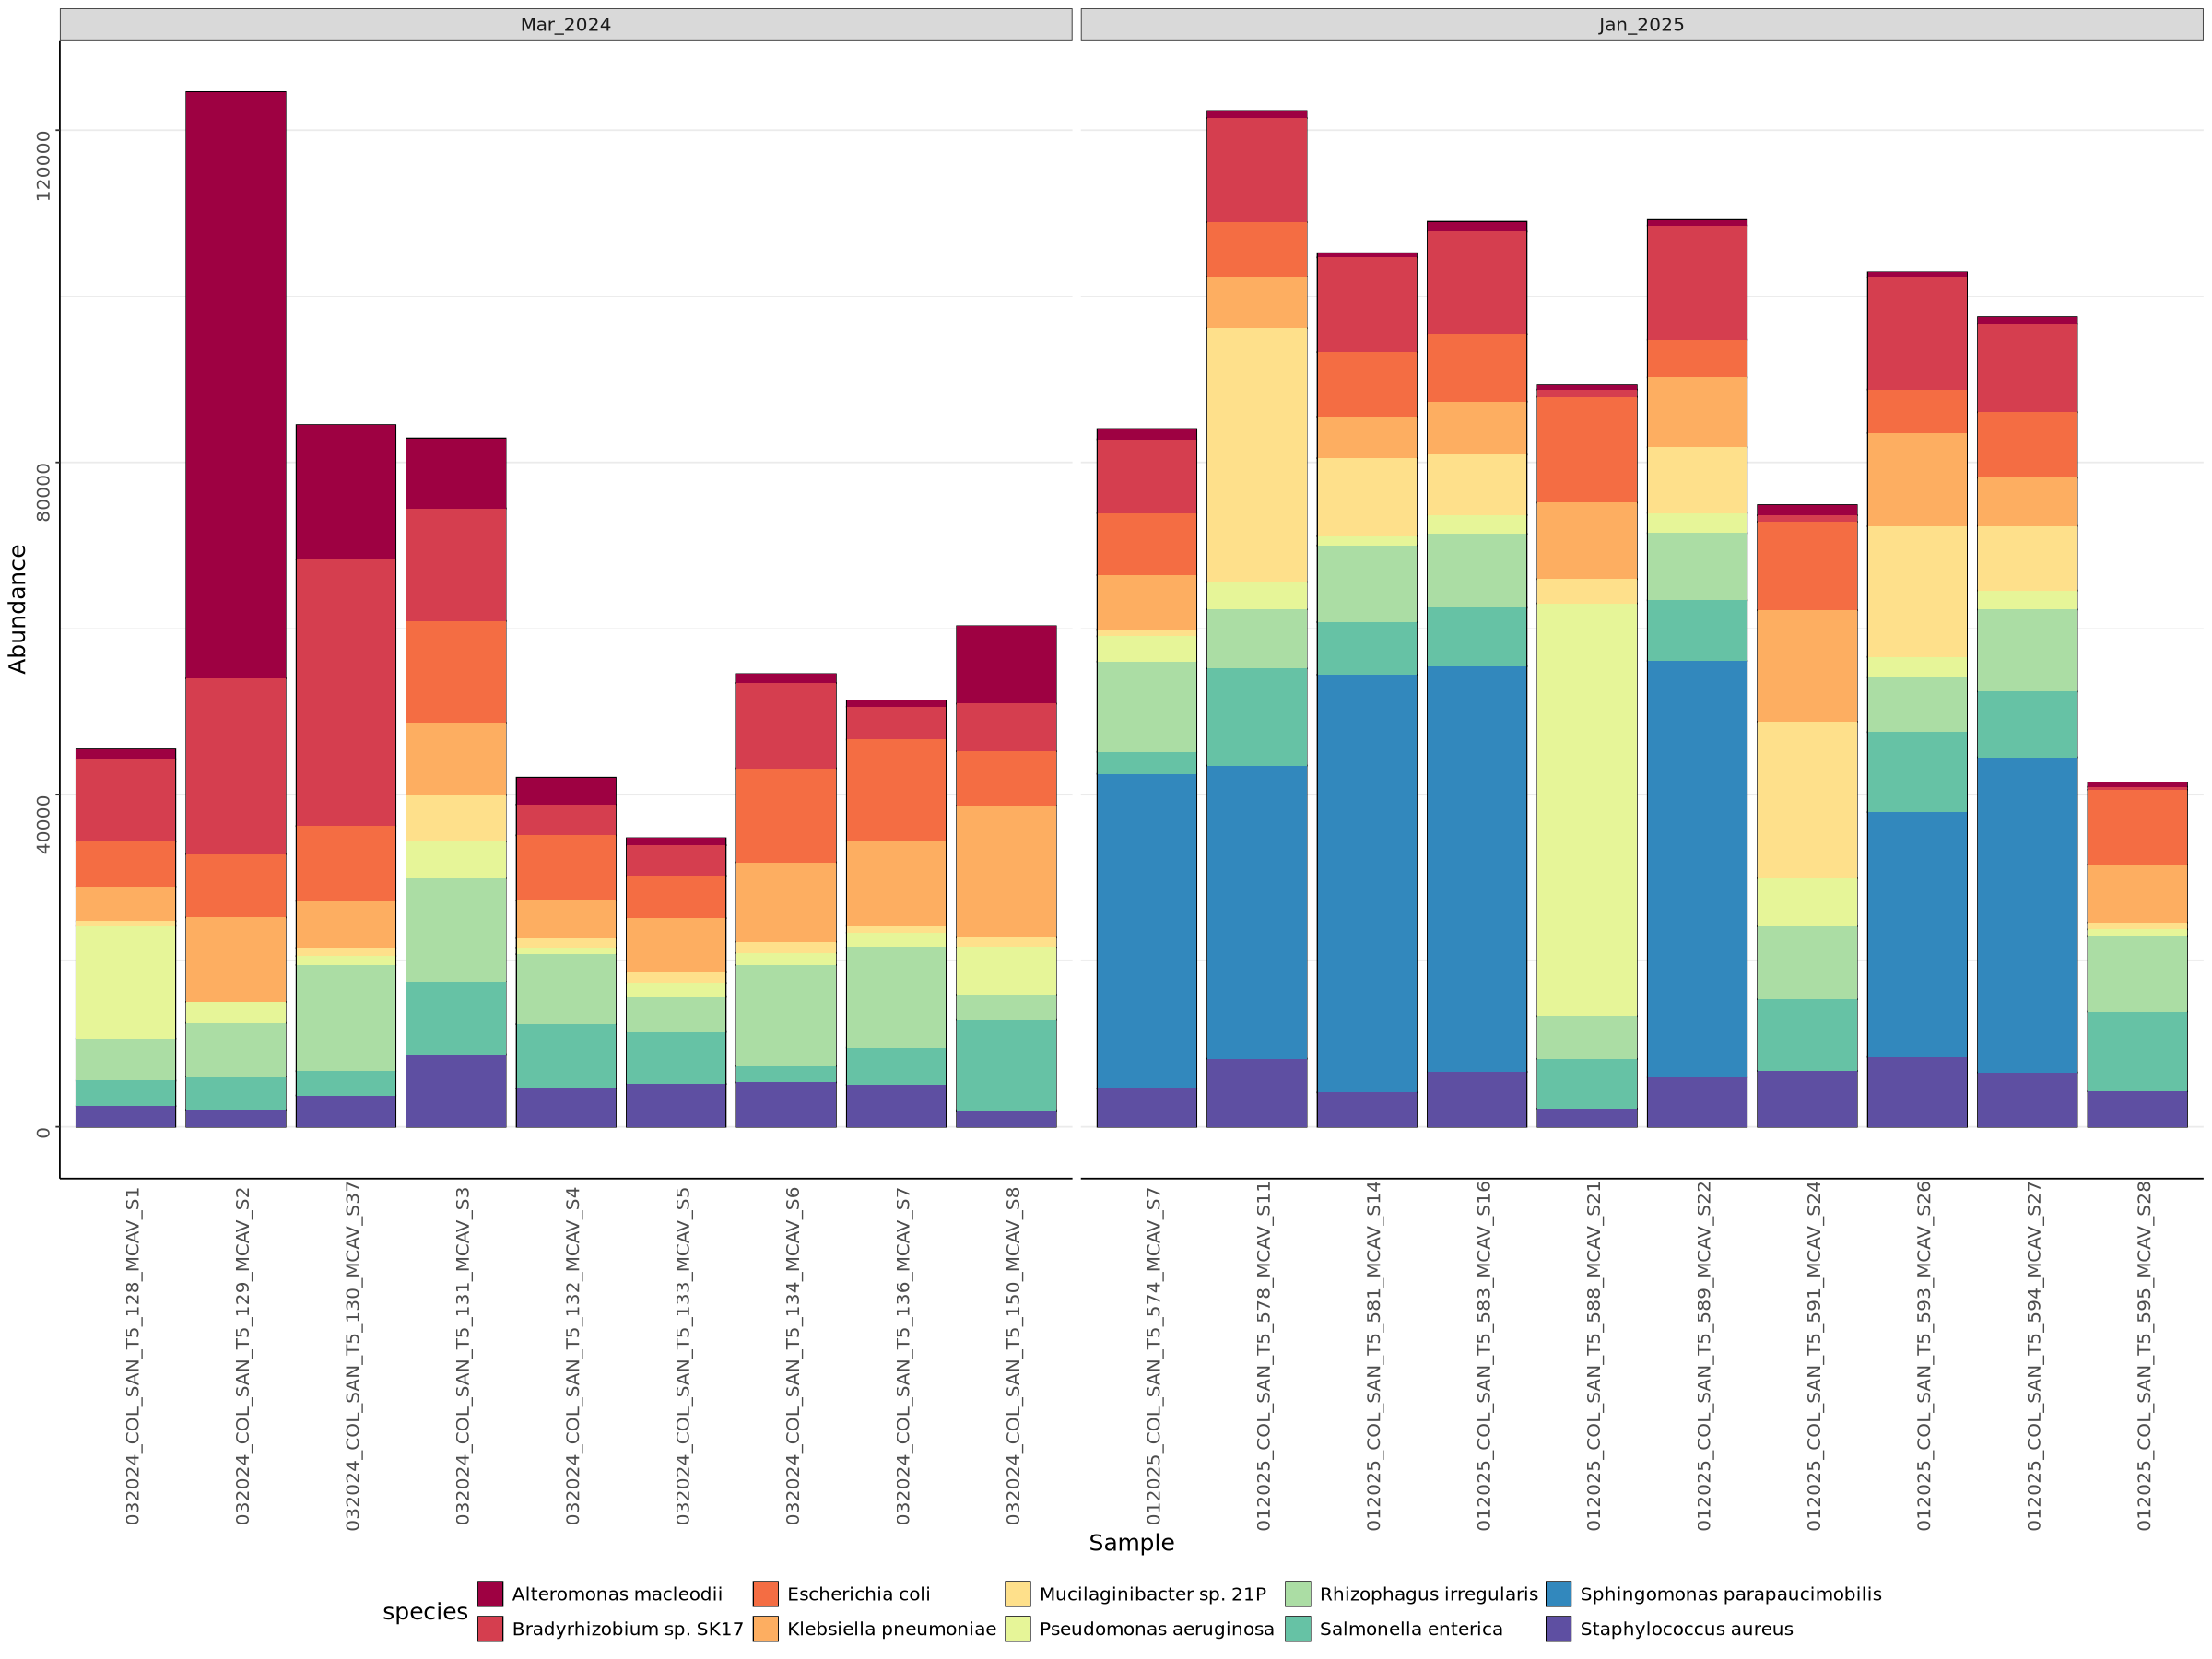

In [136]:
# bar plot of top 10 abundant taxa in MCAV samples
mcav_10_bar<-plot_bar(COL_mcav_10,fill='species')+
facet_grid(~Year_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_10_bar

In [137]:
ggsave(filename = "mcav_top_10_species_bar.png", plot = mcav_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [138]:
COL_mcav_10_rel <- transform_sample_counts(COL_mcav_10, function(x) x / sum(x))

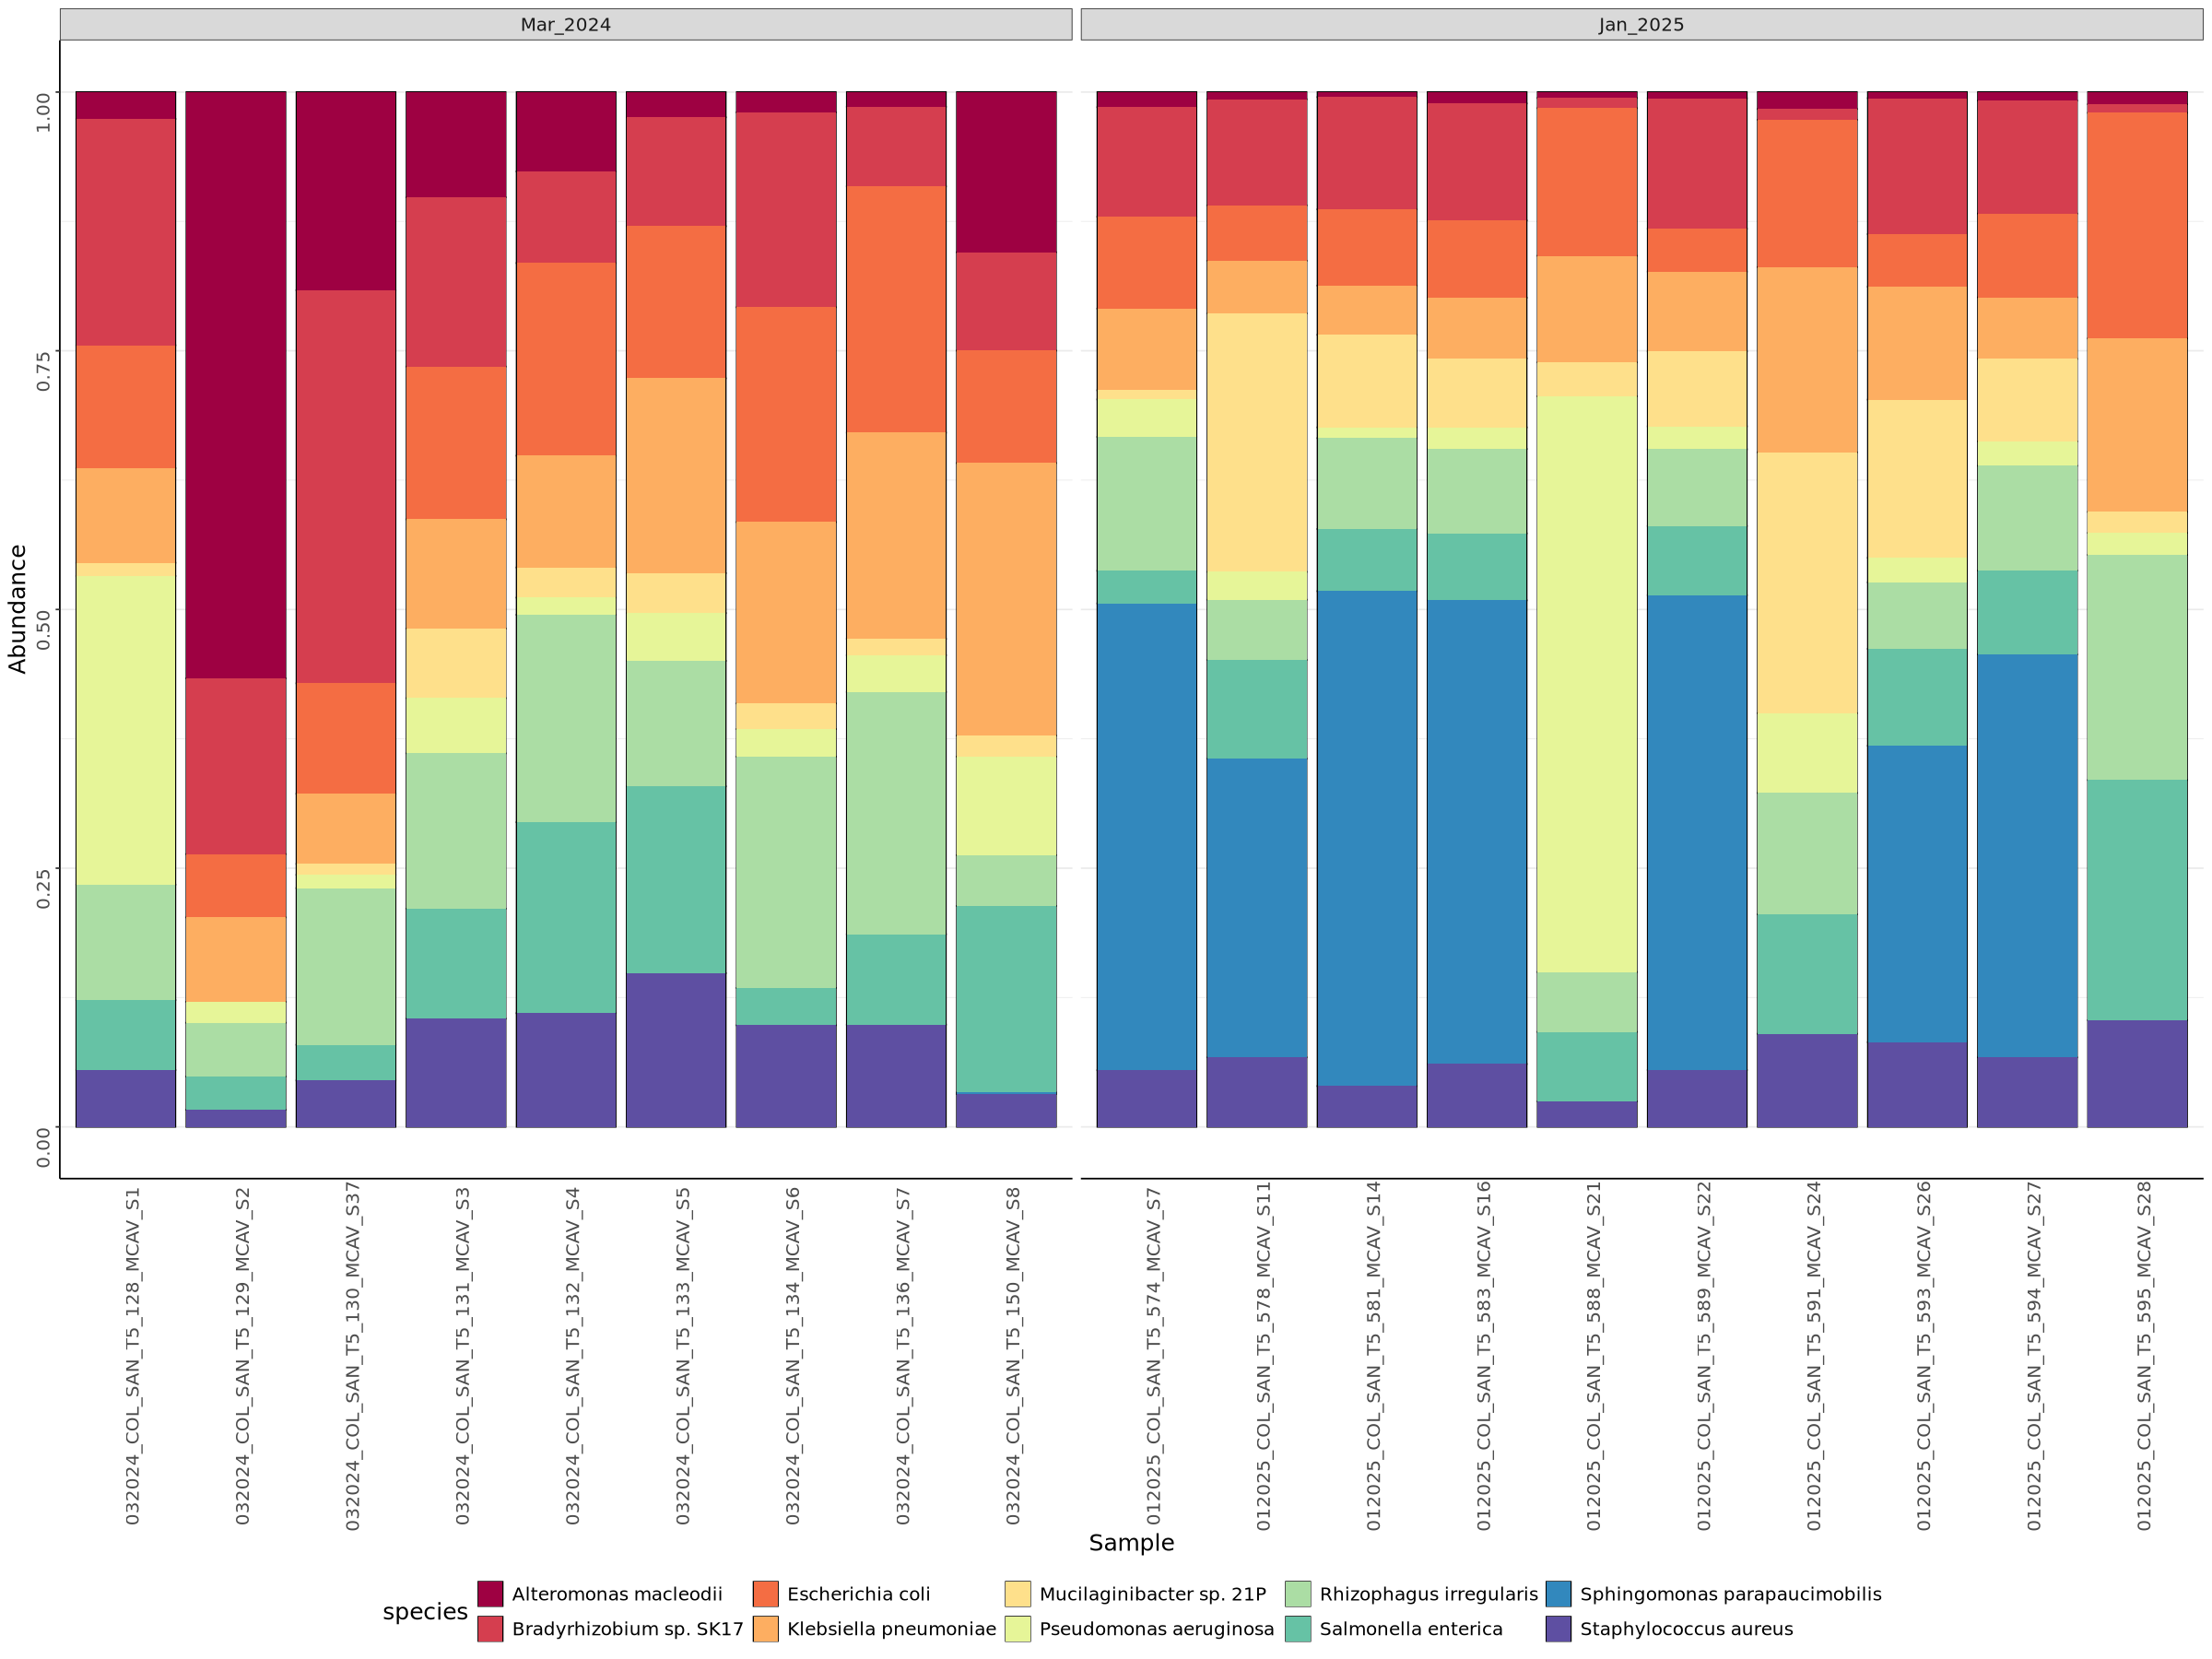

In [139]:
# bar plot of top 10 relative abundances in MCAV samples
mcav_10_rel_bar<-plot_bar(COL_mcav_10_rel,fill='species')+
facet_grid(~Year_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_10_rel_bar

In [140]:
ggsave(filename = "mcav_top_10_species_rel_bar.png", plot = mcav_10_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [141]:
#now do top 50
COL_mcav_50 = prune_taxa(names(sort(taxa_sums(COL_mcav),TRUE)[1:50]), COL_mcav)

In [142]:
sample_data(COL_mcav_50)$Year_o <- factor(sample_data(COL_mcav_50)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

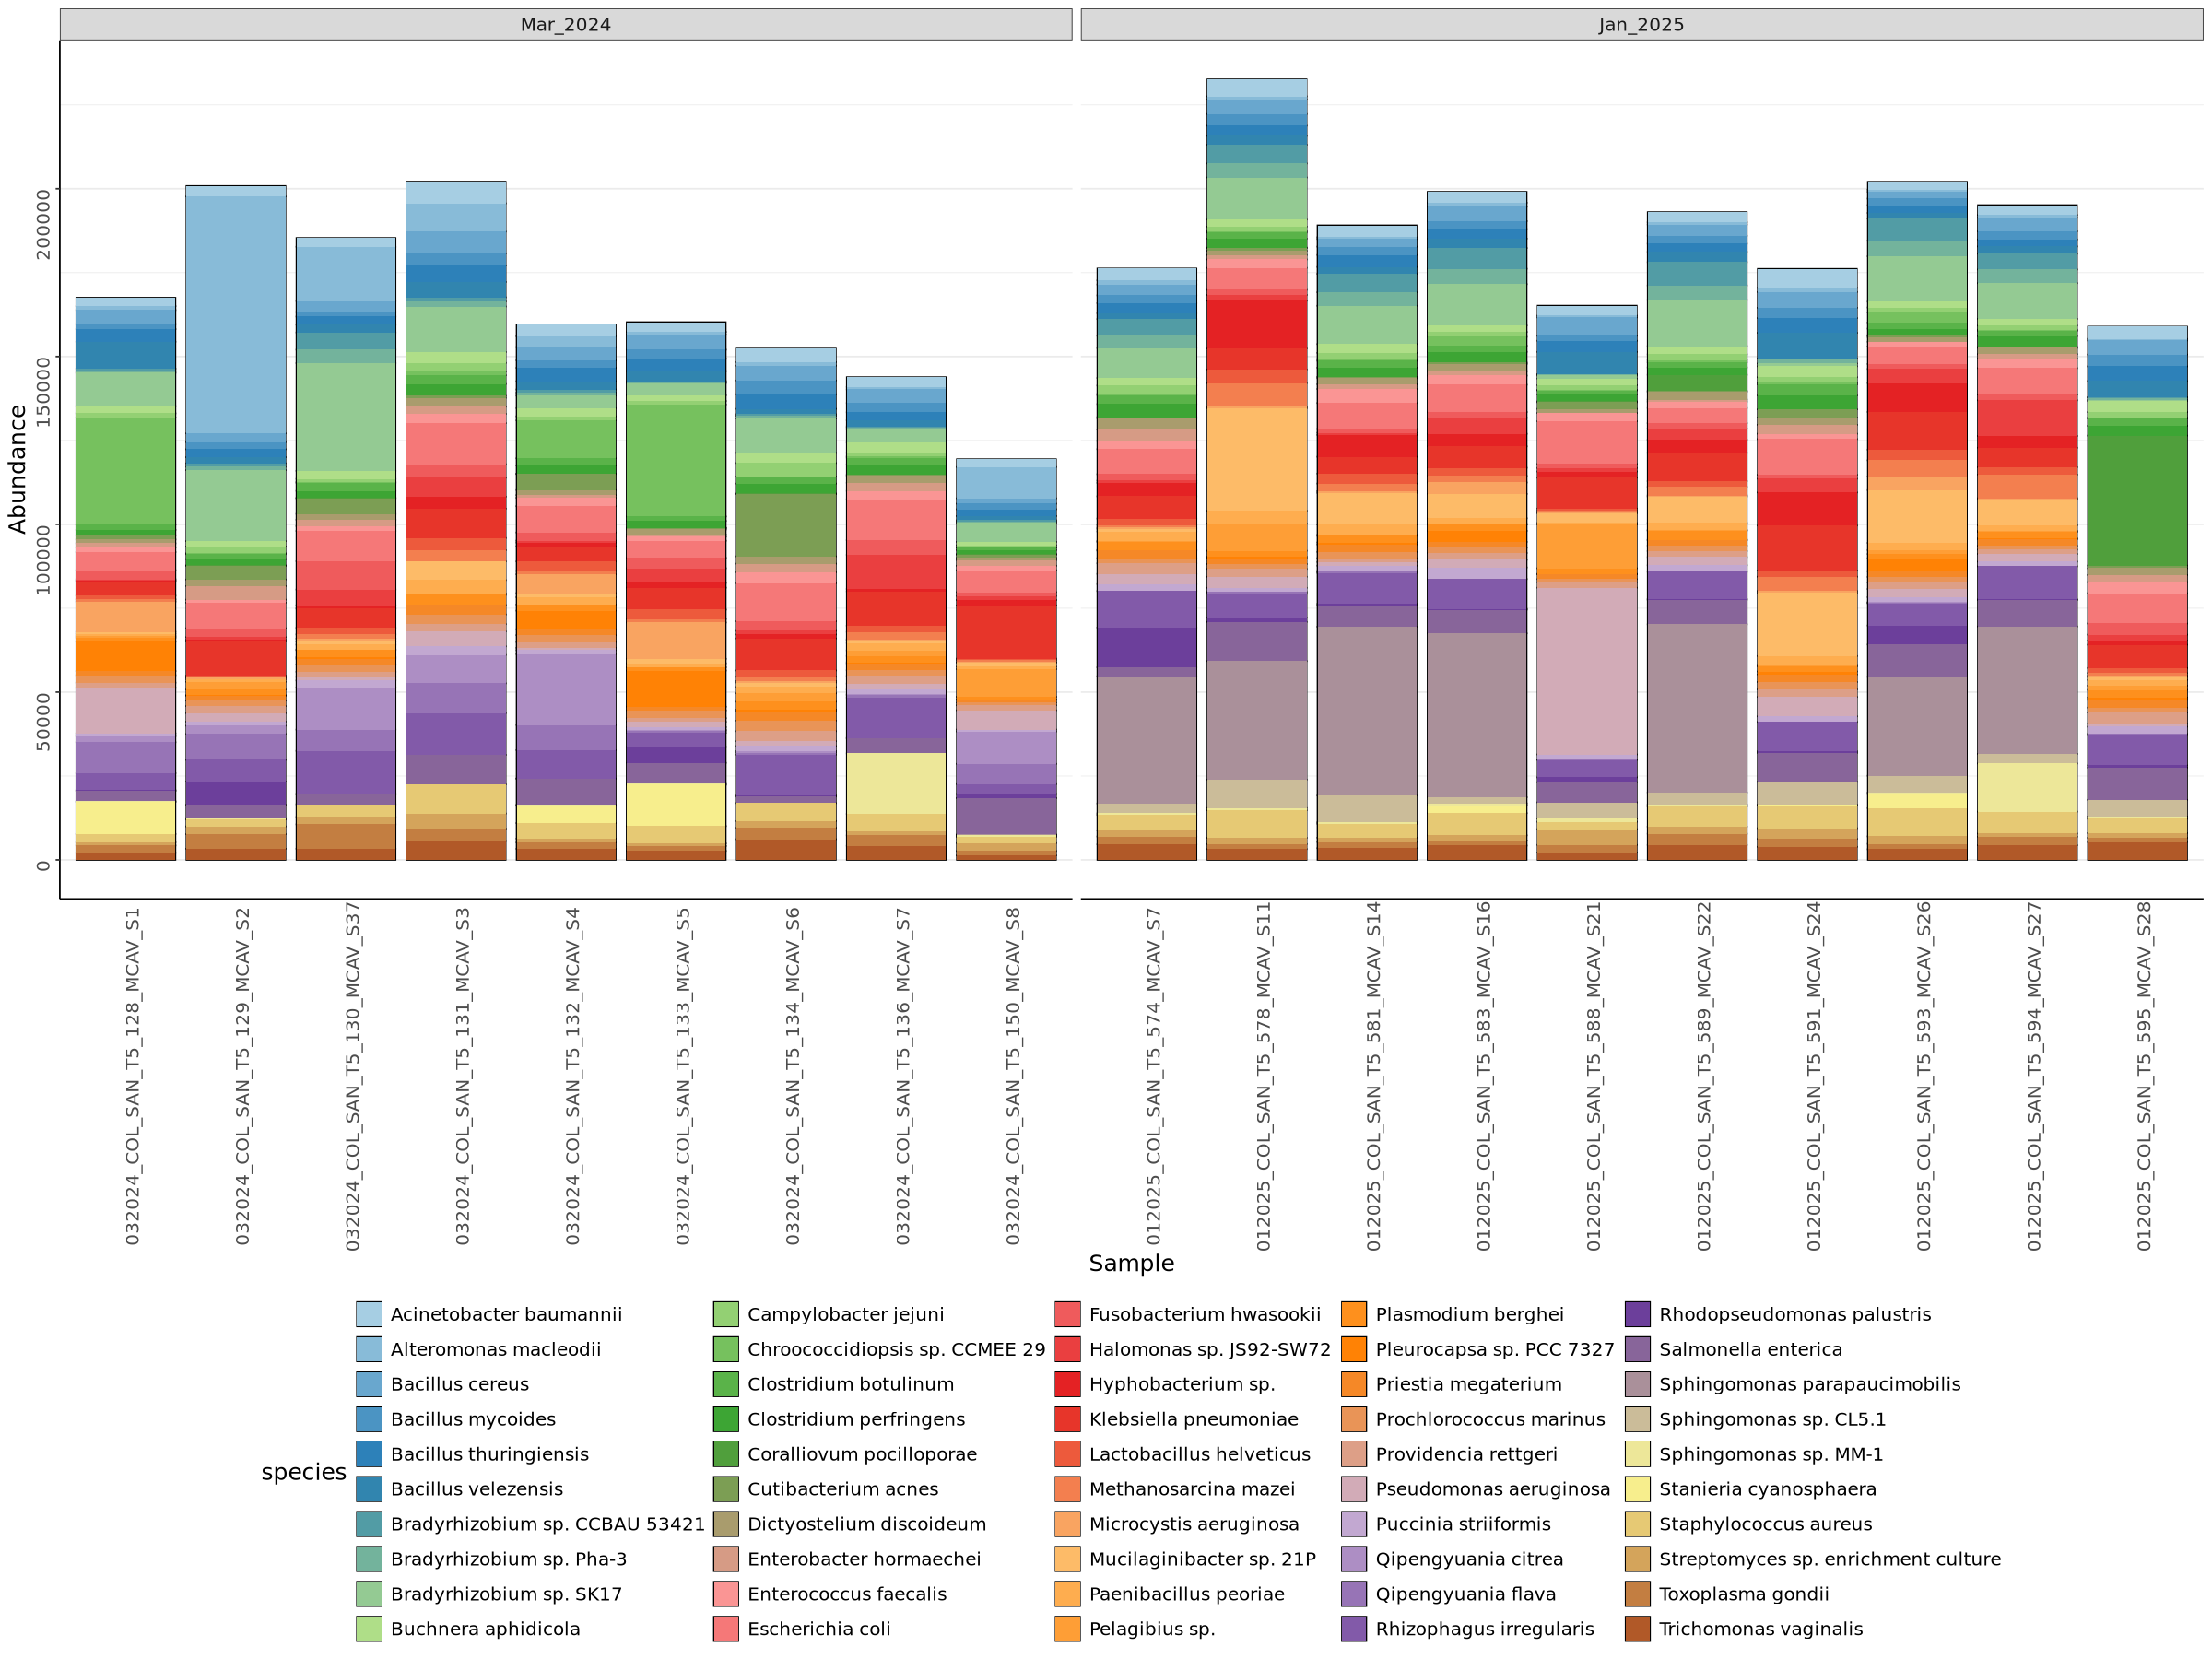

In [143]:
# bar plot of top 50 abundant taxa in MCAV samples
mcav_50_bar<-plot_bar(COL_mcav_50,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_50_bar

In [144]:
ggsave(filename = "mcav_top_50_species_bar.png", plot = mcav_50_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

In [145]:
COL_mcav_50_rel <- transform_sample_counts(COL_mcav_50, function(x) x / sum(x))

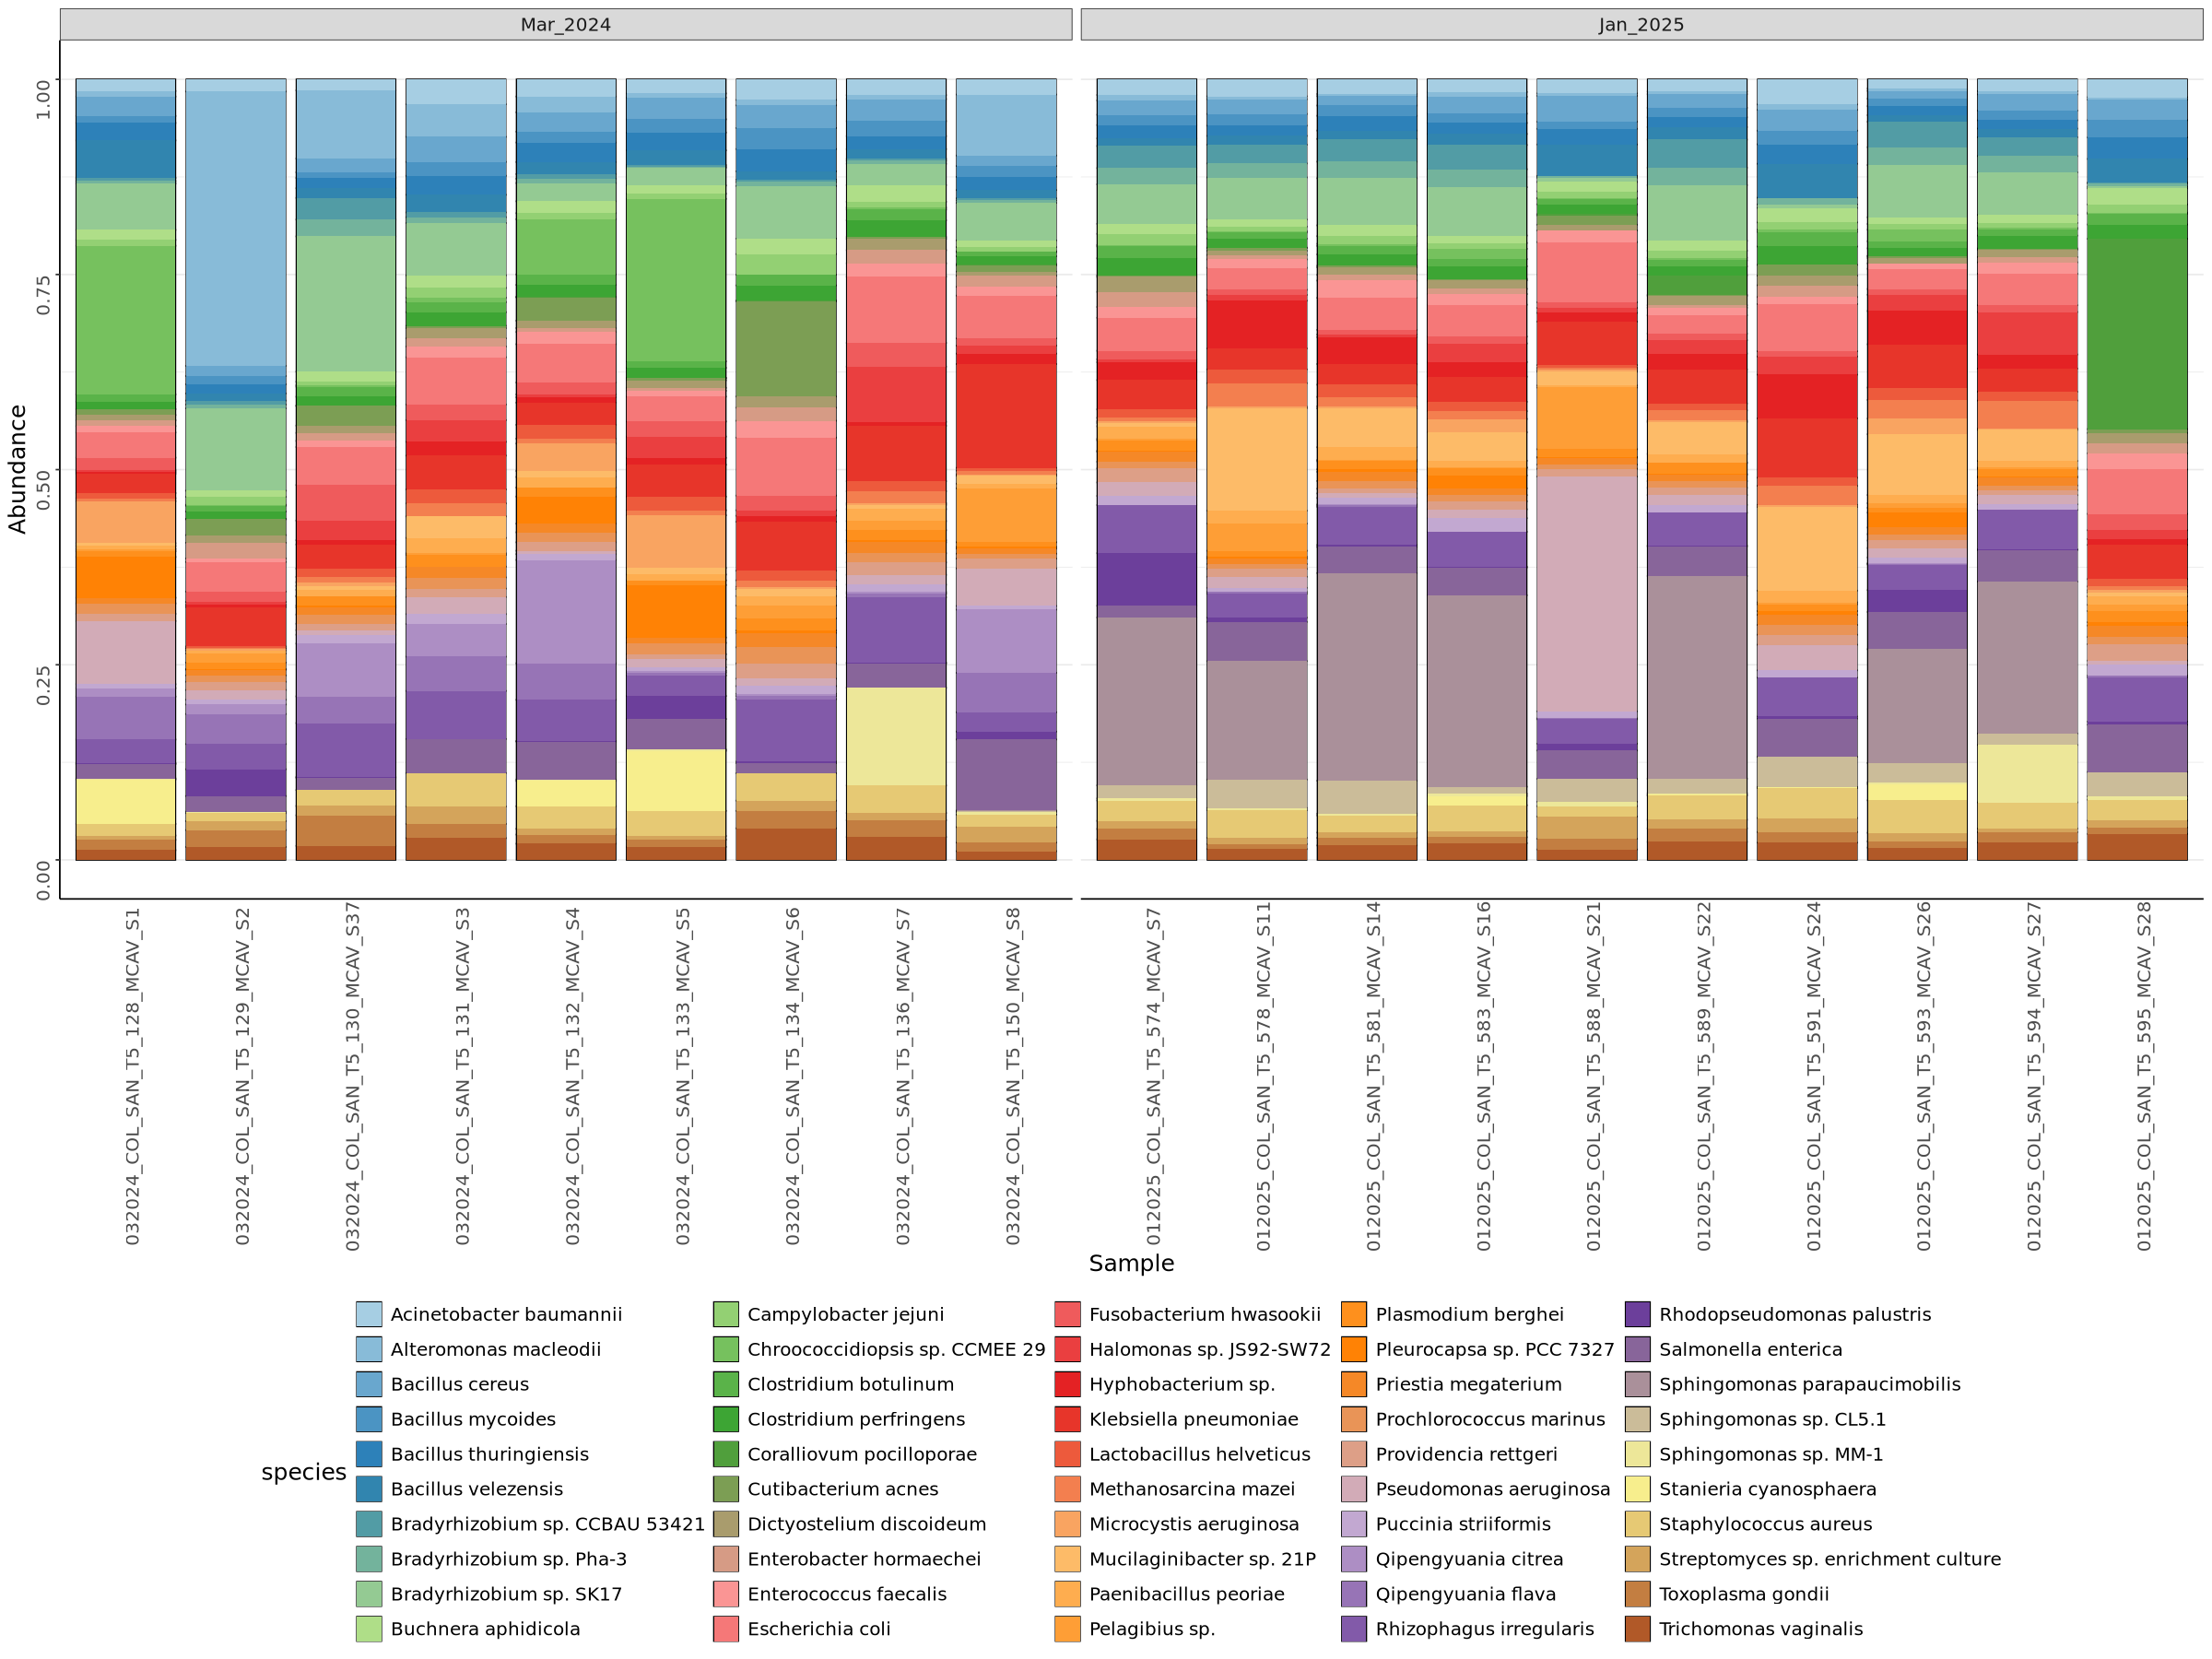

In [146]:
# bar plot of top 50 abundant taxa in OFAV samples
mcav_50_rel_bar<-plot_bar(COL_mcav_50_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_50_rel_bar

In [147]:
ggsave(filename = "mcav_top_50_species_rel_bar.png", plot = mcav_50_rel_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

### DLAB

In [148]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_dlab = read.csv('dlab_otu_table_ready.csv')
head(otu_dlab)

,X,X032024_COL_SAN_T5_146_DLAB_S12,X032024_COL_SAN_T5_148_DLAB_S13,X032024_COL_SAN_T5_149_DLAB_S14,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_143_DLAB_S40,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_579_DLAB_S12,X012025_COL_SAN_T5_586_DLAB_S19
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,7401.3970,8834.8310,17050.84794,6373.22015,6958.2438,7260.23535,6016.96722,16490.57325,6464.1774,36273.272,85450.5399,7847.6396,6382.13313,7971.9792
2,2057741,12537.9242,18014.5835,14635.25211,7516.42935,5705.3558,22184.75081,40049.21551,22055.19826,583.6156,2099.407,542.5778,2104.3470,490.48593,158.4887
3,28213,0.0000,0.0000,0.00000,0.00000,0.0000,0.00000,0.00000,176.51950,253.7459,695.408,699.1606,5597.2767,440.08026,221.8841
4,2653203,0.0000,0.0000,92.09016,0.00000,0.0000,68.23867,21.51711,108.34645,43434.9586,111565.195,109036.2872,5101.9678,16282.96967,4601.4539
5,1173583,112.8907,108.9226,162.92875,88.99233,114.5113,84.40046,43.03423,54.78191,0.0000,0.000,0.0000,20.0414,29.08019,0.0000
6,588596,9200.5927,7672.9902,8621.05606,8296.82366,8945.3512,4002.73673,4903.94565,3344.13146,3977.4674,1502.872,2010.0868,1212.5047,1568.39177,5399.1801


In [149]:
# rename first col as otu
names(otu_dlab)[1] <- "otu"

#remove X's from headers
names(otu_dlab) <- sub("^X", "", names(otu_dlab))
otu_table_dlab=as.data.frame(otu_dlab)

# make the index the otus
row.names(otu_table_dlab) <- otu_table_dlab$otu
otu_table_dlab$otu <- NULL
head(otu_table_dlab)

,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_149_DLAB_S14,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7401.3970,8834.8310,17050.84794,6373.22015,6958.2438,7260.23535,6016.96722,16490.57325,6464.1774,36273.272,85450.5399,7847.6396,6382.13313,7971.9792
2057741,12537.9242,18014.5835,14635.25211,7516.42935,5705.3558,22184.75081,40049.21551,22055.19826,583.6156,2099.407,542.5778,2104.3470,490.48593,158.4887
28213,0.0000,0.0000,0.00000,0.00000,0.0000,0.00000,0.00000,176.51950,253.7459,695.408,699.1606,5597.2767,440.08026,221.8841
2653203,0.0000,0.0000,92.09016,0.00000,0.0000,68.23867,21.51711,108.34645,43434.9586,111565.195,109036.2872,5101.9678,16282.96967,4601.4539
1173583,112.8907,108.9226,162.92875,88.99233,114.5113,84.40046,43.03423,54.78191,0.0000,0.000,0.0000,20.0414,29.08019,0.0000
588596,9200.5927,7672.9902,8621.05606,8296.82366,8945.3512,4002.73673,4903.94565,3344.13146,3977.4674,1502.872,2010.0868,1212.5047,1568.39177,5399.1801


In [150]:
# sort by most abundant OTUs
otus_sorted_dlab <- otu_table_dlab[order(rowSums(otu_table_dlab), decreasing = TRUE), ]
head(otus_sorted_dlab)

,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_149_DLAB_S14,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2653203,0.0000,0.0000,92.09016,0.0000,0.0000,68.23867,21.51711,108.3465,43434.9586,111565.1953,109036.2872,5101.9678,16282.9697,4601.4539
562,7401.3970,8834.8310,17050.84794,6373.2202,6958.2438,7260.23535,6016.96722,16490.5733,6464.1774,36273.2723,85450.5399,7847.6396,6382.1331,7971.9792
1747,1397.0225,508.3053,1147.58511,547.6451,397.4215,2848.06660,6885.47614,4647.9410,11704.0307,34809.9493,82737.6509,160.3312,10269.1857,7750.0951
2057741,12537.9242,18014.5835,14635.25211,7516.4294,5705.3558,22184.75081,40049.21551,22055.1983,583.6156,2099.4071,542.5778,2104.3470,490.4859,158.4887
28108,564.4535,768.5093,3017.72381,44078.5871,7335.4574,368.12967,18584.91729,1134.5943,1655.6922,428.4504,1485.7164,257.6751,597.1133,1204.5138
588596,9200.5927,7672.9902,8621.05606,8296.8237,8945.3512,4002.73673,4903.94565,3344.1315,3977.4674,1502.8723,2010.0868,1212.5047,1568.3918,5399.1801


In [151]:
# Convert to matrix
otus_dlab=as.matrix(otus_sorted_dlab)
head(otus_dlab)

,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_149_DLAB_S14,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19
2653203,0.0000,0.0000,92.09016,0.0000,0.0000,68.23867,21.51711,108.3465,43434.9586,111565.1953,109036.2872,5101.9678,16282.9697,4601.4539
562,7401.3970,8834.8310,17050.84794,6373.2202,6958.2438,7260.23535,6016.96722,16490.5733,6464.1774,36273.2723,85450.5399,7847.6396,6382.1331,7971.9792
1747,1397.0225,508.3053,1147.58511,547.6451,397.4215,2848.06660,6885.47614,4647.9410,11704.0307,34809.9493,82737.6509,160.3312,10269.1857,7750.0951
2057741,12537.9242,18014.5835,14635.25211,7516.4294,5705.3558,22184.75081,40049.21551,22055.1983,583.6156,2099.4071,542.5778,2104.3470,490.4859,158.4887
28108,564.4535,768.5093,3017.72381,44078.5871,7335.4574,368.12967,18584.91729,1134.5943,1655.6922,428.4504,1485.7164,257.6751,597.1133,1204.5138
588596,9200.5927,7672.9902,8621.05606,8296.8237,8945.3512,4002.73673,4903.94565,3344.1315,3977.4674,1502.8723,2010.0868,1212.5047,1568.3918,5399.1801


In [174]:
#filter metadata for dlabs only
metadata_dlab <- metadata[metadata$Species=="DLAB",]
head(metadata_dlab)
dim(metadata_dlab)

,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_146_DLAB_S12,ELARBOL,3/7/24,Mar_2024,83,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_148_DLAB_S13,ELARBOL,3/7/24,Mar_2024,86,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_149_DLAB_S14,ELARBOL,3/7/24,Mar_2024,87,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_158_DLAB_S15,ELARBOL,3/7/24,Mar_2024,88,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_159_DLAB_S16,ELARBOL,3/7/24,Mar_2024,94,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_143_DLAB_S40,ELARBOL,3/7/24,Mar_2024,81,DLAB,Healthy,Healthy,,,


[1] 14 10

In [153]:
# classify phyloseq objects 
OTU_D=otu_table((otus_dlab), taxa_are_rows = TRUE)
TAX_D=tax_table(taxonomy)
SAMP_D=sample_data(metadata_dlab)

In [154]:
# Create phyloseq object
COL_dlab = phyloseq(OTU_D, SAMP_D, TAX_D)
COL_dlab

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12742 taxa and 14 samples ]
sample_data() Sample Data:       [ 14 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 12742 taxa by 1 taxonomic ranks ]

In [155]:
COL_dlab_10 = prune_taxa(names(sort(taxa_sums(COL_dlab),TRUE)[1:10]), COL_dlab)

In [156]:
#order of facets
sample_data(COL_dlab_10)$Year_d <- factor(sample_data(COL_dlab_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

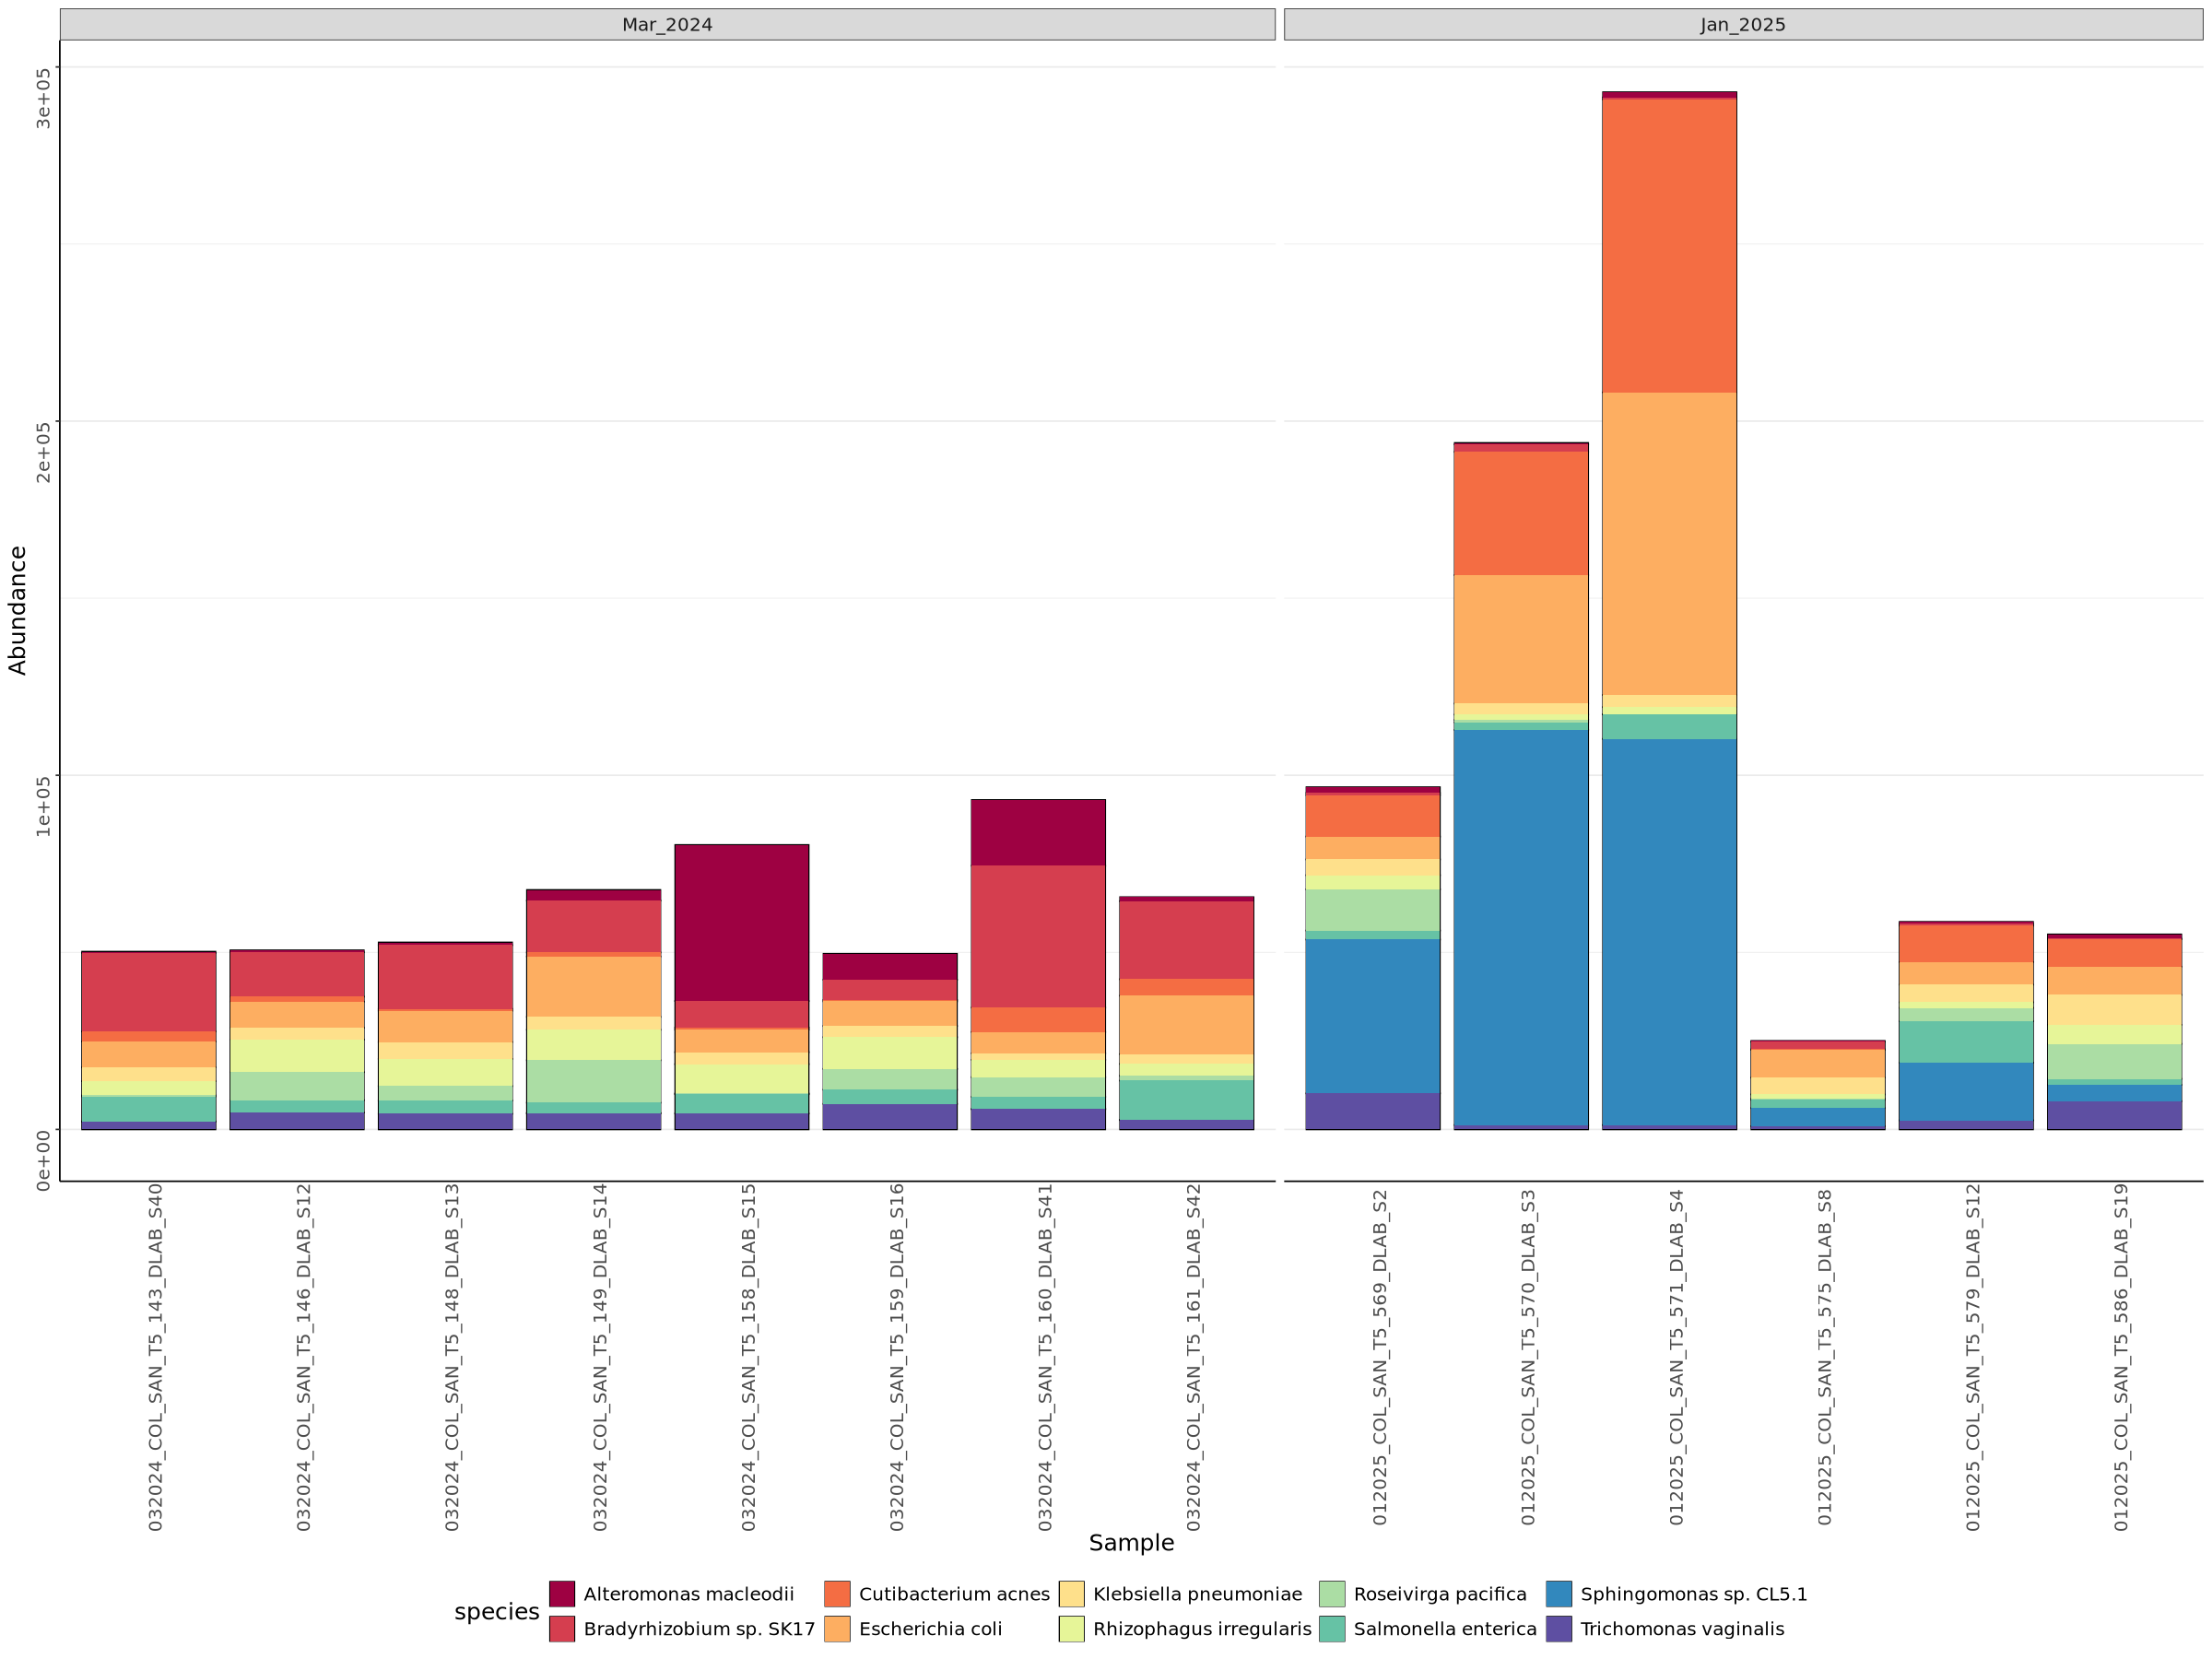

In [157]:
# bar plot of top 10 abundant taxa in MCAV samples
dlab_10_bar<-plot_bar(COL_dlab_10,fill='species')+
facet_grid(~Year_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
dlab_10_bar

In [158]:
ggsave(filename = "dlab_top_10_species_bar.png", plot = dlab_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

**maybe split up by year? 032024 samples might look different than 012025** 

In [163]:
#taxonomy file should be ready to go (same from above)
#read in otu table
otu_dlab_24 = read.csv('dlab_032024_otu_table_ready.csv')
head(otu_dlab_24)

,X,X032024_COL_SAN_T5_146_DLAB_S12,X032024_COL_SAN_T5_148_DLAB_S13,X032024_COL_SAN_T5_149_DLAB_S14,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_143_DLAB_S40,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,7401.3970,8834.8310,17050.84794,6373.22015,6958.2438,7260.23535,6016.96722,16490.57325
2,2057741,12537.9242,18014.5835,14635.25211,7516.42935,5705.3558,22184.75081,40049.21551,22055.19826
3,28213,0.0000,0.0000,0.00000,0.00000,0.0000,0.00000,0.00000,176.51950
4,2653203,0.0000,0.0000,92.09016,0.00000,0.0000,68.23867,21.51711,108.34645
5,1173583,112.8907,108.9226,162.92875,88.99233,114.5113,84.40046,43.03423,54.78191
6,588596,9200.5927,7672.9902,8621.05606,8296.82366,8945.3512,4002.73673,4903.94565,3344.13146


In [164]:
# rename first col as otu
names(otu_dlab_24)[1] <- "otu"

#remove X's from headers
names(otu_dlab_24) <- sub("^X", "", names(otu_dlab_24))
otu_table_dlab_24=as.data.frame(otu_dlab_24)

# make the index the otus
row.names(otu_table_dlab_24) <- otu_table_dlab_24$otu
otu_table_dlab_24$otu <- NULL
head(otu_table_dlab_24)

,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_149_DLAB_S14,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7401.3970,8834.8310,17050.84794,6373.22015,6958.2438,7260.23535,6016.96722,16490.57325
2057741,12537.9242,18014.5835,14635.25211,7516.42935,5705.3558,22184.75081,40049.21551,22055.19826
28213,0.0000,0.0000,0.00000,0.00000,0.0000,0.00000,0.00000,176.51950
2653203,0.0000,0.0000,92.09016,0.00000,0.0000,68.23867,21.51711,108.34645
1173583,112.8907,108.9226,162.92875,88.99233,114.5113,84.40046,43.03423,54.78191
588596,9200.5927,7672.9902,8621.05606,8296.82366,8945.3512,4002.73673,4903.94565,3344.13146


In [165]:
# sort by most abundant OTUs
otus_sorted_dlab_24 <- otu_table_dlab_24[order(rowSums(otu_table_dlab_24), decreasing = TRUE), ]
head(otus_sorted_dlab_24)

,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_149_DLAB_S14,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2057741,12537.9242,18014.5835,14635.25211,7516.4294,5705.3558,22184.7508,40049.2155,22055.198
562,7401.3970,8834.8310,17050.84794,6373.2202,6958.2438,7260.2354,6016.9672,16490.573
28108,564.4535,768.5093,3017.72381,44078.5871,7335.4574,368.1297,18584.9173,1134.594
588596,9200.5927,7672.9902,8621.05606,8296.8237,8945.3512,4002.7367,4903.9457,3344.131
911045,169.3361,169.4351,99.17402,198.5214,215.5506,145.4561,183.8735,42473.026
28901,3492.5563,3751.7776,2918.54979,5442.2234,4001.1586,7030.3788,3468.1674,11051.338


In [166]:
# Convert to matrix
otus_dlab_24=as.matrix(otus_sorted_dlab_24)
head(otus_dlab_24)

,032024_COL_SAN_T5_146_DLAB_S12,032024_COL_SAN_T5_148_DLAB_S13,032024_COL_SAN_T5_149_DLAB_S14,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_143_DLAB_S40,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42
2057741,12537.9242,18014.5835,14635.25211,7516.4294,5705.3558,22184.7508,40049.2155,22055.198
562,7401.3970,8834.8310,17050.84794,6373.2202,6958.2438,7260.2354,6016.9672,16490.573
28108,564.4535,768.5093,3017.72381,44078.5871,7335.4574,368.1297,18584.9173,1134.594
588596,9200.5927,7672.9902,8621.05606,8296.8237,8945.3512,4002.7367,4903.9457,3344.131
911045,169.3361,169.4351,99.17402,198.5214,215.5506,145.4561,183.8735,42473.026
28901,3492.5563,3751.7776,2918.54979,5442.2234,4001.1586,7030.3788,3468.1674,11051.338


In [167]:
#filter metadata for 032024 dlabs only
metadata_dlab_24 <- metadata_dlab[metadata_dlab$Year=="Mar_2024",]
head(metadata_dlab_24)
dim(metadata_dlab_24)

,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_146_DLAB_S12,ELARBOL,3/7/24,Mar_2024,83,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_148_DLAB_S13,ELARBOL,3/7/24,Mar_2024,86,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_149_DLAB_S14,ELARBOL,3/7/24,Mar_2024,87,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_158_DLAB_S15,ELARBOL,3/7/24,Mar_2024,88,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_159_DLAB_S16,ELARBOL,3/7/24,Mar_2024,94,DLAB,Healthy,Healthy,,,
032024_COL_SAN_T5_143_DLAB_S40,ELARBOL,3/7/24,Mar_2024,81,DLAB,Healthy,Healthy,,,


[1]  8 10

In [168]:
# classify phyloseq objects 
OTU_D_24=otu_table((otus_dlab_24), taxa_are_rows = TRUE)
TAX_D_24=tax_table(taxonomy)
SAMP_D_24=sample_data(metadata_dlab_24)

In [169]:
# Create phyloseq object
COL_dlab_24 = phyloseq(OTU_D_24, SAMP_D_24, TAX_D_24)
COL_dlab_24

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12742 taxa and 8 samples ]
sample_data() Sample Data:       [ 8 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 12742 taxa by 1 taxonomic ranks ]

In [170]:
COL_dlab_24_10 = prune_taxa(names(sort(taxa_sums(COL_dlab_24),TRUE)[1:10]), COL_dlab_24)

In [171]:
#order of facets
sample_data(COL_dlab_24_10)$Year_d <- factor(sample_data(COL_dlab_24_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

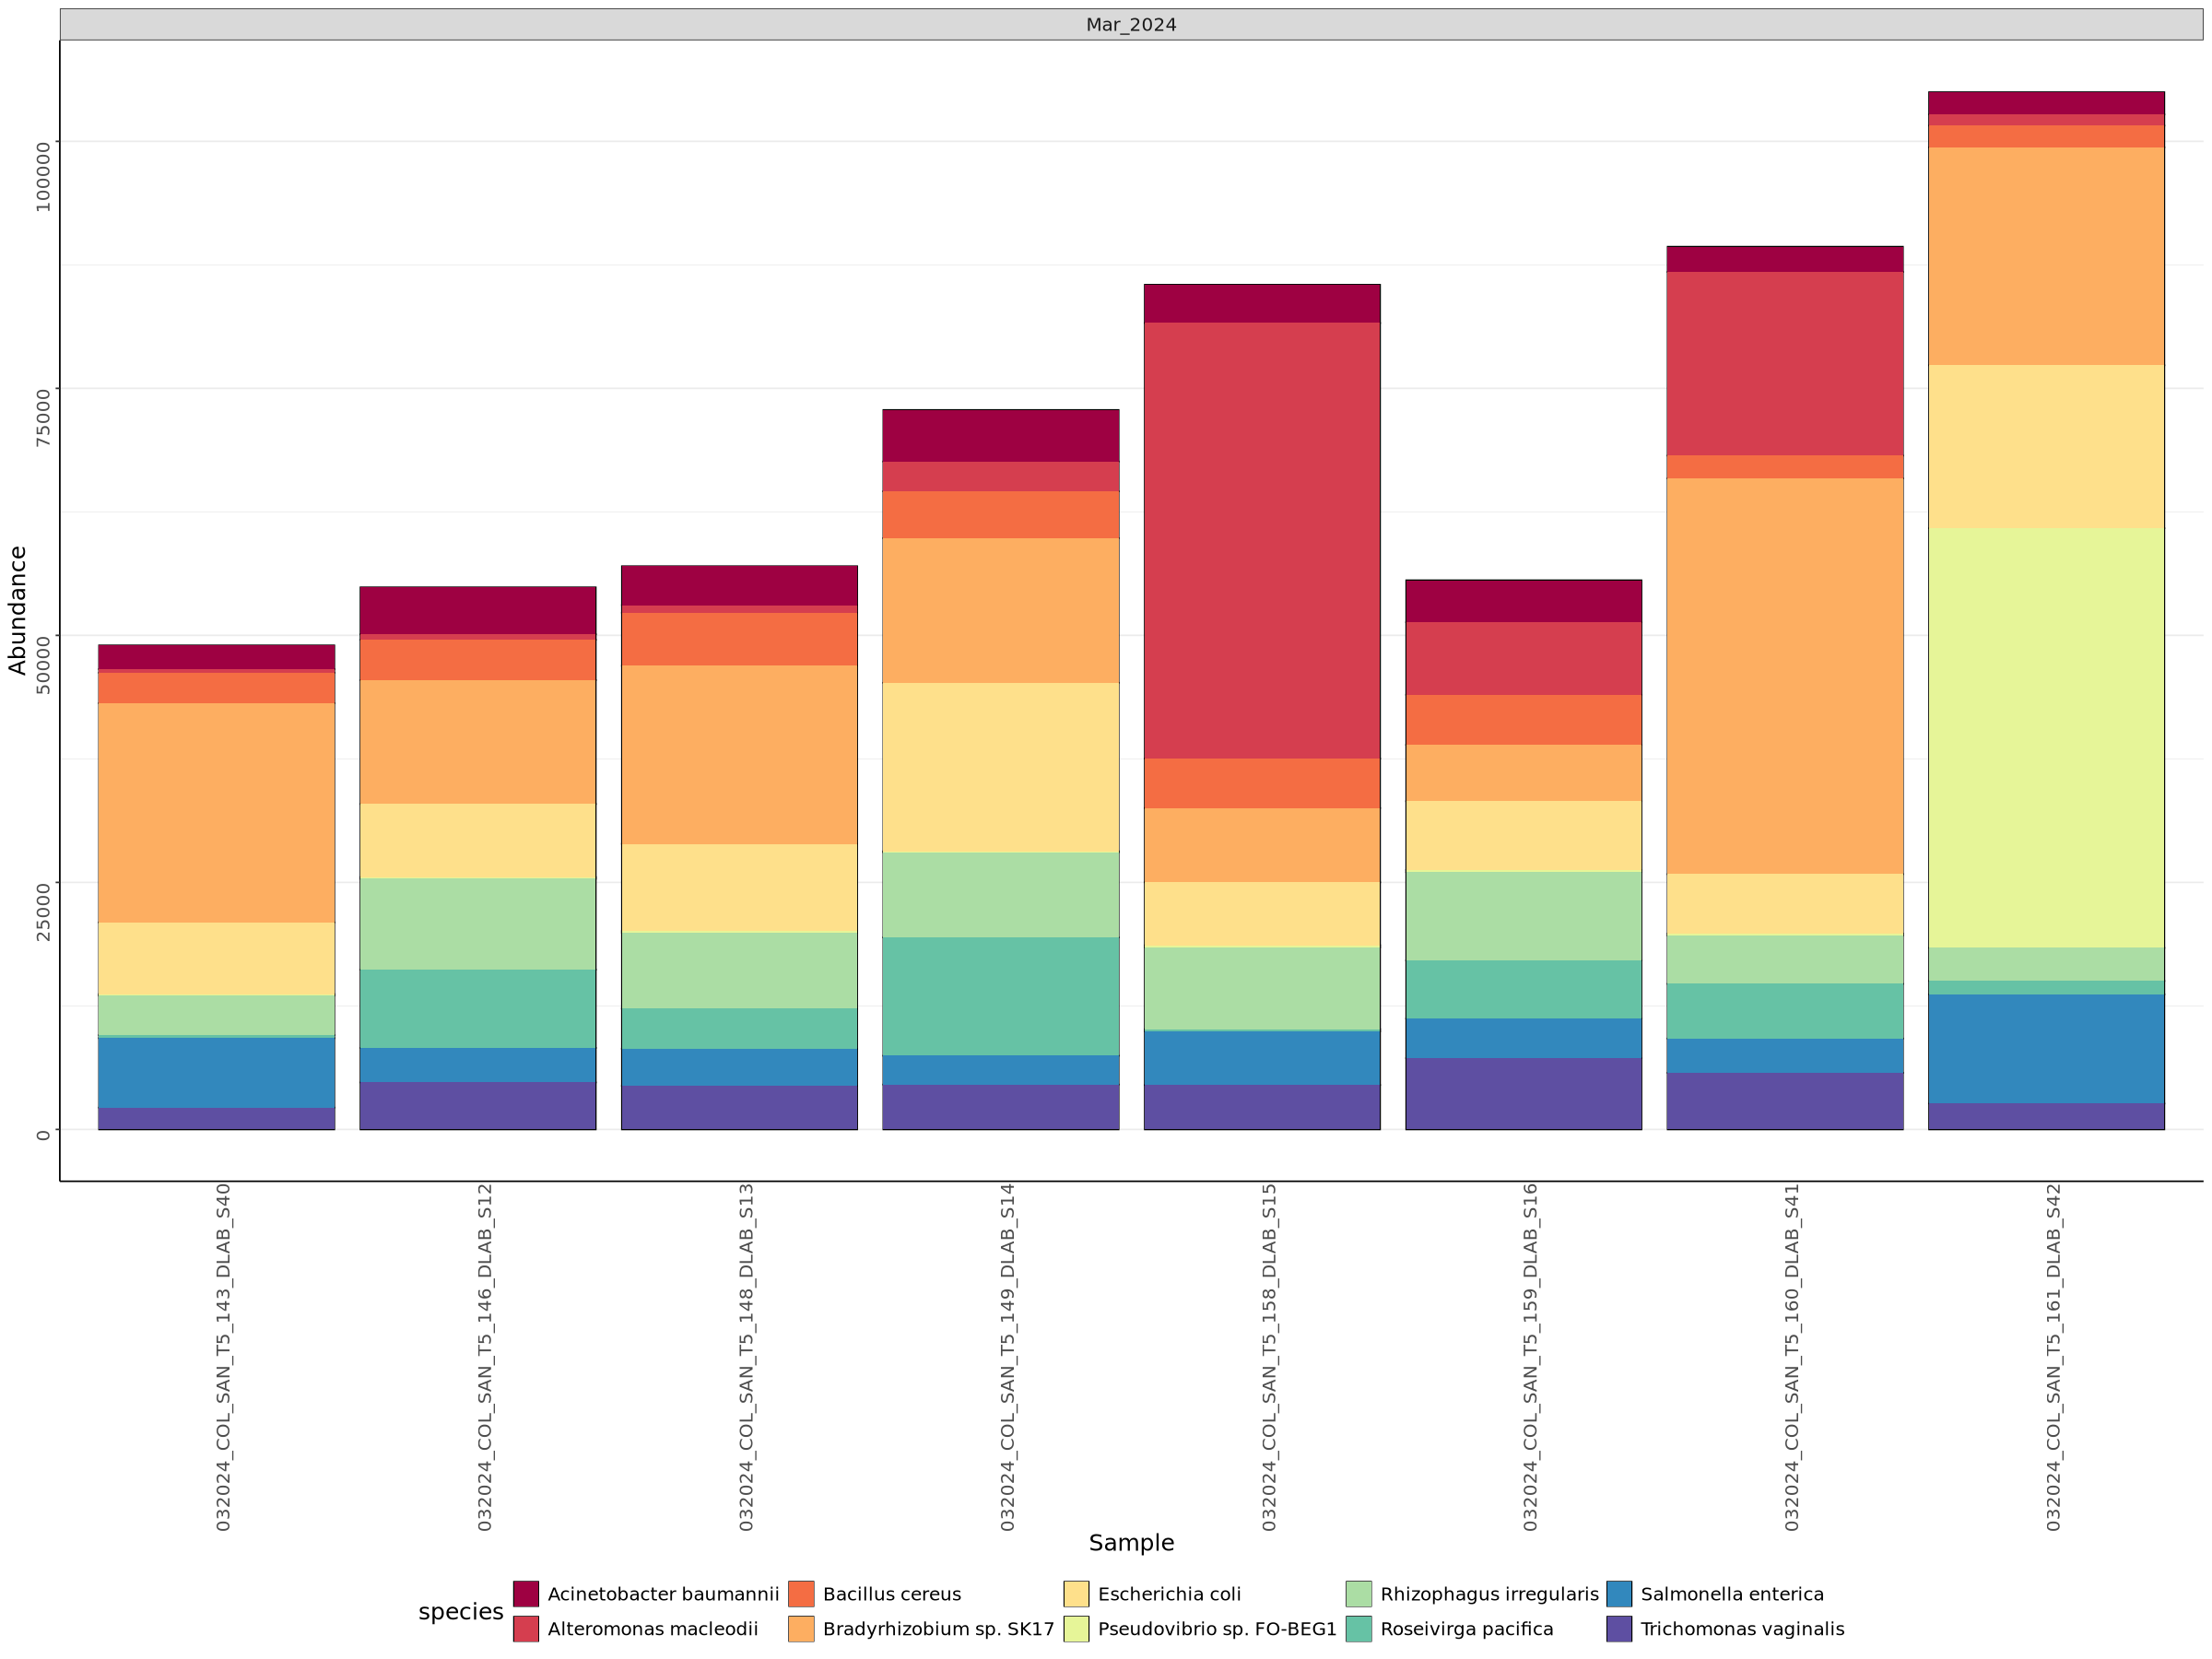

In [172]:
# bar plot of top 10 abundant taxa in MCAV samples
dlab_24_10_bar<-plot_bar(COL_dlab_24_10,fill='species')+
facet_grid(~Year_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
dlab_24_10_bar

In [173]:
ggsave(filename = "dlab_032024_top_10_species_bar.png", plot = dlab_24_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)

### PSTR

In [175]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_pstr = read.csv('pstr_otu_table_ready.csv')
head(otu_pstr)

,X,X032024_COL_SAN_T5_144_PSTR_S9,X032024_COL_SAN_T5_147_PSTR_S10,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_162_PSTR_S39,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_576_PSTR_S9,X012025_COL_SAN_T5_577_PSTR_S10,X012025_COL_SAN_T5_582_PSTR_S15,X012025_COL_SAN_T5_587_PSTR_S20,X012025_COL_SAN_T5_590_PSTR_S23,X012025_COL_SAN_T5_592_PSTR_S25
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,562,7073.776,4880.83392,5057.2861,6516.702,3804.46965,4122.8633,4316.62572,4365.2913,4266.0476,7695.208,5096.14195,4793.805
2,2057741,3145.898,27086.01817,6800.4834,50448.265,106517.07270,1538.9399,216.44098,408.0021,510.6444,2431.732,172.07140,11210.128
3,28213,0.000,0.00000,7834.3179,0.000,0.00000,338.4881,64.01775,142.6349,152.6280,9617.571,29.46428,17499.437
4,2653203,0.000,58.72661,138.7397,0.000,26.25165,56480.2752,10715.35268,19866.0559,3640.4611,3154.057,865.07127,2962.326
5,1173583,71600.633,12202.08479,75586.2872,7586.031,6389.24733,4949.4039,76973.72833,36809.7549,5439.9644,64934.430,6128.57033,31122.857
6,588596,10300.568,6404.46322,7042.1590,5462.872,4083.14099,2578.0195,8127.20633,7247.8431,5528.5264,8800.279,5506.28473,8661.627


In [176]:
# rename first col as otu
names(otu_pstr)[1] <- "otu"

#remove X's from headers
names(otu_pstr) <- sub("^X", "", names(otu_pstr))
otu_table_pstr=as.data.frame(otu_pstr)

# make the index the otus
row.names(otu_table_pstr) <- otu_table_pstr$otu
otu_table_pstr$otu <- NULL
head(otu_table_pstr)

,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
562,7073.776,4880.83392,5057.2861,6516.702,3804.46965,4122.8633,4316.62572,4365.2913,4266.0476,7695.208,5096.14195,4793.805
2057741,3145.898,27086.01817,6800.4834,50448.265,106517.07270,1538.9399,216.44098,408.0021,510.6444,2431.732,172.07140,11210.128
28213,0.000,0.00000,7834.3179,0.000,0.00000,338.4881,64.01775,142.6349,152.6280,9617.571,29.46428,17499.437
2653203,0.000,58.72661,138.7397,0.000,26.25165,56480.2752,10715.35268,19866.0559,3640.4611,3154.057,865.07127,2962.326
1173583,71600.633,12202.08479,75586.2872,7586.031,6389.24733,4949.4039,76973.72833,36809.7549,5439.9644,64934.430,6128.57033,31122.857
588596,10300.568,6404.46322,7042.1590,5462.872,4083.14099,2578.0195,8127.20633,7247.8431,5528.5264,8800.279,5506.28473,8661.627


In [177]:
# sort by most abundant OTUs
otus_sorted_pstr <- otu_table_pstr[order(rowSums(otu_table_pstr), decreasing = TRUE), ]
head(otus_sorted_pstr)

,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1173583,71600.633,12202.08479,75586.2872,7586.031,6389.24733,4949.404,76973.728,36809.7549,5439.9644,64934.4296,6128.5703,31122.85662
2057741,3145.898,27086.01817,6800.4834,50448.265,106517.07270,1538.940,216.441,408.0021,510.6444,2431.7317,172.0714,11210.12845
2653203,0.000,58.72661,138.7397,0.000,26.25165,56480.275,10715.353,19866.0559,3640.4611,3154.0567,865.0713,2962.32561
588596,10300.568,6404.46322,7042.1590,5462.872,4083.14099,2578.020,8127.206,7247.8431,5528.5264,8800.2786,5506.2847,8661.62703
562,7073.776,4880.83392,5057.2861,6516.702,3804.46965,4122.863,4316.626,4365.2913,4266.0476,7695.2076,5096.1419,4793.80493
1747,611.203,1693.28396,257.3398,12692.460,9424.34174,22257.558,472.512,2905.7714,6868.2613,385.6237,525.6428,81.94538


In [178]:
# Convert to matrix
otus_pstr=as.matrix(otus_sorted_pstr)
head(otus_pstr)

,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
1173583,71600.633,12202.08479,75586.2872,7586.031,6389.24733,4949.404,76973.728,36809.7549,5439.9644,64934.4296,6128.5703,31122.85662
2057741,3145.898,27086.01817,6800.4834,50448.265,106517.07270,1538.940,216.441,408.0021,510.6444,2431.7317,172.0714,11210.12845
2653203,0.000,58.72661,138.7397,0.000,26.25165,56480.275,10715.353,19866.0559,3640.4611,3154.0567,865.0713,2962.32561
588596,10300.568,6404.46322,7042.1590,5462.872,4083.14099,2578.020,8127.206,7247.8431,5528.5264,8800.2786,5506.2847,8661.62703
562,7073.776,4880.83392,5057.2861,6516.702,3804.46965,4122.863,4316.626,4365.2913,4266.0476,7695.2076,5096.1419,4793.80493
1747,611.203,1693.28396,257.3398,12692.460,9424.34174,22257.558,472.512,2905.7714,6868.2613,385.6237,525.6428,81.94538


In [179]:
#filter metadata for dlabs only
metadata_pstr <- metadata[metadata$Species=="PSTR",]
head(metadata_pstr)
dim(metadata_pstr)

,Transect,CollectionDate,Year,Tag_num,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_144_PSTR_S9,ELARBOL,3/7/24,Mar_2024,82,PSTR,Healthy,Healthy,,,
032024_COL_SAN_T5_147_PSTR_S10,ELARBOL,3/7/24,Mar_2024,85,PSTR,Healthy,Healthy,,,
032024_COL_SAN_T5_163_PSTR_S11c,ELARBOL,3/7/24,Mar_2024,97,PSTR,Healthy,Healthy,,,
032024_COL_SAN_T5_154_PSTR_S38,ELARBOL,3/7/24,Mar_2024,12,PSTR,Healthy,Healthy,,,
032024_COL_SAN_T5_162_PSTR_S39,ELARBOL,3/7/24,Mar_2024,96,PSTR,Healthy,Healthy,,,
012025_COL_SAN_T5_573_PSTR_S6,ELARBOL,1/17/25,Jan_2025,96,PSTR,Healthy,Healthy,,,


[1] 12 10

In [180]:
# classify phyloseq objects 
OTU_P=otu_table((otus_pstr), taxa_are_rows = TRUE)
TAX_P=tax_table(taxonomy)
SAMP_P=sample_data(metadata_pstr)

In [181]:
# Create phyloseq object
COL_pstr = phyloseq(OTU_P, SAMP_P, TAX_P)
COL_pstr

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 12742 taxa and 12 samples ]
sample_data() Sample Data:       [ 12 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 12742 taxa by 1 taxonomic ranks ]

In [182]:
COL_pstr_10 = prune_taxa(names(sort(taxa_sums(COL_pstr),TRUE)[1:10]), COL_pstr)

In [183]:
#order of facets
sample_data(COL_pstr_10)$Year_p <- factor(sample_data(COL_pstr_10)$Year, 
                                      levels = c("Mar_2024", "Jan_2025"))

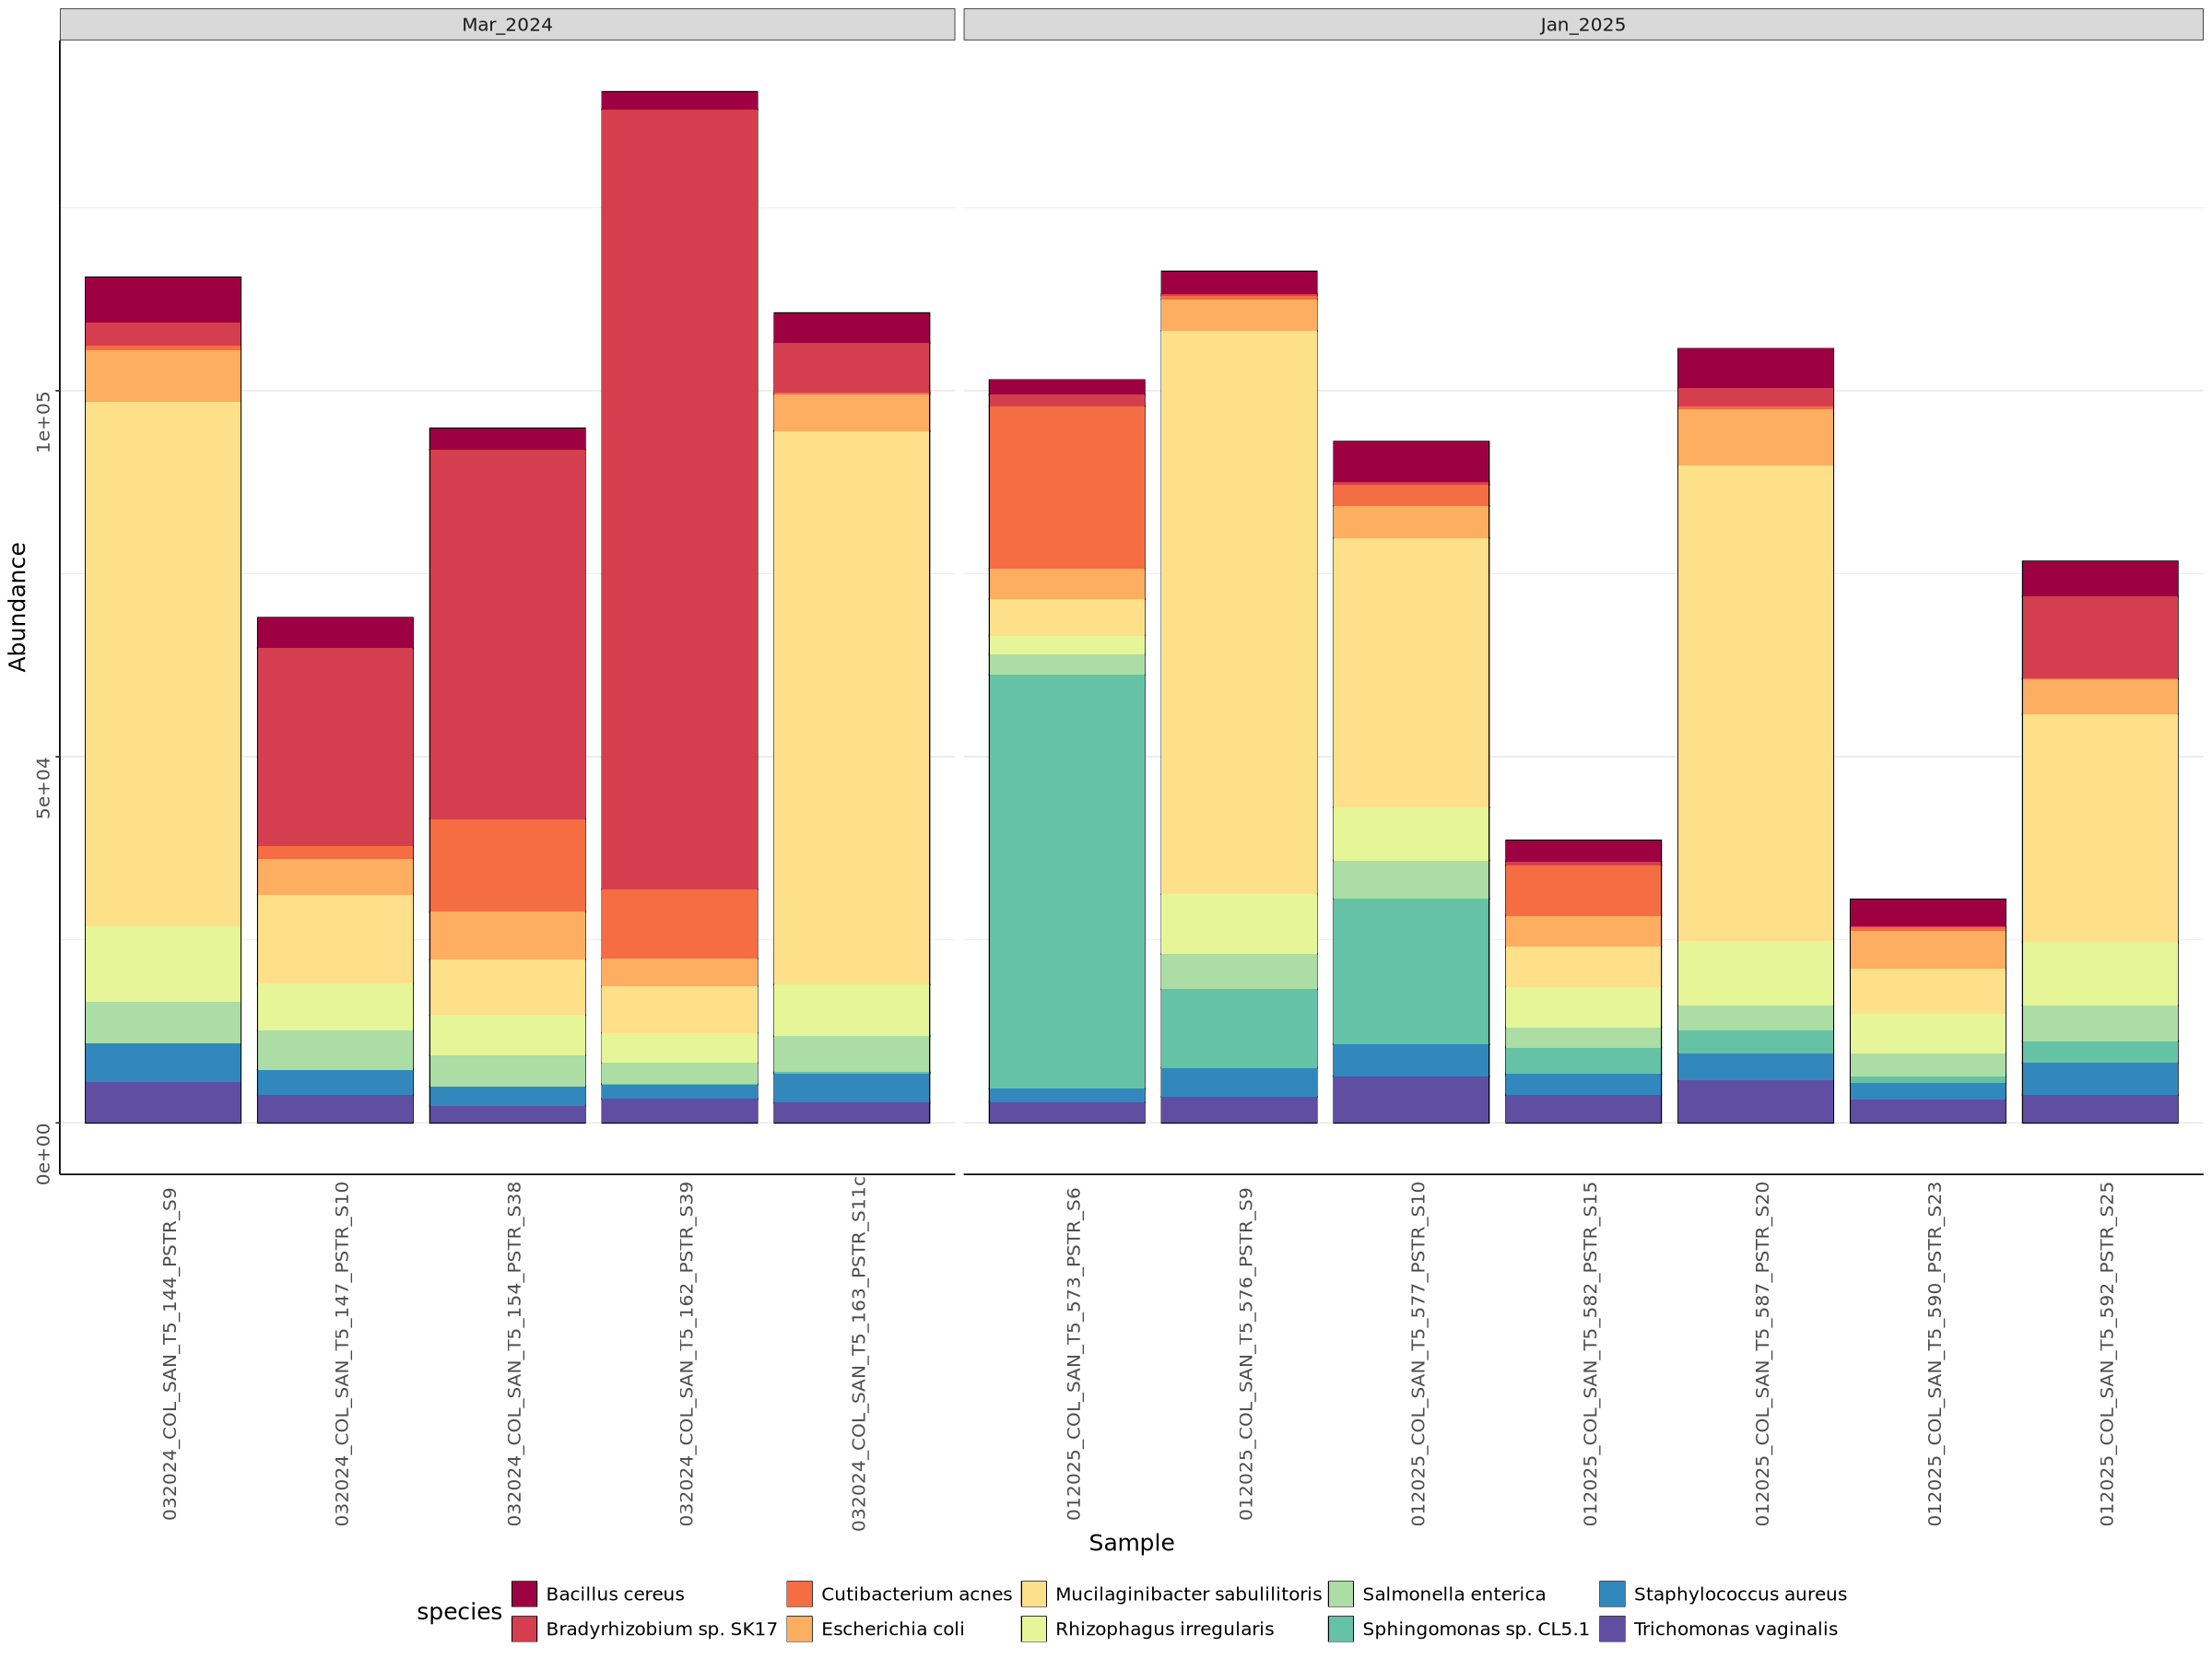

In [185]:
# bar plot of top 10 abundant taxa in MCAV samples
pstr_10_bar<-plot_bar(COL_pstr_10,fill='species')+
facet_grid(~Year_p, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
pstr_10_bar

In [186]:
ggsave(filename = "pstr_top_10_species_bar.png", plot = pstr_10_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)